In [2]:
#!pip install brokenaxes -> needed to create plots with broken x axes because we have lots of 0 space

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
import numpy as np
import seaborn as sns
from matplotlib import animation
from brokenaxes import brokenaxes
import random

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

## Linear Probing

In the linear probing analysis, I am taking the hidden states at different timesteps and try to predict object size, shape and color. It should work better with hidden states from the grabbing motion than from the reaching motion if there is the distinction in timesteps

In [22]:
def get_hidden_states(filename):
    if type(filename) == list:
        all_files=[]
        for f in filename:
            all_files.append(torch.load(f, map_location=torch.device('cpu')))
        return all_files
    elif type(filename) == str:
        return torch.load(filename, map_location=torch.device('cpu'))

#The hidden states are collected after being dealt with by the last layer -> confirmed
#hidden_states=get_hidden_states("./pick_up_ball_data/0ec0d9a9-52f2-4a00-8bb8-b2265616a6ca_hidden_states.pt")
#We have 33 hidden states (one for each inferencing step)
#len(hidden_states)
#We also have state token + 16 action horizon per hidden state
#print(hidden_states[0][0].shape)

#With the above information, we can train 3 NNs that answer classification questions
color_classes=["red", "blue", "green"]
size_classes=["small", "large"]
object_type=["ball", "cube", "capsule"]

#In my analysis, I will first focus on the object type, because I do not have the full grid of sizes and objects and colors yet
hidden_states_cube_small_red=get_hidden_states(["./pick_up_cube_data/small/red/5c9cf717-4742-4f16-b14b-4e66dfd743d7_hidden_states.pt",
                                                   "./pick_up_cube_data/small/red/9a07601f-defd-4802-82a9-df3c8ccd5d6d_hidden_states.pt", 
                                                   "./pick_up_cube_data/small/red/d1721bca-8db9-4d08-b2e8-10041f2e66f8_hidden_states.pt",
                                                   "./pick_up_cube_data/small/red/ec0ef22d-f2a4-4a19-b877-e30cd700100e_hidden_states.pt"])
hidden_states_cube_small_green=get_hidden_states(["./pick_up_cube_data/small/green/16467616-4768-4799-bb55-b7518a1ad6c7_hidden_states.pt",
                                                   "./pick_up_cube_data/small/green/57218634-da30-41ae-a517-8fabdd7e1854_hidden_states.pt", 
                                                   "./pick_up_cube_data/small/green/f2df4e30-0600-4b1e-84b6-e6575adaafb3_hidden_states.pt",
                                                   "./pick_up_cube_data/small/green/fc00d7dc-16cb-4197-84ed-a99531771e8e_hidden_states.pt"])
hidden_states_cube_small_blue=get_hidden_states(["./pick_up_cube_data/small/blue/0a5ceffa-30d4-44d7-8fb5-94fdc93dfc4f_hidden_states.pt",
                                                   "./pick_up_cube_data/small/blue/0cbfed7a-41a2-4e79-9170-5094b968892e_hidden_states.pt", 
                                                   "./pick_up_cube_data/small/blue/43e8fceb-34d2-438c-a964-010692634c52_hidden_states.pt",
                                                   "./pick_up_cube_data/small/blue/144950da-dba6-4a0f-a64a-44370c11d5d6_hidden_states.pt"])
reaching_grabbing_differences_cube_small_red=[[5, 8],
                                            [6, 11],
                                            [4, 8],
                                            [4, 9]]
reaching_grabbing_differences_cube_small_green=[[3, 7],
                                              [4, 8],
                                              [3, 8],
                                              [5, 10]]
reaching_grabbing_differences_cube_small_blue=[[3, 6], 
                                               [3, 7],
                                               [3, 7],
                                               [3, 8]]

hidden_states_cube_large_red=get_hidden_states(["./pick_up_cube_data/large/red/0e48a0f7-888f-43a4-8ab6-5a594be1bca9_hidden_states.pt",
                                                   "./pick_up_cube_data/large/red/8c89368b-4a45-45c3-8913-b9fe2a3f0c75_hidden_states.pt", 
                                                   "./pick_up_cube_data/large/red/7591b691-5b2e-4577-b883-f19622688251_hidden_states.pt",
                                                   "./pick_up_cube_data/large/red/267239d6-5592-4a9f-8dae-8da7c57dabe2_hidden_states.pt"])
hidden_states_cube_large_green=get_hidden_states(["./pick_up_cube_data/large/green/3cd3dbb3-148b-4401-b23f-f1222678494d_hidden_states.pt",
                                                   "./pick_up_cube_data/large/green/9fc6d10e-5026-45de-ae12-ea2adec23af1_hidden_states.pt", 
                                                   "./pick_up_cube_data/large/green/88380b32-06fd-4a5b-910d-de94460c0835_hidden_states.pt",
                                                   "./pick_up_cube_data/large/green/99254138-3488-4691-85ae-db468bb93b3b_hidden_states.pt"])
hidden_states_cube_large_blue=get_hidden_states(["./pick_up_cube_data/large/blue/4f717475-83ef-41c0-b287-1bdc78e91ea3_hidden_states.pt",
                                                   "./pick_up_cube_data/large/blue/6e45d5b3-6911-4e70-afee-4d39b8f20387_hidden_states.pt", 
                                                   "./pick_up_cube_data/large/blue/09a8f14c-350a-4a49-8247-bf4afff76d35_hidden_states.pt",
                                                   "./pick_up_cube_data/large/blue/41fc842e-0519-48dc-ac0b-d7cb9f6b0110_hidden_states.pt"])
reaching_grabbing_differences_cube_large_red=[[4, 7],
                                              [4, 7],
                                              [4, 7],
                                              [3, 7]]
reaching_grabbing_differences_cube_large_green=[[3, 7],
                                                  [3, 6],
                                                  [3, 6],
                                                  [4, 6]]
reaching_grabbing_differences_cube_large_blue=[[3, 5],
                                                  [3, 5],
                                                  [4, 6],
                                                  [3, 6]]



hidden_states_capsule_small_red=get_hidden_states(["./pick_up_capsule_data/small/red/4f32b8fb-3472-40df-879d-3e0ba63b4287_hidden_states.pt",
                                                   "./pick_up_capsule_data/small/red/e77ba971-f040-46b4-bba6-116eb7bb9b58_hidden_states.pt",
                                                   "./pick_up_capsule_data/small/red/e2d12736-80f3-4604-a494-3a359fdb20c6_hidden_states.pt",
                                                   "./pick_up_capsule_data/small/red/ffa15445-0093-4acd-9637-3edb79f3617b_hidden_states.pt"])
hidden_states_capsule_small_green=get_hidden_states(["./pick_up_capsule_data/small/green/53c035c7-905f-46a1-9cc1-0a58c7107cea_hidden_states.pt",
                                                   "./pick_up_capsule_data/small/green/a3a8d64c-f2e1-4a72-9e8e-6a0e0d9874a5_hidden_states.pt", 
                                                   "./pick_up_capsule_data/small/green/fb0e878d-4fa6-478b-9364-8a0b9b04f895_hidden_states.pt"])
hidden_states_capsule_small_blue=get_hidden_states(["./pick_up_capsule_data/small/blue/8e2b2e39-af46-4649-bd6c-15890769c1e1_hidden_states.pt",
                                                   "./pick_up_capsule_data/small/blue/84b31898-e87b-42bb-b627-176ce1b19cfc_hidden_states.pt", 
                                                   "./pick_up_capsule_data/small/blue/2137e92c-4b32-46a7-bf6f-7086757ff1cc_hidden_states.pt",
                                                   "./pick_up_capsule_data/small/blue/a1ab86c9-d896-43f9-b4d3-e764acbff1da_hidden_states.pt"])
reaching_grabbing_differences_capsule_small_red=[[7, 11],
                                                  [2, 5],
                                                  [2, 3],
                                                  [2, 4]]
reaching_grabbing_differences_capsule_small_green=[[2, 4],
                                                  [2, 3],
                                                  [2, 3]]
reaching_grabbing_differences_capsule_small_blue=[[2, 3], 
                                                   [5, 8],
                                                   [2, 4],
                                                   [2, 3]]
hidden_states_capsule_large_red=get_hidden_states(["./pick_up_capsule_data/large/red/7cc145ef-3215-4820-887f-745c17ca8fc7_hidden_states.pt",
                                                   "./pick_up_capsule_data/large/red/51a0b373-88ac-40db-a54a-62900a0b2145_hidden_states.pt",
                                                   "./pick_up_capsule_data/large/red/55cd58d2-2186-4ea2-8c3e-21d2cee581b5_hidden_states.pt",
                                                   "./pick_up_capsule_data/large/red/e297367d-3cf8-42ce-9d9c-b6fa2f15904e_hidden_states.pt"])
hidden_states_capsule_large_green=get_hidden_states(["./pick_up_capsule_data/large/green/0f336670-8db7-42c2-a9b3-5cffbe356f5b_hidden_states.pt",
                                                   "./pick_up_capsule_data/large/green/32d19291-1a62-43e4-bb82-3933cf01f198_hidden_states.pt",
                                                   "./pick_up_capsule_data/large/green/7576752c-e5e8-4337-8967-2fd18f84aaa0_hidden_states.pt",
                                                   "./pick_up_capsule_data/large/green/e69d0518-e2aa-437d-8767-a3eeccb4607c_hidden_states.pt"])
hidden_states_capsule_large_blue=get_hidden_states(["./pick_up_capsule_data/large/blue/006b847c-59e7-4ca9-a86a-b0e1ab3bdacb_hidden_states.pt",
                                                   "./pick_up_capsule_data/large/blue/17cda5a5-b78a-4a27-b8df-bc5d0cf7e8e1_hidden_states.pt",
                                                   "./pick_up_capsule_data/large/blue/a0688d50-6ccd-4bc1-aebb-59b071385f49_hidden_states.pt",
                                                   "./pick_up_capsule_data/large/blue/fed04f11-320a-4a32-9f20-619c01d1ecf4_hidden_states.pt"])
reaching_grabbing_differences_capsule_large_red=[[4, 7],
                                                [2, 4],
                                                [4, 6],
                                                [2, 4]]
reaching_grabbing_differences_capsule_large_green=[[3, 5],
                                                  [3 ,5],
                                                  [3, 4],
                                                  [2, 3]]
reaching_grabbing_differences_capsule_large_blue=[[3, 4], 
                                               [4, 6],
                                               [3, 5],
                                               [3, 5]]


hidden_states_ball_small_red=get_hidden_states(["./pick_up_ball_data/small/red/0ec0d9a9-52f2-4a00-8bb8-b2265616a6ca_hidden_states.pt",
                                                   "./pick_up_ball_data/small/red/4d13cbfc-d8c8-4770-a1e4-8f064302cfdb_hidden_states.pt",
                                                   "./pick_up_ball_data/small/red/71ce7b2b-4960-4a2b-95dd-0902c5bdcd76_hidden_states.pt",
                                                   "./pick_up_ball_data/small/red/79357f5f-063e-4eb3-a24a-a0155bce34af_hidden_states.pt"])
hidden_states_ball_small_green=get_hidden_states(["./pick_up_ball_data/small/green/0f4c47ed-9486-48d9-9f3c-e2789d4a808f_hidden_states.pt",
                                                   "./pick_up_ball_data/small/green/4a11c6a8-4223-47e0-9fdc-ef1f1a6843c9_hidden_states.pt", 
                                                   "./pick_up_ball_data/small/green/99a5b06e-97ed-462d-b314-2dca6c4f3b7e_hidden_states.pt",
                                                   "./pick_up_ball_data/small/green/afa0a49b-db83-4eaf-a528-f328fe7aa805_hidden_states.pt"])
hidden_states_ball_small_blue=get_hidden_states(["./pick_up_ball_data/small/blue/4d0c2bca-97ed-43bf-86b4-3b9b458ec601_hidden_states.pt",
                                                   "./pick_up_ball_data/small/blue/6b6b2863-f1da-4025-9dbc-db6230ba4138_hidden_states.pt", 
                                                   "./pick_up_ball_data/small/blue/31f09929-84bf-4842-bff5-c5dc7d23c26f_hidden_states.pt",
                                                   "./pick_up_ball_data/small/blue/91c53aa5-37c6-4cab-8254-06dd0465823a_hidden_states.pt"])
reaching_grabbing_differences_ball_small_red=[[6, 11], 
                                               [6, 11],
                                               [5, 11],
                                               [5, 11]]
reaching_grabbing_differences_ball_small_green=[[5, 8],
                                              [4, 8],
                                              [6, 11],
                                              [5, 10]]
reaching_grabbing_differences_ball_small_blue=[[4, 7], 
                                               [6, 10],
                                               [6, 11],
                                               [4, 8]]

hidden_states_ball_large_red=get_hidden_states(["./pick_up_ball_data/large/red/1a05f029-9b8b-4e66-9326-286e0a029296_hidden_states.pt",
                                                   "./pick_up_ball_data/large/red/3b15b239-5ac2-4562-9014-59a73f637574_hidden_states.pt",
                                                   "./pick_up_ball_data/large/red/0859f2a8-7a8a-4f1d-845c-7c95f9900152_hidden_states.pt",
                                                   "./pick_up_ball_data/large/red/db4a831b-da3d-4012-968b-19d0440f01e2_hidden_states.pt"])
hidden_states_ball_large_green=get_hidden_states(["./pick_up_ball_data/large/green/3bf8e1bb-96e5-4c96-917b-4cd4fc9dd4f2_hidden_states.pt",
                                                   "./pick_up_ball_data/large/green/44b1b272-ff44-43f2-93e9-59831d2262aa_hidden_states.pt",
                                                   "./pick_up_ball_data/large/green/92b6b14c-331a-42bb-93f5-bf8691f8fce5_hidden_states.pt",
                                                   "./pick_up_ball_data/large/green/660c0a00-2b01-4203-89ca-6e38cec6ad96_hidden_states.pt"])
hidden_states_ball_large_blue=get_hidden_states(["./pick_up_ball_data/large/blue/93a90bd6-b62d-4ddf-9c5e-a9dc0ae77400_hidden_states.pt",
                                                   "./pick_up_ball_data/large/blue/0656b44a-d887-4c72-9f45-178f3f013d73_hidden_states.pt",
                                                   "./pick_up_ball_data/large/blue/90260823-2977-4e94-a875-93a290337147_hidden_states.pt",
                                                   "./pick_up_ball_data/large/blue/ee43c169-f8cc-44b6-ad8a-25789b0b079e_hidden_states.pt"])
reaching_grabbing_differences_ball_large_red=[[5, 9], 
                                               [6, 8],
                                               [5, 7],
                                               [4, 9]]
reaching_grabbing_differences_ball_large_green=[[4, 7], 
                                               [4, 6],
                                               [4, 7],
                                               [3, 6]]
reaching_grabbing_differences_ball_large_blue=[[4, 7], 
                                               [4, 7],
                                               [4, 6],
                                               [4, 6]]


print(len(hidden_states_cube_small_red[:3]))
#We have 33 predictions in total
print(len(hidden_states_cube_small_red[1]))
#this is the number of layers + the one before passing to any layers! -> I first focus on the last layer
print(len(hidden_states_cube_small_red[1][0]))
#This is the prediction!
print(hidden_states_cube_small_red[0][0][0].shape)

3
33
17
torch.Size([1, 17, 1536])


In [42]:
#now, we need to combine the seconds that we have and get the right indices
def get_indexed_hidden_states(hidden_states_list, rg_diff, layer_index=16): #layer inde should be 1
    reachings=[]
    grabbings=[]
    for i in range(len(rg_diff)):
        seconds_to_ts=rg_diff[i][0] * 20 #-> seconds to timesteps
        ts_to_pred_steps= int(np.floor(seconds_to_ts / 16))#int(np.ceil(seconds_to_ts / 16)) #Floor or ceil makes a huge difference!
        #print("Reaching Length: ", [el for el in hidden_states_list[i][:ts_to_pred_steps]]))
        print("Number of timesteps: ", len(hidden_states_list[i]))
        print("Number of layers: ", len(hidden_states_list[i][16]))
        reaching=[el[layer_index].squeeze().float().numpy()[1:, :] for el in hidden_states_list[i][:ts_to_pred_steps]] #we care about the last layer only
        
        #Now that we have the list of 16er predictions, we need to decompress them
        for timechunk in reaching:
            reachings+=[vec for vec in timechunk]
        #reachings+=reaching
        
        
        seconds_to_ts_grab=rg_diff[i][1] * 20 #-> seconds to timesteps
        ts_to_pred_steps_grab= int(np.floor(seconds_to_ts_grab / 16))

        #We select firstly the right timesteps(ts_to_pred_steps:ts_to_pred_steps_grab) from the right episode(i) 
        #We then only care about the hidden states of the last layer (el[-1]) and then we also drop the first element of the prediction which is not an action but the state([1:, :])
        grabbing=[el[layer_index].squeeze().float().numpy()[1:, :] for el in hidden_states_list[i][ts_to_pred_steps:ts_to_pred_steps_grab]] #we care about the last layer only
        
        #We also decompress here so we dont have (16, 1563) chunks but one hidden representation per timestep
        
        for timechunk in grabbing:
            grabbings+=[vec for vec in timechunk]
        #grabbings+=grabbing
        
    #reachings=np.stack(reachings)
    #grabbings=np.stack(grabbings)
    
    #print("Len reachings: ", len(reachings))
    #print("Reachings 0: ", reachings[0].shape)
    #print("Len grabbings: ", len(grabbings))
    #print("\n")
    return reachings, grabbings
    
reaching_cube_train, grabbing_cube_train=get_indexed_hidden_states(hidden_states_cube_small_red[:3], reaching_grabbing_differences_cube_small_red[:3])
reaching_cube_test, grabbing_cube_test=get_indexed_hidden_states([hidden_states_cube_small_red[-1]], [reaching_grabbing_differences_cube_small_red[-1]])


reaching_capsule_train, grabbing_capsule_train=get_indexed_hidden_states(hidden_states_capsule_small_red[:3], reaching_grabbing_differences_capsule_small_red[:3])
reaching_capsule_test, grabbing_capsule_test=get_indexed_hidden_states([hidden_states_capsule_small_red[-1]], [reaching_grabbing_differences_capsule_small_red[-1]])


reaching_ball_train, grabbing_ball_train=get_indexed_hidden_states(hidden_states_ball_small_red[:3], reaching_grabbing_differences_ball_small_red[:3])
reaching_ball_test, grabbing_ball_test=get_indexed_hidden_states([hidden_states_ball_small_red[-1]], [reaching_grabbing_differences_ball_small_red[-1]])

#print("All Reaching: ", len(reaching_cube + reaching_capsule + reaching_ball))
#print("All Grabbing: ", len(grabbing_cube + grabbing_capsule + grabbing_ball))

#Now that we have the instances, we can see there are not too many instances to learn from and we have pretty high dimenstional hidden states (1563)
#So, I will apply PCA to reduce the dimension before training the classifier
#print(len(reaching_cube))

Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17


In [24]:
#We now want to see if we can predict better the objects if we have reaching vs if we have grabbing

#To do this, I need two different training sets 
def train_lr_reach_vs_grab(reaching_cube_train,reaching_capsule_train,reaching_ball_train, reaching_cube_test, reaching_capsule_test, reaching_ball_test,grabbing_cube_train,grabbing_capsule_train,grabbing_ball_train,grabbing_cube_test, grabbing_capsule_test, grabbing_ball_test, class1, class2, class3=None, limit=1000): 

    if class3 != None:
        X_train_reach=reaching_cube_train+reaching_capsule_train+reaching_ball_train
        X_test_reach=reaching_cube_test+reaching_capsule_test+reaching_ball_test
        
        X_train_grab=grabbing_cube_train+grabbing_capsule_train+grabbing_ball_train
        X_test_grab=grabbing_cube_test+grabbing_capsule_test+grabbing_ball_test
        y_train_reach=[class1]*len(reaching_cube_train) + [class2]*len(reaching_capsule_train)+ [class3]*len(reaching_ball_train)
        y_test_reach=[class1]*len(reaching_cube_test) + [class2]*len(reaching_capsule_test)+ [class3]*len(reaching_ball_test)
        
        y_train_grab=[class1]*len(grabbing_cube_train) + [class2]*len(grabbing_capsule_train)+ [class3]*len(grabbing_ball_train)
        y_test_grab=[class1]*len(grabbing_cube_test) + [class2]*len(grabbing_capsule_test)+ [class3]*len(grabbing_ball_test)
        
    else:
        X_train_reach=reaching_cube_train+reaching_capsule_train
        X_test_reach=reaching_cube_test+reaching_capsule_test
        
        X_train_grab=grabbing_cube_train+grabbing_capsule_train
        X_test_grab=grabbing_cube_test+grabbing_capsule_test
        y_train_reach=[class1]*len(reaching_cube_train) + [class2]*len(reaching_capsule_train)
        y_test_reach=[class1]*len(reaching_cube_test) + [class2]*len(reaching_capsule_test)
        
        y_train_grab=[class1]*len(grabbing_cube_train) + [class2]*len(grabbing_capsule_train)
        y_test_grab=[class1]*len(grabbing_cube_test) + [class2]*len(grabbing_capsule_test)
        
    
    
    #now we make train_test_splits
    #X_train_reach, X_test_reach, y_train_reach, y_test_reach=train_test_split(X_reaching, y_reach, train_size=0.8, stratify=y_reach)
    #X_train_grab, X_test_grab, y_train_grab, y_test_grab=train_test_split(X_grabbing, y_grab, train_size=0.8, stratify=y_grab)
    #-> we do not need this anymore because we already did this
    
    
    X_test_reach = np.array(X_test_reach)
    X_test_grab = np.array(X_test_grab)
    y_test_reach = np.array(y_test_reach)
    y_test_grab = np.array(y_test_grab)
    
    lr_reach=LogisticRegression(max_iter=limit)
    lr_reach.fit(X_train_reach, y_train_reach)
    
    lr_grab=LogisticRegression(max_iter=limit)
    lr_grab.fit(X_train_grab, y_train_grab)
    
    #We now sample a 50/50 variation of the reach and grab test splits
    n = min(len(X_test_reach), len(X_test_grab))  # choose smallest to balance
    
    # Random sample n from each
    idx_reach = np.random.choice(len(X_test_reach), n, replace=False)
    idx_grab  = np.random.choice(len(X_test_grab),  n, replace=False)
    
    X_test = np.vstack([X_test_reach[idx_reach], X_test_grab[idx_grab]])
    y_test = np.hstack([y_test_reach[idx_reach], y_test_grab[idx_grab]])
    
    # Evaluate both models on same balanced test set
    acc_reach = lr_reach.score(X_test, y_test)
    acc_grab  = lr_grab.score(X_test, y_test)
    
    print(f"Test Accuracy:\n  Trained on Reaching: {acc_reach:.2f}\n  Trained on Grabbing: {acc_grab:.2f}")
    return lr_reach, lr_grab, X_test, y_test

def assimilate_reach_grab(reachings, grabbings):
    total_len_reach=sum([len(el) for el in reachings])
    total_len_grab=sum([len(el) for el in grabbings])
    
    #I cut down the difference from reachings and grabbings equally for each class, because my goal is not to make an unbalanced dataset
    #but rather just have a similar amount of instances in reaching and grabbing

    
    difference_per_movement1=len(grabbings[0])-len(reachings[0])
    difference_per_movement2=len(grabbings[1])-len(reachings[1])
    all_diffs=[difference_per_movement1,difference_per_movement2]
    if len(grabbings) == 3: #for size we only have 2 elements per object shape
        difference_per_movement3=len(grabbings[2])-len(reachings[2])
        all_diffs=[difference_per_movement1,difference_per_movement2, difference_per_movement3]
    

    new_datasets=[]
    #So far, I always cut down the last x elements from each class, but I think, maybe sampling randomly migh be a safer choice
    for idx, difference_per_movement in enumerate(all_diffs):
        if difference_per_movement > 0:
            print("Getting new grabbings")
            to_delete_indices_1=np.random.choice(np.arange(len(grabbings[idx])), replace=False, size=np.abs(difference_per_movement))
            new_grabbing_1=[grabbings[idx][el] for el in range(len(grabbings[idx])) if el not in  to_delete_indices_1]
            new_datasets.append(new_grabbing_1)
            
            
        else:
            print("Getting new reachings")
            to_delete_indices_1=np.random.choice(np.arange(len(reachings[idx])), replace=False, size=np.abs(difference_per_movement))
            new_reaching_1=[reachings[idx][el] for el in range(len(reachings[idx])) if el not in  to_delete_indices_1]        
            new_datasets.append(new_reaching_1)
    
            
    #print("Size differences per class: \n", "Class 1: ", len(new_datasets[0]) - len(grabbings[0]), "\nClass 2: ", len(new_datasets[1]) - len(grabbings[1]), 
    #                  "\nClass 3: ", len(new_datasets[2]) - len(grabbings[2]))
    
    return new_datasets[0], new_datasets[1], new_datasets[2] 
        
lr_reach_small_objects, lr_grab_small_objects, X_test_small_objects, y_test_small_objects=train_lr_reach_vs_grab(reaching_cube_train,reaching_capsule_train,reaching_ball_train, 
                                                                                                               reaching_cube_test, reaching_capsule_test, reaching_ball_test,
                                                                                                               grabbing_cube_train,grabbing_capsule_train,grabbing_ball_train,
                                                                                                               grabbing_cube_test, grabbing_capsule_test, grabbing_ball_test, 
                                                                                                               "cube", "capsule", "ball")

Test Accuracy:
  Trained on Reaching: 1.00
  Trained on Grabbing: 0.97


## Training a full model

Before looking at any specific combinations of training sets, I first collect training data for each object shape, color and size combination and train a model on it. Then, I also make a new testing set and have to collect adequate samples for each of the object variations for testing.

In [25]:
#Training & testing sets generation: Collecting all variations

#Cube
reaching_cube_train_small_red, grabbing_cube_train_small_red=get_indexed_hidden_states(hidden_states_cube_small_red[:3], reaching_grabbing_differences_cube_small_red[:3])
reaching_cube_test_small_red, grabbing_cube_test_small_red=get_indexed_hidden_states([hidden_states_cube_small_red[-1]], [reaching_grabbing_differences_cube_small_red[-1]])
reaching_cube_train_small_green, grabbing_cube_train_small_green=get_indexed_hidden_states(hidden_states_cube_small_green[:3], reaching_grabbing_differences_cube_small_green[:3])
reaching_cube_test_small_green, grabbing_cube_test_small_green=get_indexed_hidden_states([hidden_states_cube_small_green[-1]], [reaching_grabbing_differences_cube_small_green[-1]])
reaching_cube_train_small_blue, grabbing_cube_train_small_blue=get_indexed_hidden_states(hidden_states_cube_small_blue[:3], reaching_grabbing_differences_cube_small_blue[:3])
reaching_cube_test_small_blue, grabbing_cube_test_small_blue=get_indexed_hidden_states([hidden_states_cube_small_blue[-1]], [reaching_grabbing_differences_cube_small_blue[-1]])

reaching_cube_train_large_red, grabbing_cube_train_large_red=get_indexed_hidden_states(hidden_states_cube_large_red[:3], reaching_grabbing_differences_cube_large_red[:3])
reaching_cube_test_large_red, grabbing_cube_test_large_red=get_indexed_hidden_states([hidden_states_cube_large_red[-1]], [reaching_grabbing_differences_cube_large_red[-1]])
reaching_cube_train_large_green, grabbing_cube_train_large_green=get_indexed_hidden_states(hidden_states_cube_large_green[:3], reaching_grabbing_differences_cube_large_green[:3])
reaching_cube_test_large_green, grabbing_cube_test_large_green=get_indexed_hidden_states([hidden_states_cube_large_green[-1]], [reaching_grabbing_differences_cube_large_green[-1]])
reaching_cube_train_large_blue, grabbing_cube_train_large_blue=get_indexed_hidden_states(hidden_states_cube_large_blue[:3], reaching_grabbing_differences_cube_large_blue[:3])
reaching_cube_test_large_blue, grabbing_cube_test_large_blue=get_indexed_hidden_states([hidden_states_cube_large_blue[-1]], [reaching_grabbing_differences_cube_large_blue[-1]])

#Capsule
reaching_capsule_train_small_red, grabbing_capsule_train_small_red=get_indexed_hidden_states(hidden_states_capsule_small_red[:3], reaching_grabbing_differences_capsule_small_red[:3])
reaching_capsule_test_small_red, grabbing_capsule_test_small_red=get_indexed_hidden_states([hidden_states_capsule_small_red[-1]], [reaching_grabbing_differences_capsule_small_red[-1]])
reaching_capsule_train_small_green, grabbing_capsule_train_small_green=get_indexed_hidden_states(hidden_states_capsule_small_green[:2], reaching_grabbing_differences_capsule_small_green[:2])
reaching_capsule_test_small_green, grabbing_capsule_test_small_green=get_indexed_hidden_states([hidden_states_capsule_small_green[-1]], [reaching_grabbing_differences_capsule_small_green[-1]])
reaching_capsule_train_small_blue, grabbing_capsule_train_small_blue=get_indexed_hidden_states(hidden_states_capsule_small_blue[:3], reaching_grabbing_differences_capsule_small_blue[:3])
reaching_capsule_test_small_blue, grabbing_capsule_test_small_blue=get_indexed_hidden_states([hidden_states_capsule_small_blue[-1]], [reaching_grabbing_differences_capsule_small_blue[-1]])

reaching_capsule_train_large_red, grabbing_capsule_train_large_red=get_indexed_hidden_states(hidden_states_capsule_large_red[:3], reaching_grabbing_differences_capsule_large_red[:3])
reaching_capsule_test_large_red, grabbing_capsule_test_large_red=get_indexed_hidden_states([hidden_states_capsule_large_red[-1]], [reaching_grabbing_differences_capsule_large_red[-1]])
reaching_capsule_train_large_green, grabbing_capsule_train_large_green=get_indexed_hidden_states(hidden_states_capsule_large_green[:3], reaching_grabbing_differences_capsule_large_green[:3])
reaching_capsule_test_large_green, grabbing_capsule_test_large_green=get_indexed_hidden_states([hidden_states_capsule_large_green[-1]], [reaching_grabbing_differences_capsule_large_green[-1]])
reaching_capsule_train_large_blue, grabbing_capsule_train_large_blue=get_indexed_hidden_states(hidden_states_capsule_large_blue[:3], reaching_grabbing_differences_capsule_large_blue[:3])
reaching_capsule_test_large_blue, grabbing_capsule_test_large_blue=get_indexed_hidden_states([hidden_states_capsule_large_blue[-1]], [reaching_grabbing_differences_capsule_large_blue[-1]])


#Ball
reaching_ball_train_small_red, grabbing_ball_train_small_red=get_indexed_hidden_states(hidden_states_ball_small_red[:3], reaching_grabbing_differences_ball_small_red[:3])
reaching_ball_test_small_red, grabbing_ball_test_small_red=get_indexed_hidden_states([hidden_states_ball_small_red[-1]], [reaching_grabbing_differences_ball_small_red[-1]])
reaching_ball_train_small_green, grabbing_ball_train_small_green=get_indexed_hidden_states(hidden_states_ball_small_green[:3], reaching_grabbing_differences_ball_small_green[:3])
reaching_ball_test_small_green, grabbing_ball_test_small_green=get_indexed_hidden_states([hidden_states_ball_small_green[-1]], [reaching_grabbing_differences_ball_small_green[-1]])
reaching_ball_train_small_blue, grabbing_ball_train_small_blue=get_indexed_hidden_states(hidden_states_ball_small_blue[:3], reaching_grabbing_differences_ball_small_blue[:3])
reaching_ball_test_small_blue, grabbing_ball_test_small_blue=get_indexed_hidden_states([hidden_states_ball_small_blue[-1]], [reaching_grabbing_differences_ball_small_blue[-1]])

reaching_ball_train_large_red, grabbing_ball_train_large_red=get_indexed_hidden_states(hidden_states_ball_large_red[:3], reaching_grabbing_differences_ball_large_red[:3])
reaching_ball_test_large_red, grabbing_ball_test_large_red=get_indexed_hidden_states([hidden_states_ball_large_red[-1]], [reaching_grabbing_differences_ball_large_red[-1]])
reaching_ball_train_large_green, grabbing_ball_train_large_green=get_indexed_hidden_states(hidden_states_ball_large_green[:3], reaching_grabbing_differences_ball_large_green[:3])
reaching_ball_test_large_green, grabbing_ball_test_large_green=get_indexed_hidden_states([hidden_states_ball_large_green[-1]], [reaching_grabbing_differences_ball_large_green[-1]])
reaching_ball_train_large_blue, grabbing_ball_train_large_blue=get_indexed_hidden_states(hidden_states_ball_large_blue[:3], reaching_grabbing_differences_ball_large_blue[:3])
reaching_ball_test_large_blue, grabbing_ball_test_large_blue=get_indexed_hidden_states([hidden_states_ball_large_blue[-1]], [reaching_grabbing_differences_ball_large_blue[-1]])


#This is a simple, just concatenate everything and use it for training approach, but in reality I might have to assimilate reach and grab
full_training_set_reach=np.array(reaching_cube_train_small_red+reaching_cube_train_small_green+reaching_cube_train_small_blue+
                      reaching_cube_train_large_red+reaching_cube_train_large_green+reaching_cube_train_large_blue+
                      reaching_capsule_train_small_red+reaching_capsule_train_small_green+reaching_capsule_train_small_blue+
                      reaching_capsule_train_large_red+reaching_capsule_train_large_green+reaching_capsule_train_large_blue+
                      reaching_ball_train_small_red+reaching_ball_train_small_green+reaching_ball_train_small_blue+
                      reaching_ball_train_large_red+reaching_ball_train_large_green+reaching_ball_train_large_blue)
all_training_reach=[reaching_cube_train_small_red,reaching_cube_train_small_green,reaching_cube_train_small_blue,
                      reaching_cube_train_large_red,reaching_cube_train_large_green,reaching_cube_train_large_blue,
                      reaching_capsule_train_small_red,reaching_capsule_train_small_green,reaching_capsule_train_small_blue,
                      reaching_capsule_train_large_red,reaching_capsule_train_large_green,reaching_capsule_train_large_blue,
                      reaching_ball_train_small_red,reaching_ball_train_small_green,reaching_ball_train_small_blue,
                      reaching_ball_train_large_red,reaching_ball_train_large_green,reaching_ball_train_large_blue]

full_testing_set_reach=np.array(reaching_cube_test_small_red+reaching_cube_test_small_green+reaching_cube_test_small_blue+
                      reaching_cube_test_large_red+reaching_cube_test_large_green+reaching_cube_test_large_blue+
                      reaching_capsule_test_small_red+reaching_capsule_test_small_green+reaching_capsule_test_small_blue+
                      reaching_capsule_test_large_red+reaching_capsule_test_large_green+reaching_capsule_test_large_blue+
                      reaching_ball_test_small_red+reaching_ball_test_small_green+reaching_ball_test_small_blue+
                      reaching_ball_test_large_red+reaching_ball_test_large_green+reaching_ball_test_large_blue)
all_testing_reach=[reaching_cube_test_small_red,reaching_cube_test_small_green,reaching_cube_test_small_blue,
                      reaching_cube_test_large_red,reaching_cube_test_large_green,reaching_cube_test_large_blue,
                      reaching_capsule_test_small_red,reaching_capsule_test_small_green,reaching_capsule_test_small_blue,
                      reaching_capsule_test_large_red,reaching_capsule_test_large_green,reaching_capsule_test_large_blue,
                      reaching_ball_test_small_red,reaching_ball_test_small_green,reaching_ball_test_small_blue,
                      reaching_ball_test_large_red,reaching_ball_test_large_green,reaching_ball_test_large_blue]


full_training_set_grab=np.array(grabbing_cube_train_small_red+grabbing_cube_train_small_green+grabbing_cube_train_small_blue+
                      grabbing_cube_train_large_red+grabbing_cube_train_large_green+grabbing_cube_train_large_blue+
                      grabbing_capsule_train_small_red+grabbing_capsule_train_small_green+grabbing_capsule_train_small_blue+
                      grabbing_capsule_train_large_red+grabbing_capsule_train_large_green+grabbing_capsule_train_large_blue+
                      grabbing_ball_train_small_red+grabbing_ball_train_small_green+grabbing_ball_train_small_blue+
                      grabbing_ball_train_large_red+grabbing_ball_train_large_green+grabbing_ball_train_large_blue)
all_training_grab=[grabbing_cube_train_small_red,grabbing_cube_train_small_green,grabbing_cube_train_small_blue,
                      grabbing_cube_train_large_red,grabbing_cube_train_large_green,grabbing_cube_train_large_blue,
                      grabbing_capsule_train_small_red,grabbing_capsule_train_small_green,grabbing_capsule_train_small_blue,
                      grabbing_capsule_train_large_red,grabbing_capsule_train_large_green,grabbing_capsule_train_large_blue,
                      grabbing_ball_train_small_red,grabbing_ball_train_small_green,grabbing_ball_train_small_blue,
                      grabbing_ball_train_large_red,grabbing_ball_train_large_green,grabbing_ball_train_large_blue]

full_testing_set_grab=np.array(grabbing_cube_test_small_red+grabbing_cube_test_small_green+grabbing_cube_test_small_blue+
                      grabbing_cube_test_large_red+grabbing_cube_test_large_green+grabbing_cube_test_large_blue+
                      grabbing_capsule_test_small_red+grabbing_capsule_test_small_green+grabbing_capsule_test_small_blue+
                      grabbing_capsule_test_large_red+grabbing_capsule_test_large_green+grabbing_capsule_test_large_blue+
                      grabbing_ball_test_small_red+grabbing_ball_test_small_green+grabbing_ball_test_small_blue+
                      grabbing_ball_test_large_red+grabbing_ball_test_large_green+grabbing_ball_test_large_blue)

all_testing_grab=[grabbing_cube_test_small_red,grabbing_cube_test_small_green,grabbing_cube_test_small_blue,
                      grabbing_cube_test_large_red,grabbing_cube_test_large_green,grabbing_cube_test_large_blue,
                      grabbing_capsule_test_small_red,grabbing_capsule_test_small_green,grabbing_capsule_test_small_blue,
                      grabbing_capsule_test_large_red,grabbing_capsule_test_large_green,grabbing_capsule_test_large_blue,
                      grabbing_ball_test_small_red,grabbing_ball_test_small_green,grabbing_ball_test_small_blue,
                      grabbing_ball_test_large_red,grabbing_ball_test_large_green,grabbing_ball_test_large_blue]

def assimilate_reach_grab_full(reachings, grabbings):
    new_subsets=[]
    new_reachings_train=[]
    new_grabbings_train=[]
    
    for subset in range(len(reachings)):
        difference=len(grabbings[subset])-len(reachings[subset]) #if diff >0, grab is larger than reach, otherwise reach is larger than grab

        if difference > 0:
            #print(f"New grabbing at index {subset}")
            to_delete_indices=np.random.choice(np.arange(len(grabbings[subset])), replace=False, size=np.abs(difference))
            new_grabbing_subset=[grabbings[subset][el] for el in range(len(grabbings[subset])) if el not in to_delete_indices]
            new_subsets.append(len(new_grabbing_subset))

            #The new raching dataset contains the same elements as before but grabbing contains the new elements
            new_reachings_train+=reachings[subset]
            new_grabbings_train+=new_grabbing_subset
            
        else:
            #print(f"New reaching at index {subset}")
            to_delete_indices=np.random.choice(np.arange(len(reachings[subset])), replace=False, size=np.abs(difference))
            new_reaching_subset=[reachings[subset][el] for el in range(len(reachings[subset])) if el not in to_delete_indices]
            new_subsets.append(len(new_reaching_subset))

            new_grabbings_train+=grabbings[subset]
            new_reachings_train+=new_reaching_subset

    
    return new_reachings_train, new_grabbings_train, new_subsets
    
def create_test_set(y_test_reach, y_test_grab, all_testing_reach, all_testing_grab, classes, split_style="min"):
    #Additionally, I want a fully balanced dataset for each class
    counts_per_class_test_reach={k:y_test_reach.tolist().count(k) for k in classes}
    counts_per_class_test_grab={k:y_test_grab.tolist().count(k) for k in classes}
    print("Number per class in testing reach: ", counts_per_class_test_reach)
    print("Number per class in testing grab: ", counts_per_class_test_grab)
    
    #Now I balance per motion, but also per class
    X_test=[]
    y_test=[]

    if split_style == "min":
        global_min_count=min(list(counts_per_class_test_reach.values())+list(counts_per_class_test_grab.values()))
        print("Global minimal timesteps per class: ", global_min_count)
        for subclass in range(len(classes)):
            new_reach_ts_indices=np.random.choice(np.arange(len(all_testing_reach[subclass])), size=global_min_count, replace=False)
            new_grab_ts_indices=np.random.choice(np.arange(len(all_testing_grab[subclass])), size=global_min_count, replace=False)
            
            X_test+=[all_testing_reach[subclass][el] for el in range(len(all_testing_reach[subclass])) if el in new_reach_ts_indices]+[all_testing_grab[subclass][el] for el in range(len(all_testing_grab[subclass])) if el in new_grab_ts_indices]
            y_test+=[classes[subclass]] * (global_min_count*2)
            
    elif split_style=="max":
        for class_idx in range(len(classes)):
            #select the larger one and downsample from the other
            counter_reach=list(counts_per_class_test_reach.values())[class_idx]
            counter_grab=list(counts_per_class_test_grab.values())[class_idx]
            diff=counter_reach-counter_grab
            
            if diff > 0: #downsample reach
                new_reach_ts_indices=np.random.choice(np.arange(len(all_testing_reach[class_idx])), size=np.abs(diff), replace=False) #throw out diff samples from reach
                
                #Add downsampled reach and keep grab
                X_test+=[all_testing_reach[class_idx][el] for el in range(len(all_testing_reach[class_idx])) if el not in new_reach_ts_indices]
                X_test+=all_testing_grab[class_idx]
                
                y_test+=[classes[class_idx]] * (counter_grab*2)
            else: 
                new_grab_ts_indices=np.random.choice(np.arange(len(all_testing_grab[class_idx])), size=np.abs(diff), replace=False) #throw out #diff samples from grab
                X_test+=[all_testing_grab[class_idx][el] for el in range(len(all_testing_grab[class_idx])) if el not in new_grab_ts_indices]
                X_test+=all_testing_reach[class_idx]
                y_test+=[classes[class_idx]] * (counter_reach*2)
    return X_test, y_test  

#In total we have more reaching than grabbing samples...
print("Total number of training timestep instances reach: ", len(full_training_set_reach))
print("Total number of training timestep instances reach: ", len(full_training_set_grab))
print("Total number of testing timestep instances reach: ", len(full_testing_set_reach))

print("Total number of testing timestep instances grab: ", len(full_testing_set_grab))


Total number of training timestep instances reach:  3792
Total number of training timestep instances reach:  3120
Total number of testing timestep instances reach:  1088
Total number of testing timestep instances grab:  1152


In [7]:
classes=["cube_small_red", "cube_small_green", "cube_small_blue", "cube_large_red", "cube_large_green", "cube_large_blue",
         "capsule_small_red", "capsule_small_green", "capsule_small_blue", "capsule_large_red", "capsule_large_green", "capsule_large_blue",
         "ball_small_red", "ball_small_green", "ball_small_blue", "ball_large_red", "ball_large_green", "ball_large_blue"]
limit=4000

all_predictions_reach=[]
all_predictions_grab=[]

for rs in [5]:#, 42, 11, 9, 50]:
    np.random.seed(rs)
    random.seed(rs)

    #After assimilation these should be of equal length ! (which they are)
    print("Preparing training sets")
    new_full_training_set_reach, new_full_training_set_grab, new_lengths=assimilate_reach_grab_full(all_training_reach, all_training_grab)
    print("Len assimilates reach: ", len(new_full_training_set_reach))
    print("Len assimilates grab: ", len(new_full_training_set_grab))


    #print("One instance: ", full_training_set_reach[0].shape)
    #print("One instance type: ", type(full_training_set_reach[0]))
    
    #Now, to fit an LR model, I need y values... in my case these somehow need to correpsond to the combined classes...
    # that means I have to make combined classes
    
    
    #y_train_reach = np.array([label for idx, x in enumerate(all_training_reach) for label in [classes[idx]] * len(x)])
    #y_train_grab=np.array([label for idx, x in enumerate(all_training_grab) for label in [classes[idx]] * len(x)])
    
    y_train_reach=np.array([label for idx in range(len(all_training_reach)) for label in [classes[idx]] * new_lengths[idx]])
    y_train_grab=np.array([label for idx in range(len(all_training_grab)) for label in [classes[idx]] * new_lengths[idx]])
    
    y_test_reach=np.array([label for idx, x in enumerate(all_testing_reach) for label in [classes[idx]] * len(x)])
    y_test_grab=np.array([label for idx, x in enumerate(all_testing_grab) for label in [classes[idx]] * len(x)])
    
    #Once we have the traing set done, we now need to look at the test
    #I want a fully balanced dataset for reach and grab phases
    X_test, y_test=create_test_set(y_test_reach, y_test_grab, all_testing_reach, all_testing_grab, classes)
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach, y_train_reach = shuffle(new_full_training_set_reach, y_train_reach, random_state=rs)
    X_train_grab, y_train_grab = shuffle(new_full_training_set_grab, y_train_grab, random_state=rs)

    print("Beginning training...")
    lr_reach=LogisticRegression(max_iter=limit)
    lr_reach.fit(X_train_reach, y_train_reach)
    
    lr_grab=LogisticRegression(max_iter=limit)
    lr_grab.fit(X_train_grab, y_train_grab)
    print("Training done, scoring...")
    #The trained models now have to be evaluated.
    all_predictions_reach.append(lr_reach.predict(X_test))
    all_predictions_grab.append(lr_grab.predict(X_test))
    
    #print("Accuracy reach: ", acc_reach)
    #print("Accuracy grab: ", acc_grab)


Preparing training sets
Len assimilates reach:  2880
Len assimilates grab:  2880
Number per class in testing reach:  {'cube_small_red': 80, 'cube_small_green': 96, 'cube_small_blue': 48, 'cube_large_red': 48, 'cube_large_green': 80, 'cube_large_blue': 48, 'capsule_small_red': 32, 'capsule_small_green': 32, 'capsule_small_blue': 32, 'capsule_large_red': 32, 'capsule_large_green': 32, 'capsule_large_blue': 48, 'ball_small_red': 96, 'ball_small_green': 96, 'ball_small_blue': 80, 'ball_large_red': 80, 'ball_large_green': 48, 'ball_large_blue': 80}
Number per class in testing grab:  {'cube_small_red': 96, 'cube_small_green': 96, 'cube_small_blue': 112, 'cube_large_red': 80, 'cube_large_green': 32, 'cube_large_blue': 64, 'capsule_small_red': 48, 'capsule_small_green': 16, 'capsule_small_blue': 16, 'capsule_large_red': 48, 'capsule_large_green': 16, 'capsule_large_blue': 48, 'ball_small_red': 112, 'ball_small_green': 96, 'ball_small_blue': 80, 'ball_large_red': 96, 'ball_large_green': 64, 'ba


KeyboardInterrupt



In [4]:
#Visualization of the test set
classes_and_counts={k:y_test.count(k) for k in y_test}
classes_half=[el/2 for el in list(classes_and_counts.values())]

plt.barh(range(len(classes_and_counts.keys())), list(classes_and_counts.values()), color="palevioletred", label="Grabbing")
plt.barh(range(len(classes_and_counts.keys())), classes_half, color="steelblue", label="Reaching")

plt.ylabel("Class labels")
plt.yticks(range(len(list(classes_and_counts.values()))), list(classes_and_counts.keys()))
plt.xlabel("Number of Hidden States")
plt.title("Number of Classes in Test Set")
plt.legend()
plt.show()

NameError: name 'y_test' is not defined

In [26]:
#To get a more in depths analysis, I make get all the scores and then calculate std dev and variance
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_fscore_support

def calculate_mean_results_random_seeds(y_true, y_preds):
    metrics = {
        "accuracy": [],
        "f1": [],
        "precision": [],
        "recall": []
    }
    
    for pred in y_preds:
        metrics["accuracy"].append(accuracy_score(y_true, pred))
        metrics["f1"].append(f1_score(y_true, pred, average='weighted', zero_division=0))
        metrics["precision"].append(precision_score(y_true, pred, average='weighted', zero_division=0))
        metrics["recall"].append(recall_score(y_true, pred, average='weighted', zero_division=0))
    
    for m in metrics:
        metrics[m] = np.array(metrics[m])
    
    for m in metrics:
        #if m == "f1":
        print("Full Metric: ", metrics[m])
        
        print(f"{m.capitalize()}: "
              f"mean={metrics[m].mean():.4f}, "
              f"std={metrics[m].std(ddof=1):.4f}, "
              f"var={metrics[m].var(ddof=1):.4f}")


def calculate_mean_results_random_seeds_just_to_test(y_true, y_preds, class_names=None):
    metrics = {
        "accuracy": [],
        "f1": [],
        "precision": [],
        "recall": []
    }
    
    for i, pred in enumerate(y_preds):
        # Overall (weighted) metrics
        metrics["accuracy"].append(accuracy_score(y_true, pred))
        metrics["f1"].append(f1_score(y_true, pred, average='weighted', zero_division=0))
        metrics["precision"].append(precision_score(y_true, pred, average='weighted', zero_division=0))
        metrics["recall"].append(recall_score(y_true, pred, average='weighted', zero_division=0))
        
        # --- NEW: Class-wise metrics for this seed ---
        precs, recs, f1s, supports = precision_recall_fscore_support(
            y_true, pred, average=None, zero_division=0
        )
        print(f"\n=== Seed {i} class-wise report ===")
        for c, (p, r, f1, s) in enumerate(zip(precs, recs, f1s, supports)):
            cname = class_names[c] if class_names is not None else str(c)
            print(f"Class {cname:>5s} | Precision={p:.3f}, Recall={r:.3f}, F1={f1:.3f}, Support={s}")
    
    # Convert to numpy arrays
    for m in metrics:
        metrics[m] = np.array(metrics[m])
    
    # Summary statistics
    print("\n=== Overall across seeds ===")
    for m in metrics:
        print(f"{m.capitalize():<9s}: "
              f"mean={metrics[m].mean():.4f}, "
              f"std={metrics[m].std(ddof=1):.4f}, "
              f"var={metrics[m].var(ddof=1):.4f}")

In [11]:
#limit=4000
#lr_reach=LogisticRegression(max_iter=limit)
#lr_reach.fit(X_train_reach, y_train_reach)

#lr_grab=LogisticRegression(max_iter=limit)
#lr_grab.fit(X_train_grab, y_train_grab)

#The trained models now have to be evaluated.
#acc_reach = lr_reach.score(X_test, y_test)
#acc_grab  = lr_grab.score(X_test, y_test)

#print("Accuracy reach: ", acc_reach)
#print("Accuracy grab: ", acc_grab)




In [27]:
def make_plots(cm1, cm2, group_size=6, groups=['cube', 'capsule', 'ball'], lines=True, numbers=False, title="Color", save=False):
    confusion_matrixes=[cm1, cm2]
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 10))
    for l in range(len([cm1, cm2])):
        #cmaps = [plt.cm.Blues, plt.cm.Greens, plt.cm.Reds]
        cmaps=[plt.cm.PuRd, plt.cm.YlOrBr, plt.cm.GnBu]
        for i, cmap in enumerate(cmaps):
            for j, cmap2 in enumerate(cmaps):
                block = confusion_matrixes[l][i*group_size:(i+1)*group_size, j*group_size:(j+1)*group_size]
                
                extent = [
                    j*group_size - 0.5,   # left edge
                    (j+1)*group_size - 0.5,  # right edge
                    (i+1)*group_size - 0.5,  # top edge
                    i*group_size - 0.5    # bottom edge
                ]
                ax[l].imshow(block, cmap=cmap, extent=extent, vmin=0, vmax=confusion_matrixes[l].max(), origin='upper')
        if numbers:
            for i in range(confusion_matrixes[l].shape[0]):
                for j in range(confusion_matrixes[l].shape[1]):
                    value = confusion_matrixes[l][i, j]
                    if value > 0:  # only print nonzero
                        color = "white" if value > confusion_matrixes[l].max()/2 else "black"
                        ax[l].text(j, i, str(value), ha="center", va="center", color=color, fontsize=14)
                
        if lines==True:
            for g in range(1, len(groups)):
                ax[l].axhline(g*group_size - 0.5, color='black', linewidth=2)
                ax[l].axvline(g*group_size - 0.5, color='black', linewidth=2)
        if lines==True:
            for g in range(1, len(groups)):
                ax[l].axhline(g*group_size - 0.5, color='black', linewidth=0.1)
                ax[l].axvline(g*group_size - 0.5, color='black', linewidth=0.1)
        
        ax[l].set_xticks(np.arange(len(classes)))
        ax[l].set_xticklabels(classes, rotation=90,fontsize=12)
        ax[l].set_yticks(np.arange(len(classes)))
        ax[l].set_yticklabels(classes, fontsize=12)
        ax[l].set_xlabel("Predicted Label", fontsize=14)
        ax[l].set_ylabel("True Label", fontsize=14)
        
        
    ax[0].set_title("LRR "+title+" Confusion Matrix",  fontsize=16)
    ax[1].set_title("LRG "+title+" Confusion Matrix",  fontsize=16)
    
    plt.tight_layout()
    if save: 
        filename=title+".png"
        plt.savefig(filename)
    plt.show()


In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

def make_plots_with_images(cm1, cm2, classes, image_paths, group_size=6, groups=['cube', 'capsule', 'ball'], lines=True):
    """
    Plots confusion matrices with images instead of text labels.

    Args:
        cm1, cm2: confusion matrices (numpy arrays)
        classes: list of class names in order
        image_paths: dict mapping class name -> image path
        group_size: number of classes per group
        groups: group names (for grid lines)
        lines: whether to draw separating lines
    """
    confusion_matrixes = [cm1, cm2]
    fig, ax = plt.subplots(1, 2, figsize=(12, 10))

    # Prepare the images for each class
    class_images = {cls: mpimg.imread(image_paths[cls]) for cls in classes}

    for l in range(2):
        cmaps = [plt.cm.Blues, plt.cm.Greens, plt.cm.Reds]
        for i, cmap in enumerate(cmaps):
            for j, cmap2 in enumerate(cmaps):
                block = confusion_matrixes[l][i*group_size:(i+1)*group_size,
                                              j*group_size:(j+1)*group_size]
                extent = [
                    j*group_size - 0.5,
                    (j+1)*group_size - 0.5,
                    (i+1)*group_size - 0.5,
                    i*group_size - 0.5
                ]
                ax[l].imshow(block, cmap=cmap, extent=extent,
                             vmin=0, vmax=confusion_matrixes[l].max(),
                             origin='upper')

        if lines:
            for g in range(1, len(groups)):
                ax[l].axhline(g*group_size - 0.5, color='black', linewidth=2)
                ax[l].axvline(g*group_size - 0.5, color='black', linewidth=2)

        # Remove default tick labels
        ax[l].set_xticks(np.arange(len(classes)))
        ax[l].set_yticks(np.arange(len(classes)))
        ax[l].set_xticklabels([])
        ax[l].set_yticklabels([])

        # Place images instead of text
        for idx, cls in enumerate(classes):
            img = OffsetImage(class_images[cls], zoom=0.5)  # adjust zoom
            ab = AnnotationBbox(img, (idx, -1), frameon=False, box_alignment=(0.5, 1))
            ax[l].add_artist(ab)

            img_y = OffsetImage(class_images[cls], zoom=0.5)
            ab_y = AnnotationBbox(img_y, (-1, idx), frameon=False, box_alignment=(1, 0.5))
            ax[l].add_artist(ab_y)

        ax[l].set_xlabel("Predicted Label")
        ax[l].set_ylabel("True Label")

    ax[0].set_title("Reaching Confusion Matrix")
    ax[1].set_title("Grabbing Confusion Matrix")
    plt.tight_layout()
    plt.show()


Number per class in testing reach:  {'cube_small_red': 80, 'cube_small_green': 96, 'cube_small_blue': 48, 'cube_large_red': 48, 'cube_large_green': 80, 'cube_large_blue': 48, 'capsule_small_red': 32, 'capsule_small_green': 32, 'capsule_small_blue': 32, 'capsule_large_red': 32, 'capsule_large_green': 32, 'capsule_large_blue': 48, 'ball_small_red': 96, 'ball_small_green': 96, 'ball_small_blue': 80, 'ball_large_red': 80, 'ball_large_green': 48, 'ball_large_blue': 80}
Number per class in testing grab:  {'cube_small_red': 96, 'cube_small_green': 96, 'cube_small_blue': 112, 'cube_large_red': 80, 'cube_large_green': 32, 'cube_large_blue': 64, 'capsule_small_red': 48, 'capsule_small_green': 16, 'capsule_small_blue': 16, 'capsule_large_red': 48, 'capsule_large_green': 16, 'capsule_large_blue': 48, 'ball_small_red': 112, 'ball_small_green': 96, 'ball_small_blue': 80, 'ball_large_red': 96, 'ball_large_green': 64, 'ball_large_blue': 32}
Global minimal timesteps per class:  16


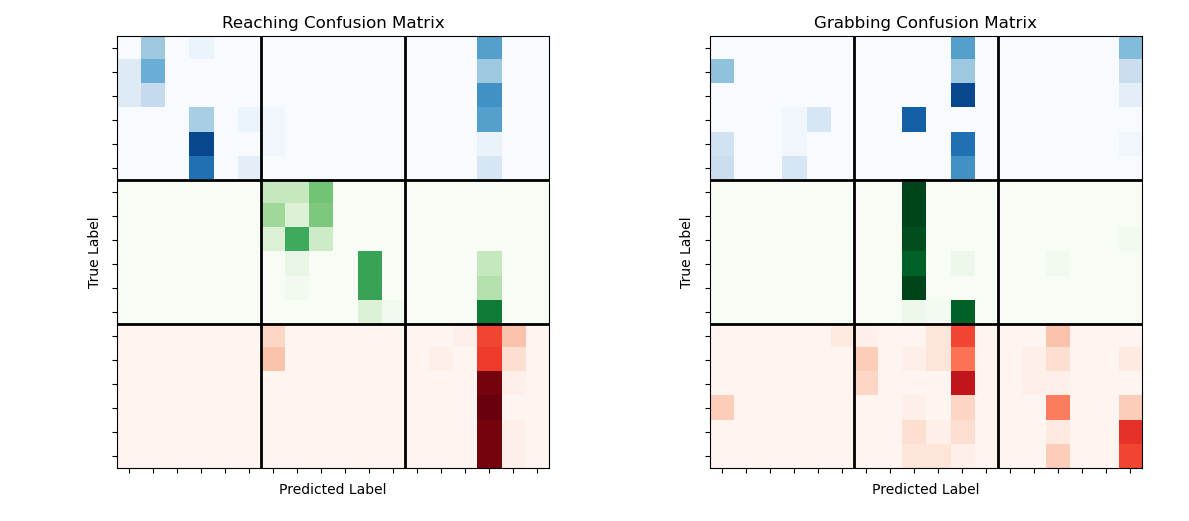

In [32]:
classes=["cube_small_red", "cube_small_green", "cube_small_blue", "cube_large_red", "cube_large_green", "cube_large_blue",
         "capsule_small_red", "capsule_small_green", "capsule_small_blue", "capsule_large_red", "capsule_large_green", "capsule_large_blue",
         "ball_small_red", "ball_small_green", "ball_small_blue", "ball_large_red", "ball_large_green", "ball_large_blue"]
X_test, y_test=create_test_set(y_test_reach, y_test_grab, all_testing_reach, all_testing_grab, classes, split_style="min")
y_pred_reach_new=lr_reach.predict(X_test)
y_pred_grab_new=lr_grab.predict(X_test)

cm1 = confusion_matrix(y_test, y_pred_reach_new, labels=classes)#, normalize="pred")
cm2 = confusion_matrix(y_test, y_pred_grab_new, labels=classes)#, normalize="pred")


image_paths = {
    "cube_small_red": "class_emojis/cube_red_small.png",
    "cube_small_green": "class_emojis/cube_green_small.png",
    "cube_small_blue": "class_emojis/cube_blue_small.png",
    "cube_large_red": "class_emojis/cube_red_large.png",
    "cube_large_green": "class_emojis/cube_green_large.png",
    "cube_large_blue": "class_emojis/cube_blue_large.png",
    "capsule_small_red": "class_emojis/capsule_red_small.png",
    "capsule_small_green": "class_emojis/capsule_green_small.png",
    "capsule_small_blue": "class_emojis/capsule_blue_small.png",
    "capsule_large_red": "class_emojis/capsule_red_large.png",
    "capsule_large_green": "class_emojis/capsule_green_large.png",
    "capsule_large_blue": "class_emojis/capsule_blue_large.png",
    "ball_small_red": "class_emojis/ball_red_small.png",
    "ball_small_green": "class_emojis/ball_green_small.png",
    "ball_small_blue": "class_emojis/ball_blue_small.png",
    "ball_large_red": "class_emojis/ball_red_large.png",
    "ball_large_green": "class_emojis/ball_green_large.png",
    "ball_large_blue": "class_emojis/ball_blue_large.png"}


#make_plots(cm1, cm2)
make_plots_with_images(cm1, cm2, classes, image_paths, group_size=6, groups=['cube', 'capsule', 'ball'], lines=True)

Number per class in testing reach:  {'cube_small_red': 80, 'cube_small_green': 96, 'cube_small_blue': 48, 'cube_large_red': 48, 'cube_large_green': 80, 'cube_large_blue': 48, 'capsule_small_red': 32, 'capsule_small_green': 32, 'capsule_small_blue': 32, 'capsule_large_red': 32, 'capsule_large_green': 32, 'capsule_large_blue': 48, 'ball_small_red': 96, 'ball_small_green': 96, 'ball_small_blue': 80, 'ball_large_red': 80, 'ball_large_green': 48, 'ball_large_blue': 80}
Number per class in testing grab:  {'cube_small_red': 96, 'cube_small_green': 96, 'cube_small_blue': 112, 'cube_large_red': 80, 'cube_large_green': 32, 'cube_large_blue': 64, 'capsule_small_red': 48, 'capsule_small_green': 16, 'capsule_small_blue': 16, 'capsule_large_red': 48, 'capsule_large_green': 16, 'capsule_large_blue': 48, 'ball_small_red': 112, 'ball_small_green': 96, 'ball_small_blue': 80, 'ball_large_red': 96, 'ball_large_green': 64, 'ball_large_blue': 32}
Number of training samples: 1888


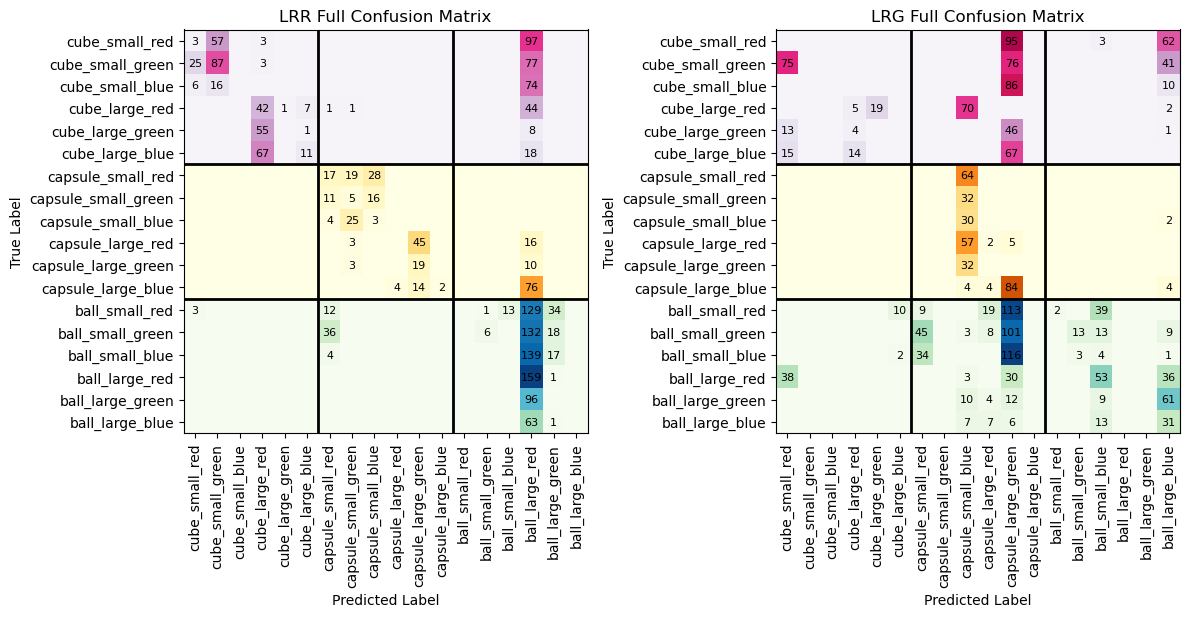

In [70]:
#What happens if I keep the classes unbalanced?
X_test, y_test=create_test_set(y_test_reach, y_test_grab, all_testing_reach, all_testing_grab, classes, split_style="max")
print("Number of training samples:", len(y_test)) #-> more, but unbalanced training data does not actually lead to better/clearer confusion matrices

y_pred_reach_new=lr_reach.predict(X_test)
y_pred_grab_new=lr_grab.predict(X_test)

cm1 = confusion_matrix(y_test, y_pred_reach_new, labels=classes)#, normalize="pred")
cm2 = confusion_matrix(y_test, y_pred_grab_new, labels=classes)#, normalize="pred")
make_plots(cm1, cm2, numbers=True, title="Full")

While balanced, the above model is not good at actually predicting things. I therefore now analyse by only using a certain subset in more detail to see which parts of an object actually influence the prediction most. I start with color, because here we can clearly see for the small objects, that color is least meaningful.

Now, I will do the same analysis but on a different layer to see if something changes in the hidden states.

In [37]:
et_indexed_hidden_states(hidden_states_cube_small_red[:3], reaching_grabbing_differences_cube_small_red[:3], layer_index=layer_index)

(1536,)

Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  32
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of tim

C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Training done, scoring...
Number per class in testing reach:  {'cube_small_red': 80, 'cube_small_green': 96, 'cube_small_blue': 48, 'cube_large_red': 48, 'cube_large_green': 80, 'cube_large_blue': 48, 'capsule_small_red': 32, 'capsule_small_green': 32, 'capsule_small_blue': 32, 'capsule_large_red': 32, 'capsule_large_green': 32, 'capsule_large_blue': 48, 'ball_small_red': 96, 'ball_small_green': 96, 'ball_small_blue': 80, 'ball_large_red': 80, 'ball_large_green': 48, 'ball_large_blue': 80}
Number per class in testing grab:  {'cube_small_red': 96, 'cube_small_green': 96, 'cube_small_blue': 112, 'cube_large_red': 80, 'cube_large_green': 32, 'cube_large_blue': 64, 'capsule_small_red': 48, 'capsule_small_green': 16, 'capsule_small_blue': 16, 'capsule_large_red': 48, 'capsule_large_green': 16, 'capsule_large_blue': 48, 'ball_small_red': 112, 'ball_small_green': 96, 'ball_small_blue': 80, 'ball_large_red': 96, 'ball_large_green': 64, 'ball_large_blue': 32}
Global minimal timesteps per class:

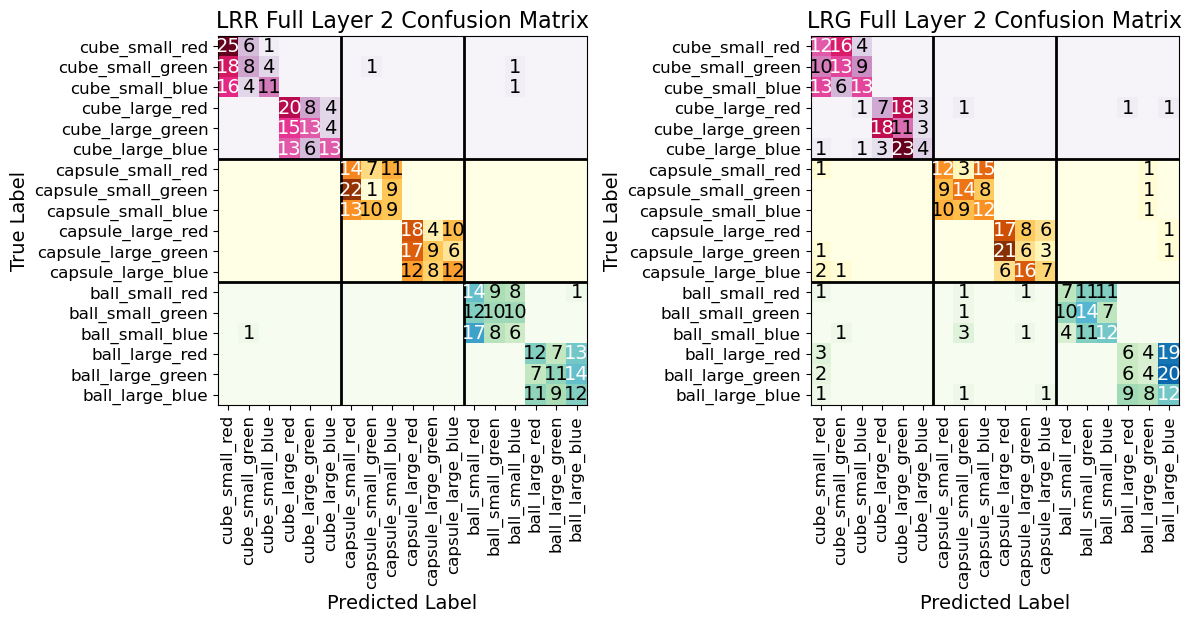

Results Full layer 2 Reach
Full Metric:  [0.375]
Accuracy: mean=0.3750, std=nan, var=nan
Full Metric:  [0.3714071]
F1: mean=0.3714, std=nan, var=nan
Full Metric:  [0.38606178]
Precision: mean=0.3861, std=nan, var=nan
Full Metric:  [0.375]
Recall: mean=0.3750, std=nan, var=nan
Results Full layer 2 Grab
Full Metric:  [0.30381944]
Accuracy: mean=0.3038, std=nan, var=nan
Full Metric:  [0.29708381]
F1: mean=0.2971, std=nan, var=nan
Full Metric:  [0.30767278]
Precision: mean=0.3077, std=nan, var=nan
Full Metric:  [0.30381944]
Recall: mean=0.3038, std=nan, var=nan
-----------------
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:

C:\Users\kulma\anaconda3\lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\kulma\anaconda3\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kulma\AppData\Local\Temp\ipykernel_4652\243469988.py:26: RuntimeWarning: Degrees of freedom <= 0 for slice
  print(f"{m.capitalize()}: "
C:\Users\kulma\anaconda3\lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\kulma\anaconda3\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kulma\AppData\Local\Temp\ipykernel_4652\243469988.py:26: RuntimeWarning: Degrees of freedom <= 0 for slice
  print(f"{m.capitalize()}: "
C:\Users\kul

Training done, scoring...
Number per class in testing reach:  {'cube_small_red': 80, 'cube_small_green': 96, 'cube_small_blue': 48, 'cube_large_red': 48, 'cube_large_green': 80, 'cube_large_blue': 48, 'capsule_small_red': 32, 'capsule_small_green': 32, 'capsule_small_blue': 32, 'capsule_large_red': 32, 'capsule_large_green': 32, 'capsule_large_blue': 48, 'ball_small_red': 96, 'ball_small_green': 96, 'ball_small_blue': 80, 'ball_large_red': 80, 'ball_large_green': 48, 'ball_large_blue': 80}
Number per class in testing grab:  {'cube_small_red': 96, 'cube_small_green': 96, 'cube_small_blue': 112, 'cube_large_red': 80, 'cube_large_green': 32, 'cube_large_blue': 64, 'capsule_small_red': 48, 'capsule_small_green': 16, 'capsule_small_blue': 16, 'capsule_large_red': 48, 'capsule_large_green': 16, 'capsule_large_blue': 48, 'ball_small_red': 112, 'ball_small_green': 96, 'ball_small_blue': 80, 'ball_large_red': 96, 'ball_large_green': 64, 'ball_large_blue': 32}
Global minimal timesteps per class:

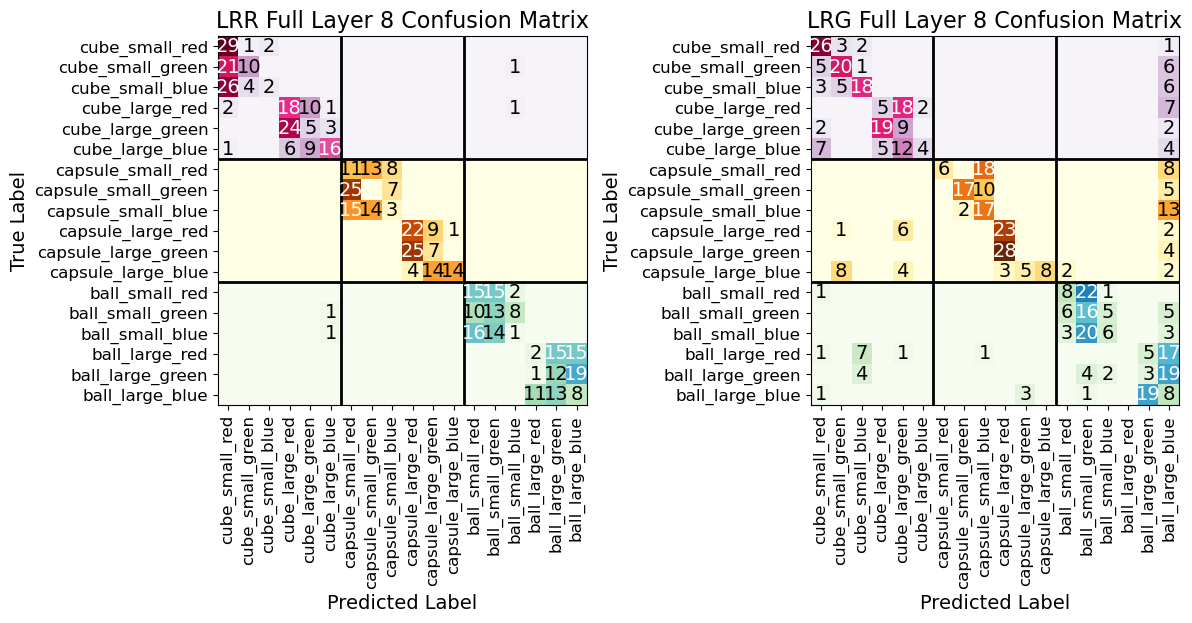

Results Full layer 8 Reach
Full Metric:  [0.3125]
Accuracy: mean=0.3125, std=nan, var=nan
Full Metric:  [0.2840953]
F1: mean=0.2841, std=nan, var=nan
Full Metric:  [0.30133012]
Precision: mean=0.3013, std=nan, var=nan
Full Metric:  [0.3125]
Recall: mean=0.3125, std=nan, var=nan
Results Full layer 8 Grab
Full Metric:  [0.31076389]
Accuracy: mean=0.3108, std=nan, var=nan
Full Metric:  [0.3060483]
F1: mean=0.3060, std=nan, var=nan
Full Metric:  [0.47777085]
Precision: mean=0.4778, std=nan, var=nan
Full Metric:  [0.31076389]
Recall: mean=0.3108, std=nan, var=nan
-----------------
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers:  17
Number of timesteps:  33
Number of layers

C:\Users\kulma\anaconda3\lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\kulma\anaconda3\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kulma\AppData\Local\Temp\ipykernel_4652\243469988.py:26: RuntimeWarning: Degrees of freedom <= 0 for slice
  print(f"{m.capitalize()}: "
C:\Users\kulma\anaconda3\lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\kulma\anaconda3\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kulma\AppData\Local\Temp\ipykernel_4652\243469988.py:26: RuntimeWarning: Degrees of freedom <= 0 for slice
  print(f"{m.capitalize()}: "


Training done, scoring...
Number per class in testing reach:  {'cube_small_red': 80, 'cube_small_green': 96, 'cube_small_blue': 48, 'cube_large_red': 48, 'cube_large_green': 80, 'cube_large_blue': 48, 'capsule_small_red': 32, 'capsule_small_green': 32, 'capsule_small_blue': 32, 'capsule_large_red': 32, 'capsule_large_green': 32, 'capsule_large_blue': 48, 'ball_small_red': 96, 'ball_small_green': 96, 'ball_small_blue': 80, 'ball_large_red': 80, 'ball_large_green': 48, 'ball_large_blue': 80}
Number per class in testing grab:  {'cube_small_red': 96, 'cube_small_green': 96, 'cube_small_blue': 112, 'cube_large_red': 80, 'cube_large_green': 32, 'cube_large_blue': 64, 'capsule_small_red': 48, 'capsule_small_green': 16, 'capsule_small_blue': 16, 'capsule_large_red': 48, 'capsule_large_green': 16, 'capsule_large_blue': 48, 'ball_small_red': 112, 'ball_small_green': 96, 'ball_small_blue': 80, 'ball_large_red': 96, 'ball_large_green': 64, 'ball_large_blue': 32}
Global minimal timesteps per class:

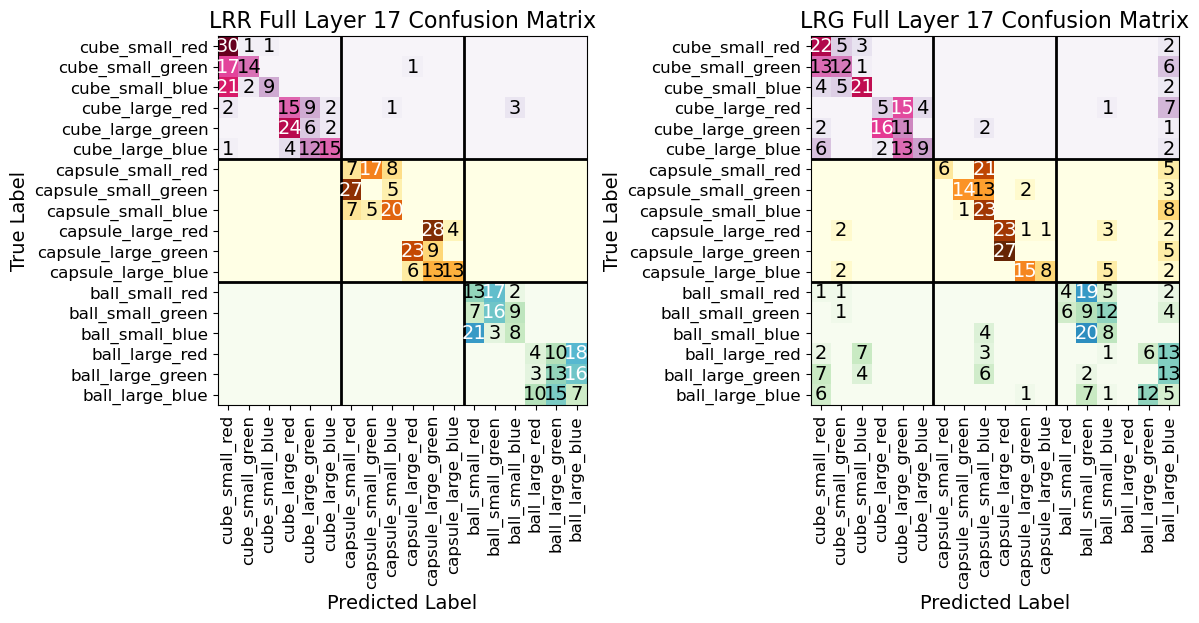

Results Full layer 17 Reach
Full Metric:  [0.31076389]
Accuracy: mean=0.3108, std=nan, var=nan
Full Metric:  [0.30720721]
F1: mean=0.3072, std=nan, var=nan
Full Metric:  [0.34528707]
Precision: mean=0.3453, std=nan, var=nan
Full Metric:  [0.31076389]
Recall: mean=0.3108, std=nan, var=nan
Results Full layer 17 Grab
Full Metric:  [0.30902778]
Accuracy: mean=0.3090, std=nan, var=nan
Full Metric:  [0.29886547]
F1: mean=0.2989, std=nan, var=nan
Full Metric:  [0.40312236]
Precision: mean=0.4031, std=nan, var=nan
Full Metric:  [0.30902778]
Recall: mean=0.3090, std=nan, var=nan
-----------------


C:\Users\kulma\anaconda3\lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\kulma\anaconda3\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kulma\AppData\Local\Temp\ipykernel_4652\243469988.py:26: RuntimeWarning: Degrees of freedom <= 0 for slice
  print(f"{m.capitalize()}: "
C:\Users\kulma\anaconda3\lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\kulma\anaconda3\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kulma\AppData\Local\Temp\ipykernel_4652\243469988.py:26: RuntimeWarning: Degrees of freedom <= 0 for slice
  print(f"{m.capitalize()}: "


In [54]:
#layer_index=8

for layer_index in [1, 7, 16]:#16]:#range(16):
    #Cube
    reaching_cube_train_small_red, grabbing_cube_train_small_red=get_indexed_hidden_states(hidden_states_cube_small_red[:3], reaching_grabbing_differences_cube_small_red[:3], layer_index=layer_index)
    reaching_cube_test_small_red, grabbing_cube_test_small_red=get_indexed_hidden_states([hidden_states_cube_small_red[-1]], [reaching_grabbing_differences_cube_small_red[-1]], layer_index=layer_index)
    reaching_cube_train_small_green, grabbing_cube_train_small_green=get_indexed_hidden_states(hidden_states_cube_small_green[:3], reaching_grabbing_differences_cube_small_green[:3], layer_index=layer_index)
    reaching_cube_test_small_green, grabbing_cube_test_small_green=get_indexed_hidden_states([hidden_states_cube_small_green[-1]], [reaching_grabbing_differences_cube_small_green[-1]], layer_index=layer_index)
    reaching_cube_train_small_blue, grabbing_cube_train_small_blue=get_indexed_hidden_states(hidden_states_cube_small_blue[:3], reaching_grabbing_differences_cube_small_blue[:3], layer_index=layer_index)
    reaching_cube_test_small_blue, grabbing_cube_test_small_blue=get_indexed_hidden_states([hidden_states_cube_small_blue[-1]], [reaching_grabbing_differences_cube_small_blue[-1]], layer_index=layer_index)
    
    reaching_cube_train_large_red, grabbing_cube_train_large_red=get_indexed_hidden_states(hidden_states_cube_large_red[:3], reaching_grabbing_differences_cube_large_red[:3], layer_index=layer_index)
    reaching_cube_test_large_red, grabbing_cube_test_large_red=get_indexed_hidden_states([hidden_states_cube_large_red[-1]], [reaching_grabbing_differences_cube_large_red[-1]], layer_index=layer_index)
    reaching_cube_train_large_green, grabbing_cube_train_large_green=get_indexed_hidden_states(hidden_states_cube_large_green[:3], reaching_grabbing_differences_cube_large_green[:3], layer_index=layer_index)
    reaching_cube_test_large_green, grabbing_cube_test_large_green=get_indexed_hidden_states([hidden_states_cube_large_green[-1]], [reaching_grabbing_differences_cube_large_green[-1]], layer_index=layer_index)
    reaching_cube_train_large_blue, grabbing_cube_train_large_blue=get_indexed_hidden_states(hidden_states_cube_large_blue[:3], reaching_grabbing_differences_cube_large_blue[:3], layer_index=layer_index)
    reaching_cube_test_large_blue, grabbing_cube_test_large_blue=get_indexed_hidden_states([hidden_states_cube_large_blue[-1]], [reaching_grabbing_differences_cube_large_blue[-1]], layer_index=layer_index)
    
    #Capsule
    reaching_capsule_train_small_red, grabbing_capsule_train_small_red=get_indexed_hidden_states(hidden_states_capsule_small_red[:3], reaching_grabbing_differences_capsule_small_red[:3], layer_index=layer_index)
    reaching_capsule_test_small_red, grabbing_capsule_test_small_red=get_indexed_hidden_states([hidden_states_capsule_small_red[-1]], [reaching_grabbing_differences_capsule_small_red[-1]], layer_index=layer_index)
    reaching_capsule_train_small_green, grabbing_capsule_train_small_green=get_indexed_hidden_states(hidden_states_capsule_small_green[:2], reaching_grabbing_differences_capsule_small_green[:2], layer_index=layer_index)
    reaching_capsule_test_small_green, grabbing_capsule_test_small_green=get_indexed_hidden_states([hidden_states_capsule_small_green[-1]], [reaching_grabbing_differences_capsule_small_green[-1]], layer_index=layer_index)
    reaching_capsule_train_small_blue, grabbing_capsule_train_small_blue=get_indexed_hidden_states(hidden_states_capsule_small_blue[:3], reaching_grabbing_differences_capsule_small_blue[:3], layer_index=layer_index)
    reaching_capsule_test_small_blue, grabbing_capsule_test_small_blue=get_indexed_hidden_states([hidden_states_capsule_small_blue[-1]], [reaching_grabbing_differences_capsule_small_blue[-1]], layer_index=layer_index)
    
    reaching_capsule_train_large_red, grabbing_capsule_train_large_red=get_indexed_hidden_states(hidden_states_capsule_large_red[:3], reaching_grabbing_differences_capsule_large_red[:3], layer_index=layer_index)
    reaching_capsule_test_large_red, grabbing_capsule_test_large_red=get_indexed_hidden_states([hidden_states_capsule_large_red[-1]], [reaching_grabbing_differences_capsule_large_red[-1]], layer_index=layer_index)
    reaching_capsule_train_large_green, grabbing_capsule_train_large_green=get_indexed_hidden_states(hidden_states_capsule_large_green[:3], reaching_grabbing_differences_capsule_large_green[:3], layer_index=layer_index)
    reaching_capsule_test_large_green, grabbing_capsule_test_large_green=get_indexed_hidden_states([hidden_states_capsule_large_green[-1]], [reaching_grabbing_differences_capsule_large_green[-1]], layer_index=layer_index)
    reaching_capsule_train_large_blue, grabbing_capsule_train_large_blue=get_indexed_hidden_states(hidden_states_capsule_large_blue[:3], reaching_grabbing_differences_capsule_large_blue[:3], layer_index=layer_index)
    reaching_capsule_test_large_blue, grabbing_capsule_test_large_blue=get_indexed_hidden_states([hidden_states_capsule_large_blue[-1]], [reaching_grabbing_differences_capsule_large_blue[-1]], layer_index=layer_index)
    
    
    #Ball
    reaching_ball_train_small_red, grabbing_ball_train_small_red=get_indexed_hidden_states(hidden_states_ball_small_red[:3], reaching_grabbing_differences_ball_small_red[:3], layer_index=layer_index)
    reaching_ball_test_small_red, grabbing_ball_test_small_red=get_indexed_hidden_states([hidden_states_ball_small_red[-1]], [reaching_grabbing_differences_ball_small_red[-1]], layer_index=layer_index)
    reaching_ball_train_small_green, grabbing_ball_train_small_green=get_indexed_hidden_states(hidden_states_ball_small_green[:3], reaching_grabbing_differences_ball_small_green[:3], layer_index=layer_index)
    reaching_ball_test_small_green, grabbing_ball_test_small_green=get_indexed_hidden_states([hidden_states_ball_small_green[-1]], [reaching_grabbing_differences_ball_small_green[-1]], layer_index=layer_index)
    reaching_ball_train_small_blue, grabbing_ball_train_small_blue=get_indexed_hidden_states(hidden_states_ball_small_blue[:3], reaching_grabbing_differences_ball_small_blue[:3], layer_index=layer_index)
    reaching_ball_test_small_blue, grabbing_ball_test_small_blue=get_indexed_hidden_states([hidden_states_ball_small_blue[-1]], [reaching_grabbing_differences_ball_small_blue[-1]], layer_index=layer_index)
    
    reaching_ball_train_large_red, grabbing_ball_train_large_red=get_indexed_hidden_states(hidden_states_ball_large_red[:3], reaching_grabbing_differences_ball_large_red[:3], layer_index=layer_index)
    reaching_ball_test_large_red, grabbing_ball_test_large_red=get_indexed_hidden_states([hidden_states_ball_large_red[-1]], [reaching_grabbing_differences_ball_large_red[-1]], layer_index=layer_index)
    reaching_ball_train_large_green, grabbing_ball_train_large_green=get_indexed_hidden_states(hidden_states_ball_large_green[:3], reaching_grabbing_differences_ball_large_green[:3], layer_index=layer_index)
    reaching_ball_test_large_green, grabbing_ball_test_large_green=get_indexed_hidden_states([hidden_states_ball_large_green[-1]], [reaching_grabbing_differences_ball_large_green[-1]], layer_index=layer_index)
    reaching_ball_train_large_blue, grabbing_ball_train_large_blue=get_indexed_hidden_states(hidden_states_ball_large_blue[:3], reaching_grabbing_differences_ball_large_blue[:3], layer_index=layer_index)
    reaching_ball_test_large_blue, grabbing_ball_test_large_blue=get_indexed_hidden_states([hidden_states_ball_large_blue[-1]], [reaching_grabbing_differences_ball_large_blue[-1]], layer_index=layer_index)
    
    
    #This is a simple, just concatenate everything and use it for training approach, but in reality I might have to assimilate reach and grab
    full_training_set_reach=np.array(reaching_cube_train_small_red+reaching_cube_train_small_green+reaching_cube_train_small_blue+
                          reaching_cube_train_large_red+reaching_cube_train_large_green+reaching_cube_train_large_blue+
                          reaching_capsule_train_small_red+reaching_capsule_train_small_green+reaching_capsule_train_small_blue+
                          reaching_capsule_train_large_red+reaching_capsule_train_large_green+reaching_capsule_train_large_blue+
                          reaching_ball_train_small_red+reaching_ball_train_small_green+reaching_ball_train_small_blue+
                          reaching_ball_train_large_red+reaching_ball_train_large_green+reaching_ball_train_large_blue)
    all_training_reach=[reaching_cube_train_small_red,reaching_cube_train_small_green,reaching_cube_train_small_blue,
                          reaching_cube_train_large_red,reaching_cube_train_large_green,reaching_cube_train_large_blue,
                          reaching_capsule_train_small_red,reaching_capsule_train_small_green,reaching_capsule_train_small_blue,
                          reaching_capsule_train_large_red,reaching_capsule_train_large_green,reaching_capsule_train_large_blue,
                          reaching_ball_train_small_red,reaching_ball_train_small_green,reaching_ball_train_small_blue,
                          reaching_ball_train_large_red,reaching_ball_train_large_green,reaching_ball_train_large_blue]
    
    full_testing_set_reach=np.array(reaching_cube_test_small_red+reaching_cube_test_small_green+reaching_cube_test_small_blue+
                          reaching_cube_test_large_red+reaching_cube_test_large_green+reaching_cube_test_large_blue+
                          reaching_capsule_test_small_red+reaching_capsule_test_small_green+reaching_capsule_test_small_blue+
                          reaching_capsule_test_large_red+reaching_capsule_test_large_green+reaching_capsule_test_large_blue+
                          reaching_ball_test_small_red+reaching_ball_test_small_green+reaching_ball_test_small_blue+
                          reaching_ball_test_large_red+reaching_ball_test_large_green+reaching_ball_test_large_blue)
    all_testing_reach=[reaching_cube_test_small_red,reaching_cube_test_small_green,reaching_cube_test_small_blue,
                          reaching_cube_test_large_red,reaching_cube_test_large_green,reaching_cube_test_large_blue,
                          reaching_capsule_test_small_red,reaching_capsule_test_small_green,reaching_capsule_test_small_blue,
                          reaching_capsule_test_large_red,reaching_capsule_test_large_green,reaching_capsule_test_large_blue,
                          reaching_ball_test_small_red,reaching_ball_test_small_green,reaching_ball_test_small_blue,
                          reaching_ball_test_large_red,reaching_ball_test_large_green,reaching_ball_test_large_blue]
    
    
    full_training_set_grab=np.array(grabbing_cube_train_small_red+grabbing_cube_train_small_green+grabbing_cube_train_small_blue+
                          grabbing_cube_train_large_red+grabbing_cube_train_large_green+grabbing_cube_train_large_blue+
                          grabbing_capsule_train_small_red+grabbing_capsule_train_small_green+grabbing_capsule_train_small_blue+
                          grabbing_capsule_train_large_red+grabbing_capsule_train_large_green+grabbing_capsule_train_large_blue+
                          grabbing_ball_train_small_red+grabbing_ball_train_small_green+grabbing_ball_train_small_blue+
                          grabbing_ball_train_large_red+grabbing_ball_train_large_green+grabbing_ball_train_large_blue)
    all_training_grab=[grabbing_cube_train_small_red,grabbing_cube_train_small_green,grabbing_cube_train_small_blue,
                          grabbing_cube_train_large_red,grabbing_cube_train_large_green,grabbing_cube_train_large_blue,
                          grabbing_capsule_train_small_red,grabbing_capsule_train_small_green,grabbing_capsule_train_small_blue,
                          grabbing_capsule_train_large_red,grabbing_capsule_train_large_green,grabbing_capsule_train_large_blue,
                          grabbing_ball_train_small_red,grabbing_ball_train_small_green,grabbing_ball_train_small_blue,
                          grabbing_ball_train_large_red,grabbing_ball_train_large_green,grabbing_ball_train_large_blue]
    
    full_testing_set_grab=np.array(grabbing_cube_test_small_red+grabbing_cube_test_small_green+grabbing_cube_test_small_blue+
                          grabbing_cube_test_large_red+grabbing_cube_test_large_green+grabbing_cube_test_large_blue+
                          grabbing_capsule_test_small_red+grabbing_capsule_test_small_green+grabbing_capsule_test_small_blue+
                          grabbing_capsule_test_large_red+grabbing_capsule_test_large_green+grabbing_capsule_test_large_blue+
                          grabbing_ball_test_small_red+grabbing_ball_test_small_green+grabbing_ball_test_small_blue+
                          grabbing_ball_test_large_red+grabbing_ball_test_large_green+grabbing_ball_test_large_blue)
    
    all_testing_grab=[grabbing_cube_test_small_red,grabbing_cube_test_small_green,grabbing_cube_test_small_blue,
                          grabbing_cube_test_large_red,grabbing_cube_test_large_green,grabbing_cube_test_large_blue,
                          grabbing_capsule_test_small_red,grabbing_capsule_test_small_green,grabbing_capsule_test_small_blue,
                          grabbing_capsule_test_large_red,grabbing_capsule_test_large_green,grabbing_capsule_test_large_blue,
                          grabbing_ball_test_small_red,grabbing_ball_test_small_green,grabbing_ball_test_small_blue,
                          grabbing_ball_test_large_red,grabbing_ball_test_large_green,grabbing_ball_test_large_blue]

    classes=["cube_small_red", "cube_small_green", "cube_small_blue", "cube_large_red", "cube_large_green", "cube_large_blue",
         "capsule_small_red", "capsule_small_green", "capsule_small_blue", "capsule_large_red", "capsule_large_green", "capsule_large_blue",
         "ball_small_red", "ball_small_green", "ball_small_blue", "ball_large_red", "ball_large_green", "ball_large_blue"]
    limit=4000
    
    all_predictions_reach=[]
    all_predictions_grab=[]
    
    for rs in [50]:#[5, 42, 11, 9, 50]:
        np.random.seed(rs)
        random.seed(rs)
    
        #After assimilation these should be of equal length ! (which they are)
        print("Preparing training sets")
        new_full_training_set_reach, new_full_training_set_grab, new_lengths=assimilate_reach_grab_full(all_training_reach, all_training_grab)
        print("Len assimilates reach: ", len(new_full_training_set_reach))
        print("Len assimilates grab: ", len(new_full_training_set_grab))
    
    
        #print("One instance: ", full_training_set_reach[0].shape)
        #print("One instance type: ", type(full_training_set_reach[0]))
        
        #Now, to fit an LR model, I need y values... in my case these somehow need to correpsond to the combined classes...
        # that means I have to make combined classes
        
        
        #y_train_reach = np.array([label for idx, x in enumerate(all_training_reach) for label in [classes[idx]] * len(x)])
        #y_train_grab=np.array([label for idx, x in enumerate(all_training_grab) for label in [classes[idx]] * len(x)])
        
        y_train_reach=np.array([label for idx in range(len(all_training_reach)) for label in [classes[idx]] * new_lengths[idx]])
        y_train_grab=np.array([label for idx in range(len(all_training_grab)) for label in [classes[idx]] * new_lengths[idx]])
        
        y_test_reach=np.array([label for idx, x in enumerate(all_testing_reach) for label in [classes[idx]] * len(x)])
        y_test_grab=np.array([label for idx, x in enumerate(all_testing_grab) for label in [classes[idx]] * len(x)])
        
        #Once we have the traing set done, we now need to look at the test
        #I want a fully balanced dataset for reach and grab phases
        X_test, y_test=create_test_set(y_test_reach, y_test_grab, all_testing_reach, all_testing_grab, classes)
        
        #After getting the training labels, I now want to shuffle them in the same way as the X values
        X_train_reach, y_train_reach = shuffle(new_full_training_set_reach, y_train_reach, random_state=rs)
        X_train_grab, y_train_grab = shuffle(new_full_training_set_grab, y_train_grab, random_state=rs)
    
        print("Beginning training...")
        lr_reach=LogisticRegression(max_iter=limit)
        lr_reach.fit(X_train_reach, y_train_reach)
        
        lr_grab=LogisticRegression(max_iter=limit)
        lr_grab.fit(X_train_grab, y_train_grab)
        print("Training done, scoring...")
        #The trained models now have to be evaluated.
        all_predictions_reach.append(lr_reach.predict(X_test))
        all_predictions_grab.append(lr_grab.predict(X_test))
        
        #print("Accuracy reach: ", acc_reach)
        #print("Accuracy grab: ", acc_grab)
    
    #Here I just plot the results from the last random seed, because its just one example
    X_test, y_test=create_test_set(y_test_reach, y_test_grab, all_testing_reach, all_testing_grab, classes, split_style="min")
    print("Number of training samples:", len(y_test)) #-> more, but unbalanced training data does not actually lead to better/clearer confusion matrices
    
    y_pred_reach_new=lr_reach.predict(X_test)
    y_pred_grab_new=lr_grab.predict(X_test)

    cm1 = confusion_matrix(y_test, y_pred_reach_new, labels=classes)#, normalize="pred")
    cm2 = confusion_matrix(y_test, y_pred_grab_new, labels=classes)#, normalize="pred")
    make_plots(cm1, cm2, numbers=True, title=f"Full Layer {layer_index+1}", save=True)

    print(f"Results Full layer {layer_index+1} Reach")
    calculate_mean_results_random_seeds(y_test, all_predictions_reach)#, class_names=classes)
    print(f"Results Full layer {layer_index+1} Grab")
    calculate_mean_results_random_seeds(y_test, all_predictions_grab)#, class_names=classes)
    print("-----------------")

    
        


C:\Users\kulma\AppData\Local\Temp\ipykernel_4652\3654254218.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


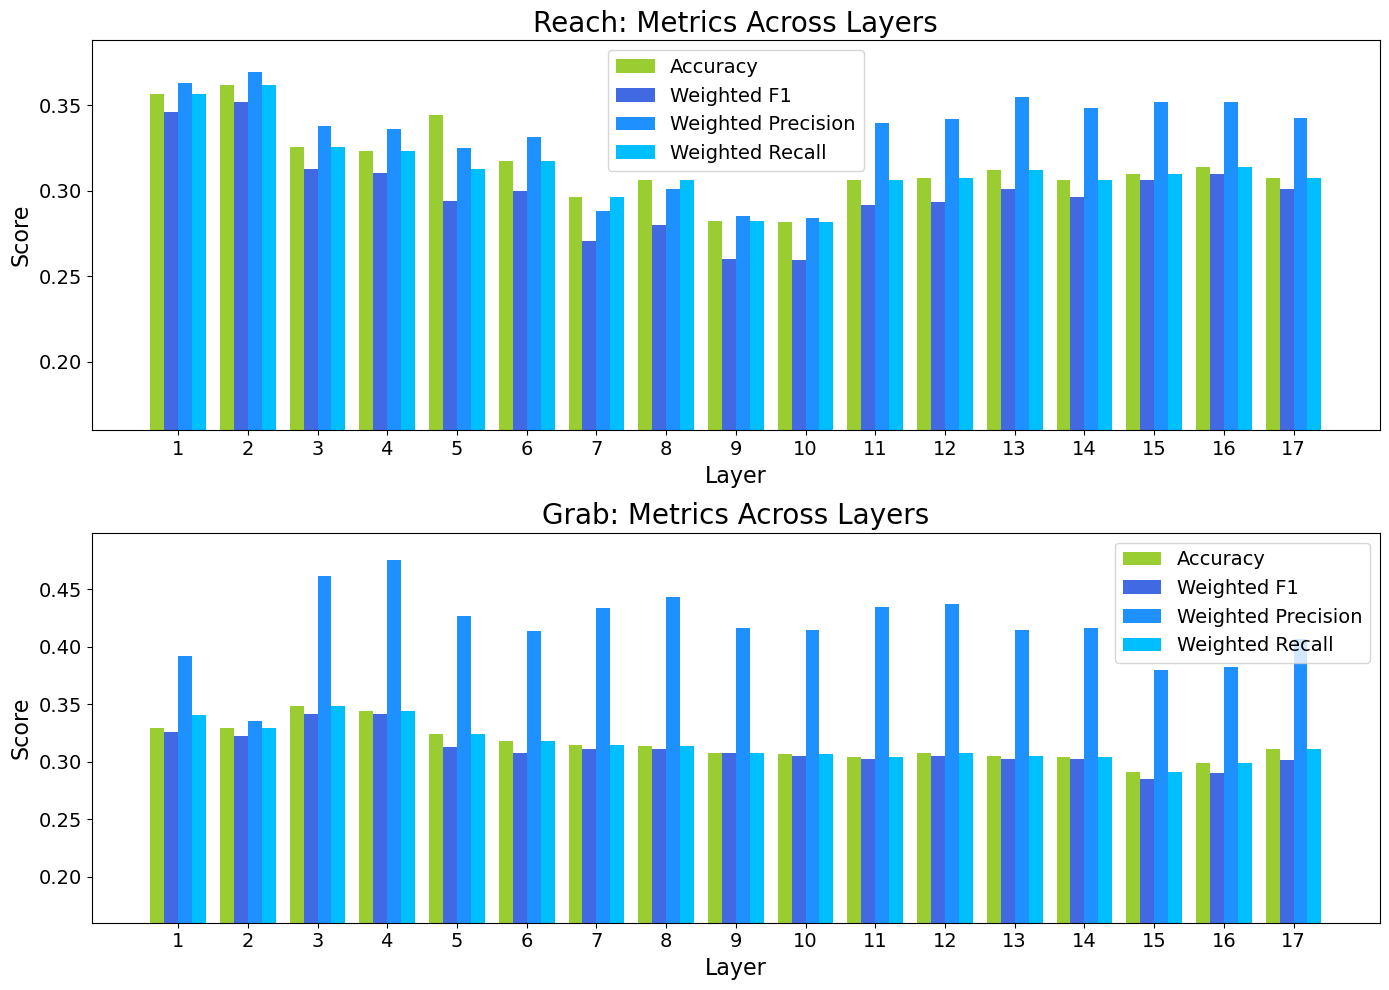

In [50]:
#Temporary, I need to plot the 16 accuracy values from he 16 layers hidden states, but I dont want to rerun the entire notbook, because it takes very long
import matplotlib.pyplot as plt
import numpy as np

accuracies_reach=[0.3566, 0.3622, 0.3257, 0.3233, 0.3444, 0.3174, 0.2965, 0.3063, 0.2823, 0.2819, 0.3063, 0.3076, 0.3125, 0.3066, 0.3097, 0.3142, 0.3076]
f1s_reach=[0.3461, 0.3522,0.3129, 0.3105,  0.2938, 0.2998, 0.2706, 0.2802, 0.2599, 0.2597, 0.2918, 0.2935, 0.3010, 0.2964, 0.3061, 0.3101, 0.3009]
precs_reach=[0.3633, 0.3696, 0.3379, 0.3363, 0.3253, 0.3314, 0.2880, 0.3014,0.2856, 0.2840,  0.3396, 0.3419, 0.3547, 0.3484, 0.3521, 0.3520, 0.3429]
recs_reach=[0.3566, 0.3622, 0.3257, 0.3233, 0.3128, 0.3174, 0.2965, 0.3063, 0.2823, 0.2819,0.3063,  0.3076, 0.3125, 0.3066, 0.3097, 0.3142, 0.3076]


accuracies_grab=[0.3295, 0.3295, 0.3486, 0.3444, 0.3243, 0.3177, 0.3149, 0.3139, 0.3080, 0.3069, 0.3042, 0.3076, 0.3049, 0.3042, 0.2913, 0.2990, 0.3108]
f1s_grab=[0.3255, 0.3228, 0.3415, 0.3415, 0.3128, 0.3076, 0.3107, 0.3113, 0.3078, 0.3054, 0.3026, 0.3053, 0.3022, 0.3026, 0.2850, 0.2901, 0.3016]
precs_grab=[0.3919, 0.3357, 0.4613, 0.4754, 0.4272, 0.4141, 0.4341, 0.4432, 0.4168, 0.4146, 0.4347, 0.4369, 0.4148, 0.4167, 0.3795, 0.3827, 0.4069]
recs_grab=[0.3411, 0.3295, 0.3486, 0.3444, 0.3243, 0.3177, 0.3149, 0.3139, 0.3080, 0.3069, 0.3042, 0.3076, 0.3049, 0.3042, 0.2913, 0.2990, 0.3108]

metrics_reach = [accuracies_reach, f1s_reach, precs_reach, recs_reach]
metrics_grab = [accuracies_grab, f1s_grab, precs_grab, recs_grab]
labels = ['Accuracy', 'Weighted F1', 'Weighted Precision', 'Weighted Recall']
layers = np.arange(0, 17)
bar_width = 0.2
fig, axs = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)
colors=["yellowgreen", "royalblue", "dodgerblue", "deepskyblue"] #yellowgreen, crimson
def plot_metrics(ax, metrics, title):
    for i, metric in enumerate(metrics):
        offset = (i - 1.5) * bar_width
        ax.bar(layers + offset, metric, width=bar_width, label=labels[i], color=colors[i])
    ax.set_ylim(0.16)
    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Layer', fontsize=16)
    ax.set_ylabel('Score', fontsize=16)
    ax.set_xticks(range(17))
    ax.set_xticklabels(range(1, 18), fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.legend(fontsize=14)
plot_metrics(axs[0], metrics_reach, 'Reach: Metrics Across Layers')
plot_metrics(axs[1], metrics_grab,  'Grab: Metrics Across Layers')
plt.tight_layout()
plt.savefig("./reach_grab-full_all_layers.png")
plt.show()

classes=["cube_small_red", "cube_small_green", "cube_small_blue", "cube_large_red", "cube_large_green", "cube_large_blue",
         "capsule_small_red", "capsule_small_green", "capsule_small_blue", "capsule_large_red", "capsule_large_green", "capsule_large_blue",
         "ball_small_red", "ball_small_green", "ball_small_blue", "ball_large_red", "ball_large_green", "ball_large_blue"]
limit=4000

all_predictions_reach=[]
all_predictions_grab=[]

for rs in [5]:#, 42, 11, 9, 50]:
    np.random.seed(rs)
    random.seed(rs)

    #After assimilation these should be of equal length ! (which they are)
    print("Preparing training sets")
    new_full_training_set_reach, new_full_training_set_grab, new_lengths=assimilate_reach_grab_full(all_training_reach, all_training_grab)
    print("Len assimilates reach: ", len(new_full_training_set_reach))
    print("Len assimilates grab: ", len(new_full_training_set_grab))


    #print("One instance: ", full_training_set_reach[0].shape)
    #print("One instance type: ", type(full_training_set_reach[0]))
    
    #Now, to fit an LR model, I need y values... in my case these somehow need to correpsond to the combined classes...
    # that means I have to make combined classes
    
    
    #y_train_reach = np.array([label for idx, x in enumerate(all_training_reach) for label in [classes[idx]] * len(x)])
    #y_train_grab=np.array([label for idx, x in enumerate(all_training_grab) for label in [classes[idx]] * len(x)])
    
    y_train_reach=np.array([label for idx in range(len(all_training_reach)) for label in [classes[idx]] * new_lengths[idx]])
    y_train_grab=np.array([label for idx in range(len(all_training_grab)) for label in [classes[idx]] * new_lengths[idx]])
    
    y_test_reach=np.array([label for idx, x in enumerate(all_testing_reach) for label in [classes[idx]] * len(x)])
    y_test_grab=np.array([label for idx, x in enumerate(all_testing_grab) for label in [classes[idx]] * len(x)])
    
    #Once we have the traing set done, we now need to look at the test
    #I want a fully balanced dataset for reach and grab phases
    X_test, y_test=create_test_set(y_test_reach, y_test_grab, all_testing_reach, all_testing_grab, classes)
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach, y_train_reach = shuffle(new_full_training_set_reach, y_train_reach, random_state=rs)
    X_train_grab, y_train_grab = shuffle(new_full_training_set_grab, y_train_grab, random_state=rs)

    print("Beginning training...")
    lr_reach=LogisticRegression(max_iter=limit)
    lr_reach.fit(X_train_reach, y_train_reach)
    
    lr_grab=LogisticRegression(max_iter=limit)
    lr_grab.fit(X_train_grab, y_train_grab)
    print("Training done, scoring...")
    #The trained models now have to be evaluated.
    all_predictions_reach.append(lr_reach.predict(X_test))
    all_predictions_grab.append(lr_grab.predict(X_test))



    #print("Accuracy reach: ", acc_reach)
    #print("Accuracy grab: ", acc_grab)


#What happens if I keep the classes unbalanced?
X_test, y_test=create_test_set(y_test_reach, y_test_grab, all_testing_reach, all_testing_grab, classes, split_style="min")
print("Number of training samples:", len(y_test)) #-> more, but unbalanced training data does not actually lead to better/clearer confusion matrices

y_pred_reach_new=lr_reach.predict(X_test)
y_pred_grab_new=lr_grab.predict(X_test)

cm1 = confusion_matrix(y_test, y_pred_reach_new, labels=classes)#, normalize="pred")
cm2 = confusion_matrix(y_test, y_pred_grab_new, labels=classes)#, normalize="pred")
make_plots(cm1, cm2, numbers=True, title="Full")

## Color
Im now first analysing only the color parts. To make this independent from size and shape, I will train a model for each shape/size variation.

In [6]:
def train_lr(X_train_reach, X_train_grab, y_train_reach, y_train_grab, X_test, y_test, limit=4000, random_seed=42):
    lr_reach=LogisticRegression(max_iter=limit, random_state=random_seed)
    lr_reach.fit(X_train_reach, y_train_reach)
    
    lr_grab=LogisticRegression(max_iter=limit, random_state=random_seed)
    lr_grab.fit(X_train_grab, y_train_grab)
    
    #The trained models now have to be evaluated.
    acc_reach = lr_reach.score(X_test, y_test)
    acc_grab  = lr_grab.score(X_test, y_test)
    
    print("Accuracy reach: ", acc_reach)
    print("Accuracy grab: ", acc_grab)

    predicted_reach=lr_reach.predict(X_test)
    print(len(predicted_reach))
    predicted_grab=lr_grab.predict(X_test)
    
    return lr_reach, lr_grab, predicted_reach, predicted_grab

In [75]:
#New classes

#P.S: I made sure that reaching_cube_train_small_red etc is run at layer index 0
classes=["red", "green", "blue"]
random_seeds=[5, 9, 11, 42, 50]
all_predictions_reach_cube_small=[]
all_predictions_grab_cube_small=[]

all_predictions_reach_cube_large=[]
all_predictions_grab_cube_large=[]

for rs in random_seeds:
    np.random.seed(rs)
    random.seed(rs)
    #Cube
    #Small
    all_training_reach_cube_small=[reaching_cube_train_small_red,reaching_cube_train_small_green,reaching_cube_train_small_blue]
    all_testing_reach_cube_small=[reaching_cube_test_small_red,reaching_cube_test_small_green,reaching_cube_test_small_blue]
    all_training_grab_cube_small=[grabbing_cube_train_small_red,grabbing_cube_train_small_green,grabbing_cube_train_small_blue]
    all_testing_grab_cube_small=[grabbing_cube_test_small_red,grabbing_cube_test_small_green,grabbing_cube_test_small_blue]
    new_cube_small_training_set_reach, new_cube_small_training_set_grab, new_lengths_cube_small=assimilate_reach_grab_full(all_training_reach_cube_small, all_training_grab_cube_small)
    
    y_train_reach_cube_small=np.array([label for idx in range(len(all_training_reach_cube_small)) for label in [classes[idx]] * new_lengths_cube_small[idx]])
    y_train_grab_cube_small=np.array([label for idx in range(len(all_training_grab_cube_small)) for label in [classes[idx]] * new_lengths_cube_small[idx]])
    
    y_test_reach_cube_small=np.array([label for idx, x in enumerate(all_testing_reach_cube_small) for label in [classes[idx]] * len(x)])
    y_test_grab_cube_small=np.array([label for idx, x in enumerate(all_testing_grab_cube_small) for label in [classes[idx]] * len(x)])
    
    X_test_cube_small, y_test_cube_small=create_test_set(y_test_reach_cube_small, y_test_grab_cube_small, all_testing_reach_cube_small, all_testing_grab_cube_small, classes)
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach_cube_small, y_train_reach_cube_small = shuffle(new_cube_small_training_set_reach, y_train_reach_cube_small, random_state=rs)
    X_train_grab_cube_small, y_train_grab_cube_small = shuffle(new_cube_small_training_set_grab, y_train_grab_cube_small, random_state=rs)
    
    
    #Large
    all_training_reach_cube_large=[reaching_cube_train_large_red,reaching_cube_train_large_green,reaching_cube_train_large_blue]
    all_testing_reach_cube_large=[reaching_cube_test_large_red,reaching_cube_test_large_green,reaching_cube_test_large_blue]
    all_training_grab_cube_large=[grabbing_cube_train_large_red,grabbing_cube_train_large_green,grabbing_cube_train_large_blue]
    all_testing_grab_cube_large=[grabbing_cube_test_large_red,grabbing_cube_test_large_green,grabbing_cube_test_large_blue]
    new_cube_large_training_set_reach, new_cube_large_training_set_grab, new_lengths_cube_large=assimilate_reach_grab_full(all_training_reach_cube_large, all_training_grab_cube_large)
    
    y_train_reach_cube_large=np.array([label for idx in range(len(all_training_reach_cube_large)) for label in [classes[idx]] * new_lengths_cube_large[idx]])
    y_train_grab_cube_large=np.array([label for idx in range(len(all_training_grab_cube_large)) for label in [classes[idx]] * new_lengths_cube_large[idx]])
    
    y_test_reach_cube_large=np.array([label for idx, x in enumerate(all_testing_reach_cube_large) for label in [classes[idx]] * len(x)])
    y_test_grab_cube_large=np.array([label for idx, x in enumerate(all_testing_grab_cube_large) for label in [classes[idx]] * len(x)])
    
    X_test_cube_large, y_test_cube_large=create_test_set(y_test_reach_cube_large, y_test_grab_cube_large, all_testing_reach_cube_large, all_testing_grab_cube_large, classes)
    
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach_cube_large, y_train_reach_cube_large = shuffle(new_cube_large_training_set_reach, y_train_reach_cube_large, random_state=rs)
    X_train_grab_cube_large, y_train_grab_cube_large = shuffle(new_cube_large_training_set_grab, y_train_grab_cube_large, random_state=rs)
    
    
    lr_reach_cube_small, lr_grab_cube_small, predicted_reach_cube_small, predicted_grab_cube_small=train_lr(X_train_reach_cube_small, X_train_grab_cube_small, y_train_reach_cube_small, y_train_grab_cube_small, X_test_cube_small, y_test_cube_small, limit=4000, random_seed=rs)
    lr_reach_cube_large, lr_grab_cube_large, predicted_reach_cube_large, predicted_grab_cube_large=train_lr(X_train_reach_cube_large, X_train_grab_cube_large, y_train_reach_cube_large, y_train_grab_cube_large, X_test_cube_large, y_test_cube_large, limit=4000, random_seed=rs)
    
    all_predictions_reach_cube_small.append(predicted_reach_cube_small)
    all_predictions_grab_cube_small.append(predicted_grab_cube_small)
    all_predictions_reach_cube_large.append(predicted_reach_cube_large)
    all_predictions_grab_cube_large.append(predicted_grab_cube_large)


Number per class in testing reach:  {'red': 80, 'green': 96, 'blue': 48}
Number per class in testing grab:  {'red': 96, 'green': 96, 'blue': 112}
Global minimal timesteps per class:  48
Number per class in testing reach:  {'red': 48, 'green': 80, 'blue': 48}
Number per class in testing grab:  {'red': 80, 'green': 32, 'blue': 64}
Global minimal timesteps per class:  32


C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy reach:  0.4131944444444444
Accuracy grab:  0.4027777777777778
288


C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy reach:  0.4635416666666667
Accuracy grab:  0.3333333333333333
192
Number per class in testing reach:  {'red': 80, 'green': 96, 'blue': 48}
Number per class in testing grab:  {'red': 96, 'green': 96, 'blue': 112}
Global minimal timesteps per class:  48
Number per class in testing reach:  {'red': 48, 'green': 80, 'blue': 48}
Number per class in testing grab:  {'red': 80, 'green': 32, 'blue': 64}
Global minimal timesteps per class:  32


...

C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy reach:  0.4166666666666667
Accuracy grab:  0.375
288


C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy reach:  0.4791666666666667
Accuracy grab:  0.328125
192


C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [77]:
print("Cube Small Reach")
calculate_mean_results_random_seeds(y_test_cube_small, all_predictions_reach_cube_small)
print("-----------------")
print("Cube Small Grab")
calculate_mean_results_random_seeds(y_test_cube_small, all_predictions_grab_cube_small)
print("-----------------")
print("Cube Large Reach")
calculate_mean_results_random_seeds(y_test_cube_large, all_predictions_reach_cube_large)
print("-----------------")
print("Cube Large Grab")
calculate_mean_results_random_seeds(y_test_cube_large, all_predictions_grab_cube_large)

Cube Small Reach
Full Metric:  [0.41319444 0.41666667 0.41666667 0.39930556 0.41666667]
Accuracy: mean=0.4125, std=0.0075, var=0.0001
Full Metric:  [0.38948802 0.39014631 0.39640879 0.37006491 0.38194198]
F1: mean=0.3856, std=0.0101, var=0.0001
Full Metric:  [0.47285481 0.44938387 0.47477975 0.44995252 0.48212446]
Precision: mean=0.4658, std=0.0151, var=0.0002
Full Metric:  [0.41319444 0.41666667 0.41666667 0.39930556 0.41666667]
Recall: mean=0.4125, std=0.0075, var=0.0001
-----------------
Cube Small Grab
Full Metric:  [0.40277778 0.37152778 0.39930556 0.43402778 0.375     ]
Accuracy: mean=0.3965, std=0.0252, var=0.0006
Full Metric:  [0.40764432 0.36689068 0.40140572 0.43301254 0.37703802]
F1: mean=0.3972, std=0.0261, var=0.0007
Full Metric:  [0.42979124 0.38728458 0.41868871 0.45445213 0.38720378]
Precision: mean=0.4155, std=0.0288, var=0.0008
Full Metric:  [0.40277778 0.37152778 0.39930556 0.43402778 0.375     ]
Recall: mean=0.3965, std=0.0252, var=0.0006
-----------------
Cube Larg

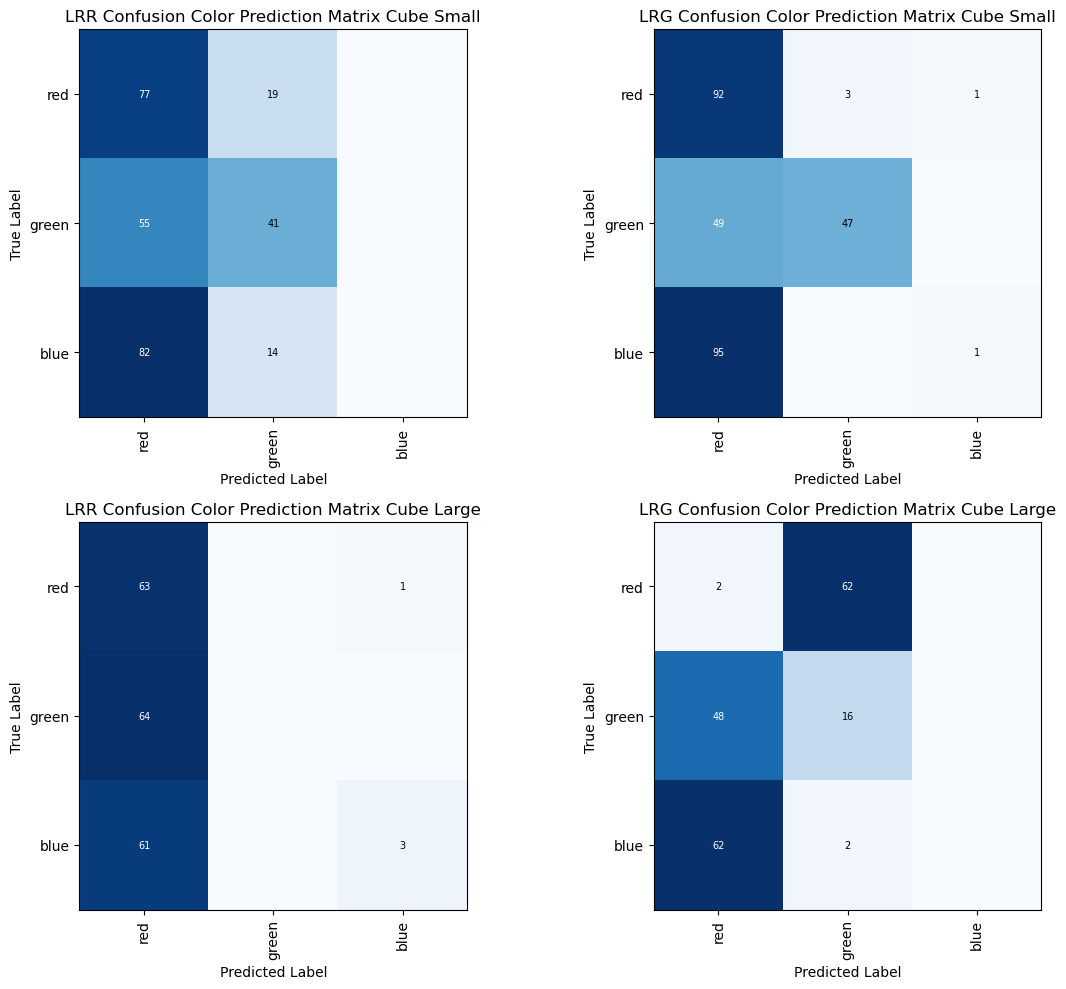

In [15]:
y_pred_reach_cube_small=lr_reach_cube_small.predict(X_test_cube_small)
y_pred_grab_cube_small=lr_grab_cube_small.predict(X_test_cube_small)

y_pred_reach_cube_large=lr_reach_cube_large.predict(X_test_cube_large)
y_pred_grab_cube_large=lr_grab_cube_large.predict(X_test_cube_large)


cm1 = confusion_matrix(y_test_cube_small, y_pred_reach_cube_small, labels=["red", "green", "blue"])
cm2 = confusion_matrix(y_test_cube_small, y_pred_grab_cube_small, labels=["red", "green", "blue"])

cm3 = confusion_matrix(y_test_cube_large, y_pred_reach_cube_large, labels=["red", "green", "blue"])
cm4 = confusion_matrix(y_test_cube_large, y_pred_grab_cube_large, labels=["red", "green", "blue"])

confusion_matrices=[cm1, cm2, cm3, cm4]
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax_counter1=0
ax_counter2=0

for i in range(len(confusion_matrices)):
    if (i % 2==0) and (i != 0):
        ax_counter1+=1
        ax_counter2=0

    ax[ax_counter1][ax_counter2].imshow(confusion_matrices[i], cmap=plt.cm.Blues, vmin=0, vmax=confusion_matrices[i].max())
    for r in range(confusion_matrices[i].shape[0]):
        for c in range(confusion_matrices[i].shape[1]):
            value = confusion_matrices[i][r, c]
            if value > 0:  # skip empty cells
                # decide text color depending on background intensity
                color = "white" if value > confusion_matrices[i].max()/2 else "black"
                ax[ax_counter1][ax_counter2].text(c, r, str(value),
                                                  ha="center", va="center",
                                                  color=color, fontsize=7)

    
    ax[ax_counter1][ax_counter2].set_xticks(np.arange(len(classes)))
    ax[ax_counter1][ax_counter2].set_xticklabels(classes, rotation=90)
    ax[ax_counter1][ax_counter2].set_yticks(np.arange(len(classes)))
    ax[ax_counter1][ax_counter2].set_yticklabels(classes)
    ax[ax_counter1][ax_counter2].set_xlabel("Predicted Label")
    ax[ax_counter1][ax_counter2].set_ylabel("True Label")

    if i==0:
        ax[ax_counter1][ax_counter2].set_title("LRR Confusion Color Prediction Matrix Cube Small")
    if i==1:
        ax[ax_counter1][ax_counter2].set_title("LRG Confusion Color Prediction Matrix Cube Small")
    if i==2:
        ax[ax_counter1][ax_counter2].set_title("LRR Confusion Color Prediction Matrix Cube Large")
    if i==3:
        ax[ax_counter1][ax_counter2].set_title("LRG Confusion Color Prediction Matrix Cube Large")
    
    ax_counter2+=1

plt.tight_layout()
plt.show()
    

In [63]:
#Capsule
#Small

random_seeds=[5, 9, 11, 42, 50]
all_predictions_reach_capsule_small=[]
all_predictions_grab_capsule_small=[]

all_predictions_reach_capsule_large=[]
all_predictions_grab_capsule_large=[]

for rs in random_seeds:
    np.random.seed(rs)
    random.seed(rs)
    all_training_reach_capsule_small=[reaching_capsule_train_small_red,reaching_capsule_train_small_green,reaching_capsule_train_small_blue]
    all_testing_reach_capsule_small=[reaching_capsule_test_small_red,reaching_capsule_test_small_green,reaching_capsule_test_small_blue]
    all_training_grab_capsule_small=[grabbing_capsule_train_small_red,grabbing_capsule_train_small_green,grabbing_capsule_train_small_blue]
    all_testing_grab_capsule_small=[grabbing_capsule_test_small_red,grabbing_capsule_test_small_green,grabbing_capsule_test_small_blue]
    new_capsule_small_training_set_reach, new_capsule_small_training_set_grab, new_lengths_capsule_small=assimilate_reach_grab_full(all_training_reach_capsule_small, all_training_grab_capsule_small)
    
    y_train_reach_capsule_small=np.array([label for idx in range(len(all_training_reach_capsule_small)) for label in [classes[idx]] * new_lengths_capsule_small[idx]])
    y_train_grab_capsule_small=np.array([label for idx in range(len(all_training_grab_capsule_small)) for label in [classes[idx]] * new_lengths_capsule_small[idx]])
    
    y_test_reach_capsule_small=np.array([label for idx, x in enumerate(all_testing_reach_capsule_small) for label in [classes[idx]] * len(x)])
    y_test_grab_capsule_small=np.array([label for idx, x in enumerate(all_testing_grab_capsule_small) for label in [classes[idx]] * len(x)])
    
    X_test_capsule_small, y_test_capsule_small=create_test_set(y_test_reach_capsule_small, y_test_grab_capsule_small, all_testing_reach_capsule_small, all_testing_grab_capsule_small, classes)
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach_capsule_small, y_train_reach_capsule_small = shuffle(new_capsule_small_training_set_reach, y_train_reach_capsule_small, random_state=rs)
    X_train_grab_capsule_small, y_train_grab_capsule_small = shuffle(new_capsule_small_training_set_grab, y_train_grab_capsule_small, random_state=rs)
    
    
    #Large
    all_training_reach_capsule_large=[reaching_capsule_train_large_red,reaching_capsule_train_large_green,reaching_capsule_train_large_blue]
    all_testing_reach_capsule_large=[reaching_capsule_test_large_red,reaching_capsule_test_large_green,reaching_capsule_test_large_blue]
    all_training_grab_capsule_large=[grabbing_capsule_train_large_red,grabbing_capsule_train_large_green,grabbing_capsule_train_large_blue]
    all_testing_grab_capsule_large=[grabbing_capsule_test_large_red,grabbing_capsule_test_large_green,grabbing_capsule_test_large_blue]
    new_capsule_large_training_set_reach, new_capsule_large_training_set_grab, new_lengths_capsule_large=assimilate_reach_grab_full(all_training_reach_capsule_large, all_training_grab_capsule_large)
    
    y_train_reach_capsule_large=np.array([label for idx in range(len(all_training_reach_capsule_large)) for label in [classes[idx]] * new_lengths_capsule_large[idx]])
    y_train_grab_capsule_large=np.array([label for idx in range(len(all_training_grab_capsule_large)) for label in [classes[idx]] * new_lengths_capsule_large[idx]])
    
    y_test_reach_capsule_large=np.array([label for idx, x in enumerate(all_testing_reach_capsule_large) for label in [classes[idx]] * len(x)])
    y_test_grab_capsule_large=np.array([label for idx, x in enumerate(all_testing_grab_capsule_large) for label in [classes[idx]] * len(x)])
    
    X_test_capsule_large, y_test_capsule_large=create_test_set(y_test_reach_capsule_large, y_test_grab_capsule_large, all_testing_reach_capsule_large, all_testing_grab_capsule_large, classes)
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach_capsule_large, y_train_reach_capsule_large = shuffle(new_capsule_large_training_set_reach, y_train_reach_capsule_large, random_state=rs)
    X_train_grab_capsule_large, y_train_grab_capsule_large = shuffle(new_capsule_large_training_set_grab, y_train_grab_capsule_large, random_state=rs)
    
    
    lr_reach_capsule_small, lr_grab_capsule_small, pred_reach_capsule_small, pred_grab_capsule_small=train_lr(X_train_reach_capsule_small, X_train_grab_capsule_small, y_train_reach_capsule_small, y_train_grab_capsule_small, X_test_capsule_small, y_test_capsule_small, limit=4000, random_seed=rs)
    lr_reach_capsule_large, lr_grab_capsule_large, pred_reach_capsule_large, pred_grab_capsule_large=train_lr(X_train_reach_capsule_large, X_train_grab_capsule_large, y_train_reach_capsule_large, y_train_grab_capsule_large, X_test_capsule_large, y_test_capsule_large, limit=4000, random_seed=rs)

    all_predictions_reach_capsule_small.append(pred_reach_capsule_small)
    all_predictions_grab_capsule_small.append(pred_grab_capsule_small)
    
    all_predictions_reach_capsule_large.append(pred_reach_capsule_large)
    all_predictions_grab_capsule_large.append(pred_grab_capsule_large)

Number per class in testing reach:  {'red': 32, 'green': 32, 'blue': 32}
Number per class in testing grab:  {'red': 48, 'green': 16, 'blue': 16}
Global minimal timesteps per class:  16
Number per class in testing reach:  {'red': 32, 'green': 32, 'blue': 48}
Number per class in testing grab:  {'red': 48, 'green': 16, 'blue': 48}
Global minimal timesteps per class:  16
Accuracy reach:  0.2708333333333333
Accuracy grab:  0.375
96


C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy reach:  0.2916666666666667
Accuracy grab:  0.3541666666666667
96
Number per class in testing reach:  {'red': 32, 'green': 32, 'blue': 32}
Number per class in testing grab:  {'red': 48, 'green': 16, 'blue': 16}
Global minimal timesteps per class:  16
Number per class in testing reach:  {'red': 32, 'green': 32, 'blue': 48}
Number per class in testing grab:  {'red': 48, 'green': 16, 'blue': 48}
Global minimal timesteps per class:  16
Accuracy reach:  0.3541666666666667
Accuracy grab:  0.46875
96


C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy reach:  0.28125
Accuracy grab:  0.3229166666666667
96
Number per class in testing reach:  {'red': 32, 'green': 32, 'blue': 32}
Number per class in testing grab:  {'red': 48, 'green': 16, 'blue': 16}
Global minimal timesteps per class:  16
Number per class in testing reach:  {'red': 32, 'green': 32, 'blue': 48}
Number per class in testing grab:  {'red': 48, 'green': 16, 'blue': 48}
Global minimal timesteps per class:  16
Accuracy reach:  0.375
Accuracy grab:  0.4791666666666667
96


...

C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy reach:  0.28125
Accuracy grab:  0.4583333333333333
96


C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy reach:  0.3020833333333333
Accuracy grab:  0.3541666666666667
96


C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [64]:
print("Capsule Small Reach")
calculate_mean_results_random_seeds(y_test_capsule_small, all_predictions_reach_capsule_small)
print("-----------------")
print("Capsule Small Grab")
calculate_mean_results_random_seeds(y_test_capsule_small, all_predictions_grab_capsule_small)
print("-----------------")
print("Capsule Large Reach")
calculate_mean_results_random_seeds(y_test_capsule_large, all_predictions_reach_capsule_large)
print("-----------------")
print("Capsule Large Grab")
calculate_mean_results_random_seeds(y_test_capsule_large, all_predictions_grab_capsule_large)

Capsule Small Reach
Full Metric:  [0.27083333 0.35416667 0.375      0.26041667 0.28125   ]
Accuracy: mean=0.3083, std=0.0524, var=0.0027
Full Metric:  [0.24579878 0.33092928 0.343402   0.24757975 0.25088447]
F1: mean=0.2837, std=0.0490, var=0.0024
Full Metric:  [0.24374237 0.33666667 0.34347154 0.24327731 0.23714896]
Precision: mean=0.2809, std=0.0542, var=0.0029
Full Metric:  [0.27083333 0.35416667 0.375      0.26041667 0.28125   ]
Recall: mean=0.3083, std=0.0524, var=0.0027
-----------------
Capsule Small Grab
Full Metric:  [0.375      0.46875    0.47916667 0.44791667 0.45833333]
Accuracy: mean=0.4458, std=0.0413, var=0.0017
Full Metric:  [0.36687895 0.46825232 0.47744963 0.44588638 0.45263982]
F1: mean=0.4422, std=0.0439, var=0.0019
Full Metric:  [0.37647843 0.47434022 0.481941   0.45042735 0.45384615]
Precision: mean=0.4474, std=0.0418, var=0.0017
Full Metric:  [0.375      0.46875    0.47916667 0.44791667 0.45833333]
Recall: mean=0.4458, std=0.0413, var=0.0017
-----------------
Cap

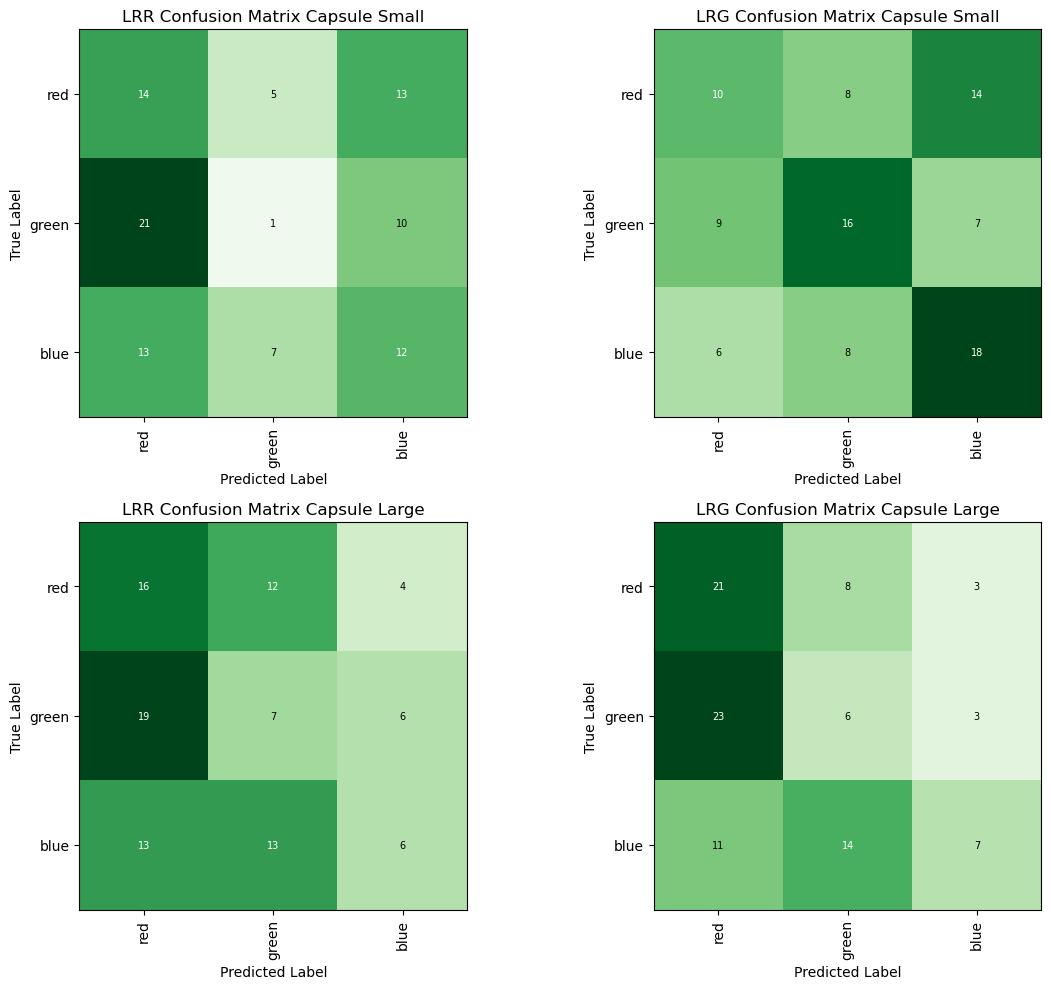

In [65]:
y_pred_reach_capsule_small=lr_reach_capsule_small.predict(X_test_capsule_small)
y_pred_grab_capsule_small=lr_grab_capsule_small.predict(X_test_capsule_small)

y_pred_reach_capsule_large=lr_reach_capsule_large.predict(X_test_capsule_large)
y_pred_grab_capsule_large=lr_grab_capsule_large.predict(X_test_capsule_large)


cm1 = confusion_matrix(y_test_capsule_small, y_pred_reach_capsule_small, labels=["red", "green", "blue"])
cm2 = confusion_matrix(y_test_capsule_small, y_pred_grab_capsule_small, labels=["red", "green", "blue"])

cm3 = confusion_matrix(y_test_capsule_large, y_pred_reach_capsule_large, labels=["red", "green", "blue"])
cm4 = confusion_matrix(y_test_capsule_large, y_pred_grab_capsule_large, labels=["red", "green", "blue"])

confusion_matrices=[cm1, cm2, cm3, cm4]
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax_counter1=0
ax_counter2=0

for i in range(len(confusion_matrices)):
    if (i % 2==0) and (i != 0):
        ax_counter1+=1
        ax_counter2=0

    ax[ax_counter1][ax_counter2].imshow(confusion_matrices[i], cmap=plt.cm.Greens, vmin=0, vmax=confusion_matrices[i].max())
    for r in range(confusion_matrices[i].shape[0]):
        for c in range(confusion_matrices[i].shape[1]):
            value = confusion_matrices[i][r, c]
            if value > 0:  # skip empty cells
                # decide text color depending on background intensity
                color = "white" if value > confusion_matrices[i].max()/2 else "black"
                ax[ax_counter1][ax_counter2].text(c, r, str(value),
                                                  ha="center", va="center",
                                                  color=color, fontsize=7)
    ax[ax_counter1][ax_counter2].set_xticks(np.arange(len(classes)))
    ax[ax_counter1][ax_counter2].set_xticklabels(classes, rotation=90)
    ax[ax_counter1][ax_counter2].set_yticks(np.arange(len(classes)))
    ax[ax_counter1][ax_counter2].set_yticklabels(classes)
    ax[ax_counter1][ax_counter2].set_xlabel("Predicted Label")
    ax[ax_counter1][ax_counter2].set_ylabel("True Label")

    if i==0:
        ax[ax_counter1][ax_counter2].set_title("LRR Confusion Matrix Capsule Small")
    if i==1:
        ax[ax_counter1][ax_counter2].set_title("LRG Confusion Matrix Capsule Small")
    if i==2:
        ax[ax_counter1][ax_counter2].set_title("LRR Confusion Matrix Capsule Large")
    if i==3:
        ax[ax_counter1][ax_counter2].set_title("LRG Confusion Matrix Capsule Large")
    
    ax_counter2+=1

plt.tight_layout()
plt.show()

In [66]:
#Ball
#Small

random_seeds=[5, 9, 11, 42, 50]
all_predictions_reach_ball_small=[]
all_predictions_grab_ball_small=[]

all_predictions_reach_ball_large=[]
all_predictions_grab_ball_large=[]


for rs in random_seeds:
    np.random.seed(rs)
    random.seed(rs)


    all_training_reach_ball_small=[reaching_ball_train_small_red,reaching_ball_train_small_green,reaching_ball_train_small_blue]
    all_testing_reach_ball_small=[reaching_ball_test_small_red,reaching_ball_test_small_green,reaching_ball_test_small_blue]
    all_training_grab_ball_small=[grabbing_ball_train_small_red,grabbing_ball_train_small_green,grabbing_ball_train_small_blue]
    all_testing_grab_ball_small=[grabbing_ball_test_small_red,grabbing_ball_test_small_green,grabbing_ball_test_small_blue]
    new_ball_small_training_set_reach, new_ball_small_training_set_grab, new_lengths_ball_small=assimilate_reach_grab_full(all_training_reach_ball_small, all_training_grab_ball_small)
    
    y_train_reach_ball_small=np.array([label for idx in range(len(all_training_reach_ball_small)) for label in [classes[idx]] * new_lengths_ball_small[idx]])
    y_train_grab_ball_small=np.array([label for idx in range(len(all_training_grab_ball_small)) for label in [classes[idx]] * new_lengths_ball_small[idx]])
    
    y_test_reach_ball_small=np.array([label for idx, x in enumerate(all_testing_reach_ball_small) for label in [classes[idx]] * len(x)])
    y_test_grab_ball_small=np.array([label for idx, x in enumerate(all_testing_grab_ball_small) for label in [classes[idx]] * len(x)])
    
    X_test_ball_small, y_test_ball_small=create_test_set(y_test_reach_ball_small, y_test_grab_ball_small, all_testing_reach_ball_small, all_testing_grab_ball_small, classes)
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach_ball_small, y_train_reach_ball_small = shuffle(new_ball_small_training_set_reach, y_train_reach_ball_small, random_state=rs)
    X_train_grab_ball_small, y_train_grab_ball_small = shuffle(new_ball_small_training_set_grab, y_train_grab_ball_small, random_state=rs)
    
    
    #Large
    all_training_reach_ball_large=[reaching_ball_train_large_red,reaching_ball_train_large_green,reaching_ball_train_large_blue]
    all_testing_reach_ball_large=[reaching_ball_test_large_red,reaching_ball_test_large_green,reaching_ball_test_large_blue]
    all_training_grab_ball_large=[grabbing_ball_train_large_red,grabbing_ball_train_large_green,grabbing_ball_train_large_blue]
    all_testing_grab_ball_large=[grabbing_ball_test_large_red,grabbing_ball_test_large_green,grabbing_ball_test_large_blue]
    new_ball_large_training_set_reach, new_ball_large_training_set_grab, new_lengths_ball_large=assimilate_reach_grab_full(all_training_reach_ball_large, all_training_grab_ball_large)
    
    y_train_reach_ball_large=np.array([label for idx in range(len(all_training_reach_ball_large)) for label in [classes[idx]] * new_lengths_ball_large[idx]])
    y_train_grab_ball_large=np.array([label for idx in range(len(all_training_grab_ball_large)) for label in [classes[idx]] * new_lengths_ball_large[idx]])
    
    y_test_reach_ball_large=np.array([label for idx, x in enumerate(all_testing_reach_ball_large) for label in [classes[idx]] * len(x)])
    y_test_grab_ball_large=np.array([label for idx, x in enumerate(all_testing_grab_ball_large) for label in [classes[idx]] * len(x)])
    
    X_test_ball_large, y_test_ball_large=create_test_set(y_test_reach_ball_large, y_test_grab_ball_large, all_testing_reach_ball_large, all_testing_grab_ball_large, classes)
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach_ball_large, y_train_reach_ball_large = shuffle(new_ball_large_training_set_reach, y_train_reach_ball_large, random_state=rs)
    X_train_grab_ball_large, y_train_grab_ball_large = shuffle(new_ball_large_training_set_grab, y_train_grab_ball_large, random_state=rs)
    
    
    lr_reach_ball_small, lr_grab_ball_small, pred_reach_ball_small, pred_grab_ball_small=train_lr(X_train_reach_ball_small, X_train_grab_ball_small, y_train_reach_ball_small, y_train_grab_ball_small, X_test_ball_small, y_test_ball_small, limit=4000, random_seed=rs)
    lr_reach_ball_large, lr_grab_ball_large, pred_reach_ball_large, pred_grab_ball_large=train_lr(X_train_reach_ball_large, X_train_grab_ball_large, y_train_reach_ball_large, y_train_grab_ball_large, X_test_ball_large, y_test_ball_large, limit=4000, random_seed=rs)

    all_predictions_reach_ball_small.append(pred_reach_ball_small)
    all_predictions_grab_ball_small.append(pred_grab_ball_small)
    
    all_predictions_reach_ball_large.append(pred_reach_ball_large)
    all_predictions_grab_ball_large.append(pred_grab_ball_large)



Number per class in testing reach:  {'red': 96, 'green': 96, 'blue': 80}
Number per class in testing grab:  {'red': 112, 'green': 96, 'blue': 80}
Global minimal timesteps per class:  80
Number per class in testing reach:  {'red': 80, 'green': 48, 'blue': 80}
Number per class in testing grab:  {'red': 96, 'green': 64, 'blue': 32}
Global minimal timesteps per class:  32


C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy reach:  0.3458333333333333
Accuracy grab:  0.34375
480


C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy reach:  0.3177083333333333
Accuracy grab:  0.34375
192
Number per class in testing reach:  {'red': 96, 'green': 96, 'blue': 80}
Number per class in testing grab:  {'red': 112, 'green': 96, 'blue': 80}
Global minimal timesteps per class:  80
Number per class in testing reach:  {'red': 80, 'green': 48, 'blue': 80}
Number per class in testing grab:  {'red': 96, 'green': 64, 'blue': 32}
Global minimal timesteps per class:  32


...

C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy reach:  0.34791666666666665
Accuracy grab:  0.35208333333333336
480


C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy reach:  0.28125
Accuracy grab:  0.3229166666666667
192


C:\Users\kulma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [67]:
print("Ball Small Reach")
calculate_mean_results_random_seeds(y_test_ball_small, all_predictions_reach_ball_small)
print("-----------------")
print("Ball Small Grab")
calculate_mean_results_random_seeds(y_test_ball_small, all_predictions_grab_ball_small)
print("-----------------")
print("Ball Large Reach")
calculate_mean_results_random_seeds(y_test_ball_large, all_predictions_reach_ball_large)
print("-----------------")
print("Ball Large Grab")
calculate_mean_results_random_seeds(y_test_ball_large, all_predictions_grab_ball_large)


Ball Small Reach
Full Metric:  [0.34583333 0.33958333 0.36666667 0.35416667 0.34791667]
Accuracy: mean=0.3508, std=0.0103, var=0.0001
Full Metric:  [0.34244311 0.33437384 0.36420602 0.34883507 0.34462821]
F1: mean=0.3469, std=0.0110, var=0.0001
Full Metric:  [0.34603327 0.33548655 0.36512091 0.34893785 0.34913367]
Precision: mean=0.3489, std=0.0106, var=0.0001
Full Metric:  [0.34583333 0.33958333 0.36666667 0.35416667 0.34791667]
Recall: mean=0.3508, std=0.0103, var=0.0001
-----------------
Ball Small Grab
Full Metric:  [0.34375    0.35416667 0.34791667 0.34791667 0.35208333]
Accuracy: mean=0.3492, std=0.0041, var=0.0000
Full Metric:  [0.33678352 0.35044431 0.34075419 0.34529332 0.34762449]
F1: mean=0.3442, std=0.0054, var=0.0000
Full Metric:  [0.3405579  0.35513316 0.34661293 0.34995697 0.35263824]
Precision: mean=0.3490, std=0.0057, var=0.0000
Full Metric:  [0.34375    0.35416667 0.34791667 0.34791667 0.35208333]
Recall: mean=0.3492, std=0.0041, var=0.0000
-----------------
Ball Larg

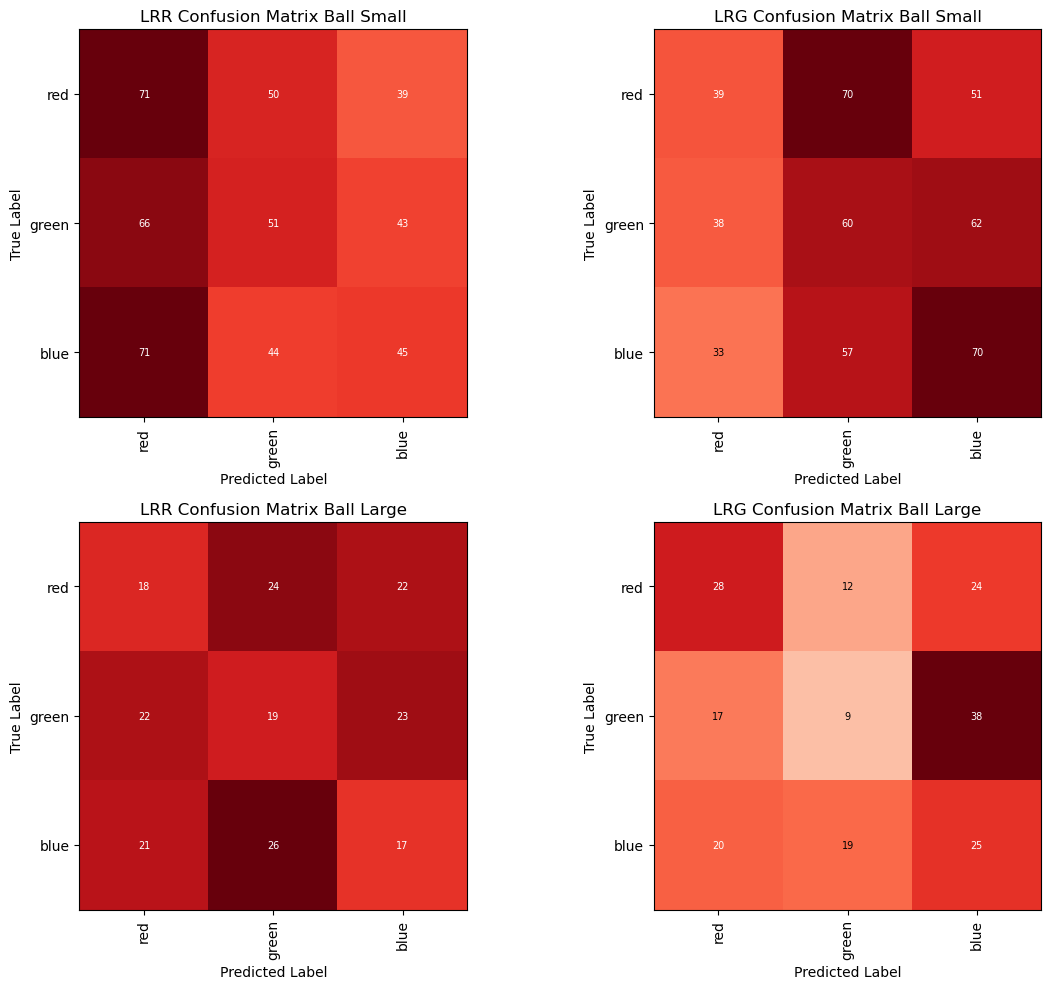

In [68]:
y_pred_reach_ball_small=lr_reach_ball_small.predict(X_test_ball_small)
y_pred_grab_ball_small=lr_grab_ball_small.predict(X_test_ball_small)

y_pred_reach_ball_large=lr_reach_ball_large.predict(X_test_ball_large)
y_pred_grab_ball_large=lr_grab_ball_large.predict(X_test_ball_large)


cm1 = confusion_matrix(y_test_ball_small, y_pred_reach_ball_small, labels=["red", "green", "blue"])
cm2 = confusion_matrix(y_test_ball_small, y_pred_grab_ball_small, labels=["red", "green", "blue"])

cm3 = confusion_matrix(y_test_ball_large, y_pred_reach_ball_large, labels=["red", "green", "blue"])
cm4 = confusion_matrix(y_test_ball_large, y_pred_grab_ball_large, labels=["red", "green", "blue"])

confusion_matrices=[cm1, cm2, cm3, cm4]
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax_counter1=0
ax_counter2=0

for i in range(len(confusion_matrices)):
    if (i % 2==0) and (i != 0):
        ax_counter1+=1
        ax_counter2=0

    ax[ax_counter1][ax_counter2].imshow(confusion_matrices[i], cmap=plt.cm.Reds, vmin=0, vmax=confusion_matrices[i].max())
    for r in range(confusion_matrices[i].shape[0]):
        for c in range(confusion_matrices[i].shape[1]):
            value = confusion_matrices[i][r, c]
            if value > 0:  # skip empty cells
                # decide text color depending on background intensity
                color = "white" if value > confusion_matrices[i].max()/2 else "black"
                ax[ax_counter1][ax_counter2].text(c, r, str(value),
                                                  ha="center", va="center",
                                                  color=color, fontsize=7)
    ax[ax_counter1][ax_counter2].set_xticks(np.arange(len(classes)))
    ax[ax_counter1][ax_counter2].set_xticklabels(classes, rotation=90)
    ax[ax_counter1][ax_counter2].set_yticks(np.arange(len(classes)))
    ax[ax_counter1][ax_counter2].set_yticklabels(classes)
    ax[ax_counter1][ax_counter2].set_xlabel("Predicted Label")
    ax[ax_counter1][ax_counter2].set_ylabel("True Label")

    if i==0:
        ax[ax_counter1][ax_counter2].set_title("LRR Confusion Matrix Ball Small")
    if i==1:
        ax[ax_counter1][ax_counter2].set_title("LRG Confusion Matrix Ball Small")
    if i==2:
        ax[ax_counter1][ax_counter2].set_title("LRR Confusion Matrix Ball Large")
    if i==3:
        ax[ax_counter1][ax_counter2].set_title("LRG Confusion Matrix Ball Large")
    
    ax_counter2+=1

plt.tight_layout()
plt.show()

## Shape
Next I analyze the shape. Since, as the above analysis shows, the color is not well encoded, I use all three colorways per object and discretize by size

In [8]:
#New classes
classes=["cube",  "capsule", "ball"]

#Small
all_training_reach_shapes_small=[reaching_cube_train_small_red+reaching_cube_train_small_green+reaching_cube_train_small_blue,
                                    reaching_capsule_train_small_red+reaching_capsule_train_small_green+reaching_capsule_train_small_blue,
                                    reaching_ball_train_small_red+reaching_ball_train_small_green+reaching_ball_train_small_blue]

all_testing_reach_shapes_small=[reaching_cube_test_small_red+reaching_cube_test_small_green+reaching_cube_test_small_blue,
                                            reaching_capsule_test_small_red+reaching_capsule_test_small_green+reaching_capsule_test_small_blue,
                                            reaching_ball_test_small_red+reaching_ball_test_small_green+reaching_ball_test_small_blue]


all_training_grab_shapes_small=[grabbing_cube_train_small_red+grabbing_cube_train_small_green+grabbing_cube_train_small_blue,
                                            grabbing_capsule_train_small_red+grabbing_capsule_train_small_green+grabbing_capsule_train_small_blue,
                                            grabbing_ball_train_small_red+grabbing_ball_train_small_green+grabbing_ball_train_small_blue]


all_testing_grab_shapes_small=[grabbing_cube_test_small_red+grabbing_cube_test_small_green+grabbing_cube_test_small_blue,
                                            grabbing_capsule_test_small_red+grabbing_capsule_test_small_green+grabbing_capsule_test_small_blue,
                                            grabbing_ball_test_small_red+grabbing_ball_test_small_green+grabbing_ball_test_small_blue]

random_seeds=[5, 9, 11, 42, 50]

all_predictions_reach_shapes_small=[]
all_predictions_grab_shapes_small=[]

all_predictions_reach_shapes_large=[]
all_predictions_grab_shapes_large=[]


for rs in random_seeds:
    np.random.seed(rs)
    random.seed(rs)
    new_shapes_small_training_set_reach, new_shapes_small_training_set_grab, new_lengths_shapes_small=assimilate_reach_grab_full(all_training_reach_shapes_small, all_training_grab_shapes_small)
    
    
    y_train_reach_shapes_small=np.array([label for idx in range(len(all_training_reach_shapes_small)) for label in [classes[idx]] * new_lengths_shapes_small[idx]])
    y_train_grab_shapes_small=np.array([label for idx in range(len(all_training_grab_shapes_small)) for label in [classes[idx]] * new_lengths_shapes_small[idx]])
    
    y_test_reach_shapes_small=np.array([label for idx, x in enumerate(all_testing_reach_shapes_small) for label in [classes[idx]] * len(x)])
    y_test_grab_shapes_small=np.array([label for idx, x in enumerate(all_testing_grab_shapes_small) for label in [classes[idx]] * len(x)])
    
    X_test_shapes_small, y_test_shapes_small=create_test_set(y_test_reach_shapes_small, y_test_grab_shapes_small, all_testing_reach_shapes_small, all_testing_grab_shapes_small, classes)
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach_shapes_small, y_train_reach_shapes_small = shuffle(new_shapes_small_training_set_reach, y_train_reach_shapes_small, random_state=rs)
    X_train_grab_shapes_small, y_train_grab_shapes_small = shuffle(new_shapes_small_training_set_grab, y_train_grab_shapes_small, random_state=rs)

    lr_reach_shapes_small, lr_grab_shapes_small, pred_reach_shapes_small, pred_grab_shapes_small=train_lr(X_train_reach_shapes_small, X_train_grab_shapes_small, y_train_reach_shapes_small, y_train_grab_shapes_small, X_test_shapes_small, y_test_shapes_small, limit=4000, random_seed=rs)
    all_predictions_reach_shapes_small.append(pred_reach_shapes_small)
    all_predictions_grab_shapes_small.append(pred_grab_shapes_small)



#Large
all_training_reach_shapes_large=[reaching_cube_train_large_red+reaching_cube_train_large_green+reaching_cube_train_large_blue,
                                    reaching_capsule_train_large_red+reaching_capsule_train_large_green+reaching_capsule_train_large_blue,
                                    reaching_ball_train_large_red+reaching_ball_train_large_green+reaching_ball_train_large_blue]

all_testing_reach_shapes_large=[reaching_cube_test_large_red+reaching_cube_test_large_green+reaching_cube_test_large_blue,
                                            reaching_capsule_test_large_red+reaching_capsule_test_large_green+reaching_capsule_test_large_blue,
                                            reaching_ball_test_large_red+reaching_ball_test_large_green+reaching_ball_test_large_blue]


all_training_grab_shapes_large=[grabbing_cube_train_large_red+grabbing_cube_train_large_green+grabbing_cube_train_large_blue,
                                            grabbing_capsule_train_large_red+grabbing_capsule_train_large_green+grabbing_capsule_train_large_blue,
                                            grabbing_ball_train_large_red+grabbing_ball_train_large_green+grabbing_ball_train_large_blue]


all_testing_grab_shapes_large=[grabbing_cube_test_large_red+grabbing_cube_test_large_green+grabbing_cube_test_large_blue,
                                            grabbing_capsule_test_large_red+grabbing_capsule_test_large_green+grabbing_capsule_test_large_blue,
                                            grabbing_ball_test_large_red+grabbing_ball_test_large_green+grabbing_ball_test_large_blue]

for rs in random_seeds:
    np.random.seed(rs)
    random.seed(rs)
    new_shapes_large_training_set_reach, new_shapes_large_training_set_grab, new_lengths_shapes_large=assimilate_reach_grab_full(all_training_reach_shapes_large, all_training_grab_shapes_large)
    
    
    y_train_reach_shapes_large=np.array([label for idx in range(len(all_training_reach_shapes_large)) for label in [classes[idx]] * new_lengths_shapes_large[idx]])
    y_train_grab_shapes_large=np.array([label for idx in range(len(all_training_grab_shapes_large)) for label in [classes[idx]] * new_lengths_shapes_large[idx]])
    
    y_test_reach_shapes_large=np.array([label for idx, x in enumerate(all_testing_reach_shapes_large) for label in [classes[idx]] * len(x)])
    y_test_grab_shapes_large=np.array([label for idx, x in enumerate(all_testing_grab_shapes_large) for label in [classes[idx]] * len(x)])
    
    X_test_shapes_large, y_test_shapes_large=create_test_set(y_test_reach_shapes_large, y_test_grab_shapes_large, all_testing_reach_shapes_large, all_testing_grab_shapes_large, classes)
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach_shapes_large, y_train_reach_shapes_large = shuffle(new_shapes_large_training_set_reach, y_train_reach_shapes_large, random_state=rs)
    X_train_grab_shapes_large, y_train_grab_shapes_large = shuffle(new_shapes_large_training_set_grab, y_train_grab_shapes_large, random_state=rs)
    
    
    lr_reach_shapes_large, lr_grab_shapes_large, pred_reach_shapes_large, pred_grab_shapes_large=train_lr(X_train_reach_shapes_large, X_train_grab_shapes_large, y_train_reach_shapes_large, y_train_grab_shapes_large, X_test_shapes_large, y_test_shapes_large, limit=4000, random_seed=rs)
    all_predictions_reach_shapes_large.append(pred_reach_shapes_large)
    all_predictions_grab_shapes_large.append(pred_grab_shapes_large)

Number per class in testing reach:  {'cube': 224, 'capsule': 96, 'ball': 272}
Number per class in testing grab:  {'cube': 304, 'capsule': 80, 'ball': 288}
Global minimal timesteps per class:  80
Accuracy reach:  1.0
Accuracy grab:  0.9791666666666666
480
Number per class in testing reach:  {'cube': 224, 'capsule': 96, 'ball': 272}
Number per class in testing grab:  {'cube': 304, 'capsule': 80, 'ball': 288}
Global minimal timesteps per class:  80
Accuracy reach:  1.0
Accuracy grab:  0.98125
480
Number per class in testing reach:  {'cube': 224, 'capsule': 96, 'ball': 272}
Number per class in testing grab:  {'cube': 304, 'capsule': 80, 'ball': 288}
Global minimal timesteps per class:  80
Accuracy reach:  1.0
Accuracy grab:  0.9875
480
Number per class in testing reach:  {'cube': 224, 'capsule': 96, 'ball': 272}
Number per class in testing grab:  {'cube': 304, 'capsule': 80, 'ball': 288}
Global minimal timesteps per class:  80
Accuracy reach:  1.0
Accuracy grab:  0.975
480
Number per class

In [11]:
print("Shapes Small Reach")
calculate_mean_results_random_seeds(y_test_shapes_small, all_predictions_reach_shapes_small)
print("-----------------")
print("Shapes Small Grab")
calculate_mean_results_random_seeds(y_test_shapes_small, all_predictions_grab_shapes_small)
print("-----------------")
print("Shapes Large Reach")
calculate_mean_results_random_seeds(y_test_shapes_large, all_predictions_reach_shapes_large)
print("-----------------")
print("Shapes Large Grab")
calculate_mean_results_random_seeds(y_test_shapes_large, all_predictions_grab_shapes_large)


Shapes Small Reach
Full Metric:  [1. 1. 1. 1. 1.]
Accuracy: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
F1: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
Precision: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
Recall: mean=1.0000, std=0.0000, var=0.0000
-----------------
Shapes Small Grab
Full Metric:  [0.97916667 0.98125    0.9875     0.975      0.98541667]
Accuracy: mean=0.9817, std=0.0050, var=0.0000
Full Metric:  [0.97904684 0.98118519 0.9874956  0.97489702 0.98540968]
F1: mean=0.9816, std=0.0050, var=0.0000
Full Metric:  [0.98001176 0.98205659 0.98795181 0.97648711 0.98602794]
Precision: mean=0.9825, std=0.0046, var=0.0000
Full Metric:  [0.97916667 0.98125    0.9875     0.975      0.98541667]
Recall: mean=0.9817, std=0.0050, var=0.0000
-----------------
Shapes Large Reach
Full Metric:  [1. 1. 1. 1. 1.]
Accuracy: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
F1: mean=1.0000, std=0.0000, var=0.000

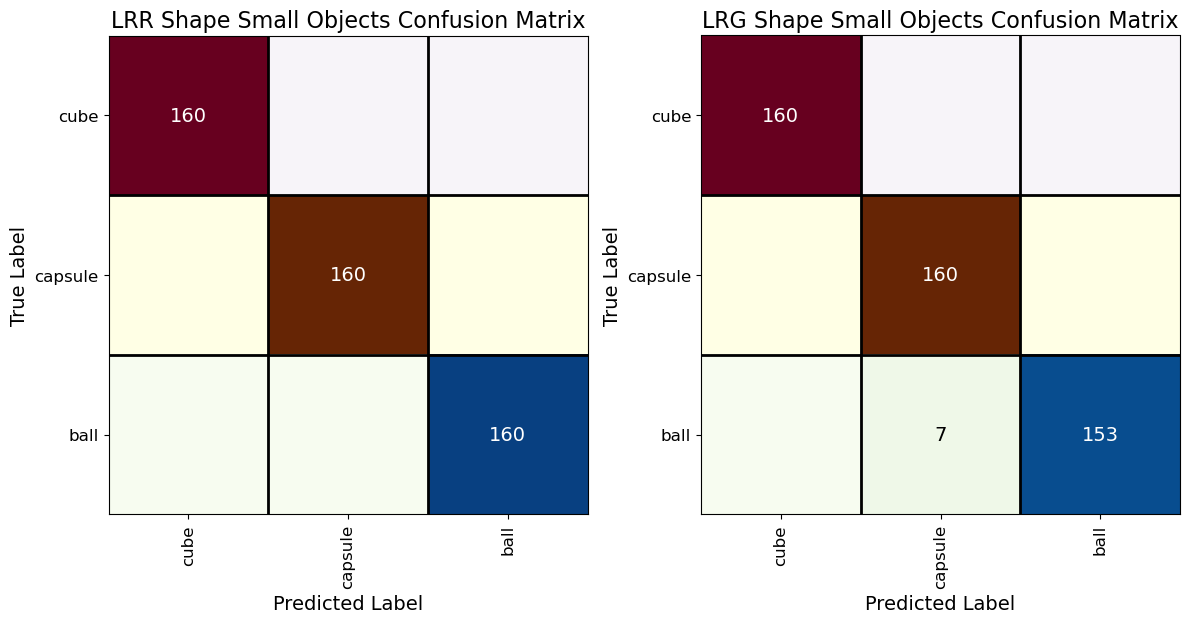

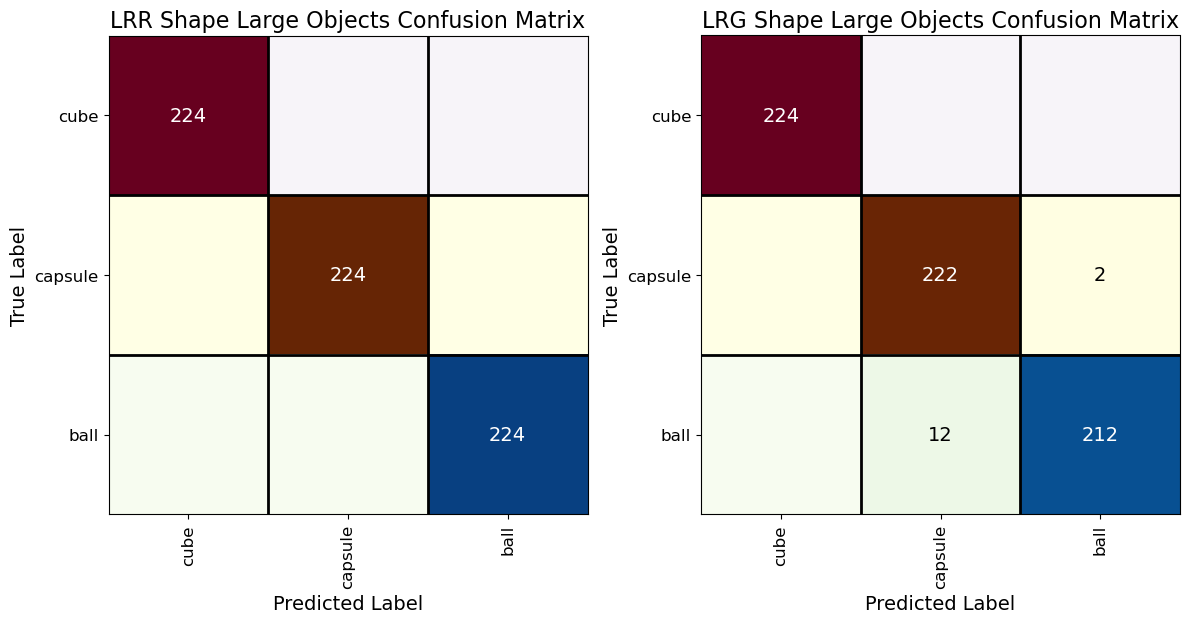

In [15]:
classes=["cube",  "capsule", "ball"]
y_pred_reach_shapes_small=lr_reach_shapes_small.predict(X_test_shapes_small)
y_pred_grab_shapes_small=lr_grab_shapes_small.predict(X_test_shapes_small)

y_pred_reach_shapes_large=lr_reach_shapes_large.predict(X_test_shapes_large)
y_pred_grab_shapes_large=lr_grab_shapes_large.predict(X_test_shapes_large)


cm1 = confusion_matrix(y_test_shapes_small, y_pred_reach_shapes_small, labels=["cube",  "capsule", "ball"])
cm2 = confusion_matrix(y_test_shapes_small, y_pred_grab_shapes_small, labels=["cube",  "capsule", "ball"])

cm3 = confusion_matrix(y_test_shapes_large, y_pred_reach_shapes_large, labels=["cube",  "capsule", "ball"])
cm4 = confusion_matrix(y_test_shapes_large, y_pred_grab_shapes_large, labels=["cube",  "capsule", "ball"])

confusion_matrices=[cm1, cm2, cm3, cm4]

make_plots(cm1, cm2, group_size=1, groups=['cube', 'capsule', 'ball'], lines=True, numbers=True, title="Shape Small Objects")
make_plots(cm3, cm4, group_size=1, groups=['cube', 'capsule', 'ball'], lines=True, numbers=True, title="Shape Large Objects")

## Size

For size I again just use each color but discretize over shapes.

In [83]:
#New classes
classes=["small", "large"]


random_seeds=[5, 9, 11, 42, 50]

all_predictions_reach_cube=[]
all_predictions_grab_cube=[]

all_predictions_reach_capsule=[]
all_predictions_grab_capsule=[]

all_predictions_reach_ball=[]
all_predictions_grab_ball=[]


for rs in random_seeds:
    np.random.seed(rs)
    random.seed(rs)
    
    #Cube
    all_training_reach_cube=[reaching_cube_train_small_red+reaching_cube_train_small_green+reaching_cube_train_small_blue,
                            reaching_cube_train_large_red+reaching_cube_train_large_green+reaching_cube_train_large_blue]
    
    all_testing_reach_cube=[reaching_cube_test_small_red+reaching_cube_test_small_green+reaching_cube_test_small_blue,
                            reaching_cube_test_large_red+reaching_cube_test_large_green+reaching_cube_test_large_blue]
    
    all_training_grab_cube=[grabbing_cube_train_small_red+grabbing_cube_train_small_green+grabbing_cube_train_small_blue,
                            grabbing_cube_train_large_red+grabbing_cube_train_large_green+grabbing_cube_train_large_blue]
    
    all_testing_grab_cube=[grabbing_cube_test_small_red+grabbing_cube_test_small_green+grabbing_cube_test_small_blue,
                            grabbing_cube_test_large_red+grabbing_cube_test_large_green+grabbing_cube_test_large_blue]
    new_cube_training_set_reach, new_cube_training_set_grab, new_lengths_cube=assimilate_reach_grab_full(all_training_reach_cube, all_training_grab_cube)
    
    
    y_train_reach_cube=np.array([label for idx in range(len(all_training_reach_cube)) for label in [classes[idx]] * new_lengths_cube[idx]])
    y_train_grab_cube=np.array([label for idx in range(len(all_training_grab_cube)) for label in [classes[idx]] * new_lengths_cube[idx]])
    
    y_test_reach_cube=np.array([label for idx, x in enumerate(all_testing_reach_cube) for label in [classes[idx]] * len(x)])
    y_test_grab_cube=np.array([label for idx, x in enumerate(all_testing_grab_cube) for label in [classes[idx]] * len(x)])
    
    X_test_cube, y_test_cube=create_test_set(y_test_reach_cube, y_test_grab_cube, all_testing_reach_cube, all_testing_grab_cube, classes)
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach_cube, y_train_reach_cube = shuffle(new_cube_training_set_reach, y_train_reach_cube, random_state=rs)
    X_train_grab_cube, y_train_grab_cube = shuffle(new_cube_training_set_grab, y_train_grab_cube, random_state=rs)

    #Capsule
    all_training_reach_capsule=[reaching_capsule_train_small_red+reaching_capsule_train_small_green+reaching_capsule_train_small_blue,
                            reaching_capsule_train_large_red+reaching_capsule_train_large_green+reaching_capsule_train_large_blue]
    
    all_testing_reach_capsule=[reaching_capsule_test_small_red+reaching_capsule_test_small_green+reaching_capsule_test_small_blue,
                            reaching_capsule_test_large_red+reaching_capsule_test_large_green+reaching_capsule_test_large_blue]
    
    all_training_grab_capsule=[grabbing_capsule_train_small_red+grabbing_capsule_train_small_green+grabbing_capsule_train_small_blue,
                            grabbing_capsule_train_large_red+grabbing_capsule_train_large_green+grabbing_capsule_train_large_blue]
    
    all_testing_grab_capsule=[grabbing_capsule_test_small_red+grabbing_capsule_test_small_green+grabbing_capsule_test_small_blue,
                            grabbing_capsule_test_large_red+grabbing_capsule_test_large_green+grabbing_capsule_test_large_blue]
    
    new_capsule_training_set_reach, new_capsule_training_set_grab, new_lengths_capsule=assimilate_reach_grab_full(all_training_reach_capsule, all_training_grab_capsule)
    
    
    y_train_reach_capsule=np.array([label for idx in range(len(all_training_reach_capsule)) for label in [classes[idx]] * new_lengths_capsule[idx]])
    y_train_grab_capsule=np.array([label for idx in range(len(all_training_grab_capsule)) for label in [classes[idx]] * new_lengths_capsule[idx]])
    
    y_test_reach_capsule=np.array([label for idx, x in enumerate(all_testing_reach_capsule) for label in [classes[idx]] * len(x)])
    y_test_grab_capsule=np.array([label for idx, x in enumerate(all_testing_grab_capsule) for label in [classes[idx]] * len(x)])
    
    X_test_capsule, y_test_capsule=create_test_set(y_test_reach_capsule, y_test_grab_capsule, all_testing_reach_capsule, all_testing_grab_capsule, classes)
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach_capsule, y_train_reach_capsule = shuffle(new_capsule_training_set_reach, y_train_reach_capsule, random_state=rs)
    X_train_grab_capsule, y_train_grab_capsule = shuffle(new_capsule_training_set_grab, y_train_grab_capsule, random_state=rs)
    
    #Ball
    all_training_reach_ball=[reaching_ball_train_small_red+reaching_ball_train_small_green+reaching_ball_train_small_blue,
                            reaching_ball_train_large_red+reaching_ball_train_large_green+reaching_ball_train_large_blue]
    
    all_testing_reach_ball=[reaching_ball_test_small_red+reaching_ball_test_small_green+reaching_ball_test_small_blue,
                            reaching_ball_test_large_red+reaching_ball_test_large_green+reaching_ball_test_large_blue]
    
    all_training_grab_ball=[grabbing_ball_train_small_red+grabbing_ball_train_small_green+grabbing_ball_train_small_blue,
                            grabbing_ball_train_large_red+grabbing_ball_train_large_green+grabbing_ball_train_large_blue]
    
    all_testing_grab_ball=[grabbing_ball_test_small_red+grabbing_ball_test_small_green+grabbing_ball_test_small_blue,
                            grabbing_ball_test_large_red+grabbing_ball_test_large_green+grabbing_ball_test_large_blue]
    
    new_ball_training_set_reach, new_ball_training_set_grab, new_lengths_ball=assimilate_reach_grab_full(all_training_reach_ball, all_training_grab_ball)
    
    
    y_train_reach_ball=np.array([label for idx in range(len(all_training_reach_ball)) for label in [classes[idx]] * new_lengths_ball[idx]])
    y_train_grab_ball=np.array([label for idx in range(len(all_training_grab_ball)) for label in [classes[idx]] * new_lengths_ball[idx]])
    
    y_test_reach_ball=np.array([label for idx, x in enumerate(all_testing_reach_ball) for label in [classes[idx]] * len(x)])
    y_test_grab_ball=np.array([label for idx, x in enumerate(all_testing_grab_ball) for label in [classes[idx]] * len(x)])
    
    X_test_ball, y_test_ball=create_test_set(y_test_reach_ball, y_test_grab_ball, all_testing_reach_ball, all_testing_grab_ball, classes)
    
    #After getting the training labels, I now want to shuffle them in the same way as the X values
    X_train_reach_ball, y_train_reach_ball = shuffle(new_ball_training_set_reach, y_train_reach_ball, random_state=rs)
    X_train_grab_ball, y_train_grab_ball = shuffle(new_ball_training_set_grab, y_train_grab_ball, random_state=rs)
    
    
    
    lr_reach_cube, lr_grab_cube, pred_reach_cube, pred_grab_cube=train_lr(X_train_reach_cube, X_train_grab_cube, y_train_reach_cube, y_train_grab_cube, X_test_cube, y_test_cube, limit=4000, random_seed=rs)
    lr_reach_capsule, lr_grab_capsule, pred_reach_capsule, pred_grab_capsule=train_lr(X_train_reach_capsule, X_train_grab_capsule, y_train_reach_capsule, y_train_grab_capsule, X_test_capsule, y_test_capsule, limit=4000, random_seed=rs)
    lr_reach_ball, lr_grab_ball, pred_reach_ball, pred_grab_ball=train_lr(X_train_reach_ball, X_train_grab_ball, y_train_reach_ball, y_train_grab_ball, X_test_ball, y_test_ball, limit=4000, random_seed=rs)
    
    all_predictions_reach_cube.append(pred_reach_cube)
    all_predictions_grab_cube.append(pred_grab_cube)
    
    all_predictions_reach_capsule.append(pred_reach_capsule)
    all_predictions_grab_capsule.append(pred_grab_capsule)
    
    all_predictions_reach_ball.append(pred_reach_ball)
    all_predictions_grab_ball.append(pred_grab_ball)


Number per class in testing reach:  {'small': 224, 'large': 176}
Number per class in testing grab:  {'small': 304, 'large': 176}
Global minimal timesteps per class:  176
Number per class in testing reach:  {'small': 96, 'large': 112}
Number per class in testing grab:  {'small': 80, 'large': 112}
Global minimal timesteps per class:  80
Number per class in testing reach:  {'small': 272, 'large': 208}
Number per class in testing grab:  {'small': 288, 'large': 192}
Global minimal timesteps per class:  192
Accuracy reach:  1.0
Accuracy grab:  1.0
704
Accuracy reach:  1.0
Accuracy grab:  0.975
320
Accuracy reach:  1.0
Accuracy grab:  0.97265625
768
Number per class in testing reach:  {'small': 224, 'large': 176}
Number per class in testing grab:  {'small': 304, 'large': 176}
Global minimal timesteps per class:  176
Number per class in testing reach:  {'small': 96, 'large': 112}
Number per class in testing grab:  {'small': 80, 'large': 112}
Global minimal timesteps per class:  80
Number per c

In [84]:
print("Cube Reach")
calculate_mean_results_random_seeds(y_test_cube, all_predictions_reach_cube)
print("-----------------")
print("Cube Grab")
calculate_mean_results_random_seeds(y_test_cube, all_predictions_grab_cube)
print("-----------------")
print("Capsule Reach")
calculate_mean_results_random_seeds(y_test_capsule, all_predictions_reach_capsule)
print("-----------------")
print("Capsule Grab")
calculate_mean_results_random_seeds(y_test_capsule, all_predictions_grab_capsule)
print("-----------------")
print("Ball Reach")
calculate_mean_results_random_seeds(y_test_ball, all_predictions_reach_ball)
print("-----------------")
print("Ball  Grab")
calculate_mean_results_random_seeds(y_test_ball, all_predictions_grab_ball)


Cube Reach
Full Metric:  [1. 1. 1. 1. 1.]
Accuracy: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
F1: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
Precision: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
Recall: mean=1.0000, std=0.0000, var=0.0000
-----------------
Cube Grab
Full Metric:  [1. 1. 1. 1. 1.]
Accuracy: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
F1: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
Precision: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
Recall: mean=1.0000, std=0.0000, var=0.0000
-----------------
Capsule Reach
Full Metric:  [1. 1. 1. 1. 1.]
Accuracy: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
F1: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
Precision: mean=1.0000, std=0.0000, var=0.0000
Full Metric:  [1. 1. 1. 1. 1.]
Recall: mean=1.0000, std=0.0000, var=0.0000
-----------------
Capsule 

In [7]:
classes=["small", "large"]
y_pred_reach_cube=lr_reach_cube.predict(X_test_cube)
y_pred_grab_cube=lr_grab_cube.predict(X_test_cube)

y_pred_reach_capsule=lr_reach_capsule.predict(X_test_capsule)
y_pred_grab_capsule=lr_grab_capsule.predict(X_test_capsule)

y_pred_reach_ball=lr_reach_ball.predict(X_test_ball)
y_pred_grab_ball=lr_grab_ball.predict(X_test_ball)


cm1 = confusion_matrix(y_test_cube, y_pred_reach_cube, labels=["small", "large"])
cm2 = confusion_matrix(y_test_cube, y_pred_grab_cube, labels=["small",  "large"])

cm3 = confusion_matrix(y_test_capsule, y_pred_reach_capsule, labels=["small", "large"])
cm4 = confusion_matrix(y_test_capsule, y_pred_grab_capsule, labels=["small",  "large"])

cm5 = confusion_matrix(y_test_ball, y_pred_reach_ball, labels=["small", "large"])
cm6 = confusion_matrix(y_test_ball, y_pred_grab_ball, labels=["small",  "large"])


confusion_matrices=[cm1, cm2, cm3, cm4, cm5, cm6]
#colors=[plt.cm.Blues, plt.cm.Blues, plt.cm.Greens, plt.cm.Greens, plt.cm.Reds, plt.cm.Reds]
colors=[plt.cm.PuRd, plt.cm.PuRd, plt.cm.YlOrBr, plt.cm.YlOrBr, plt.cm.GnBu, plt.cm.GnBu]

fig, ax = plt.subplots(3, 2, figsize=(12, 10))

ax_counter1=0
ax_counter2=0

for i in range(len(confusion_matrices)):
    if ((i % 2==0) or (i%4==0)) and (i != 0):
        ax_counter1+=1
        ax_counter2=0

    ax[ax_counter1][ax_counter2].imshow(confusion_matrices[i], cmap=colors[i], vmin=0, vmax=confusion_matrices[i].max())
    
    ax[ax_counter1][ax_counter2].set_xticks(np.arange(len(classes)))
    ax[ax_counter1][ax_counter2].set_xticklabels(classes, rotation=90)
    ax[ax_counter1][ax_counter2].set_yticks(np.arange(len(classes)))
    ax[ax_counter1][ax_counter2].set_yticklabels(classes)
    ax[ax_counter1][ax_counter2].set_xlabel("Predicted Label")
    ax[ax_counter1][ax_counter2].set_ylabel("True Label")
    
    for r in range(confusion_matrices[i].shape[0]):
        for c in range(confusion_matrices[i].shape[1]):
            value = confusion_matrices[i][r, c]
            if value > 0:  # skip empty cells
                # decide text color depending on background intensity
                color = "white" if value > confusion_matrices[i].max()/2 else "black"
                ax[ax_counter1][ax_counter2].text(c, r, str(value),
                                                  ha="center", va="center",
                                                  color=color, fontsize=7)
                
    if i==0:
        ax[ax_counter1][ax_counter2].set_title("LRR Confusion Matrix Cube")
    if i==1:
        ax[ax_counter1][ax_counter2].set_title("LRG Confusion Matrix Cube")
    if i==2:
        ax[ax_counter1][ax_counter2].set_title("LRR Confusion Matrix Capsule")
    if i==3:
        ax[ax_counter1][ax_counter2].set_title("LRG Confusion Matrix Capsule")
    if i==4:
        ax[ax_counter1][ax_counter2].set_title("LRR Confusion Matrix Ball")
    if i==5:
        ax[ax_counter1][ax_counter2].set_title("LRG Confusion Matrix Ball")
    
    ax_counter2+=1

plt.tight_layout()
#plt.savefig("size_classification.png")
plt.show()

NameError: name 'lr_reach_cube' is not defined

----------------------------------------------------------------------------

## Shape

Actually, timewise I did the color analysis before shape, so I know that color is not represented strongly in the models. This means, for each shape, I can use the three colors together and increase my training size. I make a train set for cube, capsule and ball (one for small objects one for large) and train one model on cube, capsule, ball reach and one on cube, capsule and ball grab.

In [39]:
reaching_cube_train_small_red, grabbing_cube_train_small_red=get_indexed_hidden_states(hidden_states_cube_small_red[:3], reaching_grabbing_differences_cube_small_red[:3])
reaching_cube_test_small_red, grabbing_cube_test_small_red=get_indexed_hidden_states(hidden_states_cube_small_red[-1], [reaching_grabbing_differences_cube_small_red[-1]])
reaching_cube_train_small_green, grabbing_cube_train_small_green=get_indexed_hidden_states(hidden_states_cube_small_green[:3], reaching_grabbing_differences_cube_small_green[:3])
reaching_cube_test_small_green, grabbing_cube_test_small_green=get_indexed_hidden_states(hidden_states_cube_small_green[-1], [reaching_grabbing_differences_cube_small_green[-1]])
reaching_cube_train_small_blue, grabbing_cube_train_small_blue=get_indexed_hidden_states(hidden_states_cube_small_blue[:3], reaching_grabbing_differences_cube_small_blue[:3])
reaching_cube_test_small_blue, grabbing_cube_test_small_blue=get_indexed_hidden_states(hidden_states_cube_small_blue[-1], [reaching_grabbing_differences_cube_small_blue[-1]])

reaching_cube_train_small=reaching_cube_train_small_red+reaching_cube_train_small_green+reaching_cube_train_small_blue
reaching_cube_test_small=reaching_cube_test_small_red+ reaching_cube_test_small_green+reaching_cube_test_small_blue
grabbing_cube_train_small=grabbing_cube_train_small_red+grabbing_cube_train_small_green+grabbing_cube_train_small_blue
grabbing_cube_test_small=grabbing_cube_test_small_red+grabbing_cube_test_small_green+grabbing_cube_test_small_blue



reaching_capsule_train_small_red, grabbing_capsule_train_small_red=get_indexed_hidden_states(hidden_states_capsule_small_red[:3], reaching_grabbing_differences_capsule_small_red[:3])
reaching_capsule_test_small_red, grabbing_capsule_test_small_red=get_indexed_hidden_states(hidden_states_capsule_small_red[-1], [reaching_grabbing_differences_capsule_small_red[-1]])
reaching_capsule_train_small_green, grabbing_capsule_train_small_green=get_indexed_hidden_states(hidden_states_capsule_small_green[:3], reaching_grabbing_differences_capsule_small_green[:3])
reaching_capsule_test_small_green, grabbing_capsule_test_small_green=get_indexed_hidden_states(hidden_states_capsule_small_green[-1], [reaching_grabbing_differences_capsule_small_green[-1]])
reaching_capsule_train_small_blue, grabbing_capsule_train_small_blue=get_indexed_hidden_states(hidden_states_capsule_small_blue[:3], reaching_grabbing_differences_capsule_small_blue[:3])
reaching_capsule_test_small_blue, grabbing_capsule_test_small_blue=get_indexed_hidden_states(hidden_states_capsule_small_blue[-1], [reaching_grabbing_differences_capsule_small_blue[-1]])

reaching_capsule_train_small=reaching_capsule_train_small_red+reaching_capsule_train_small_green+reaching_capsule_train_small_blue
reaching_capsule_test_small=reaching_capsule_test_small_red+reaching_capsule_test_small_green+reaching_capsule_test_small_blue
grabbing_capsule_train_small=grabbing_capsule_train_small_red+grabbing_capsule_train_small_green+grabbing_capsule_train_small_blue
grabbing_capsule_test_small=grabbing_capsule_test_small_red+grabbing_capsule_test_small_green+grabbing_capsule_test_small_blue



reaching_ball_train_small_red, grabbing_ball_train_small_red=get_indexed_hidden_states(hidden_states_ball_small_red[:3], reaching_grabbing_differences_ball_small_red[:3])
reaching_ball_test_small_red, grabbing_ball_test_small_red=get_indexed_hidden_states(hidden_states_ball_small_red[-1], [reaching_grabbing_differences_ball_small_red[-1]])
reaching_ball_train_small_green, grabbing_ball_train_small_green=get_indexed_hidden_states(hidden_states_ball_small_green[:3], reaching_grabbing_differences_ball_small_green[:3])
reaching_ball_test_small_green, grabbing_ball_test_small_green=get_indexed_hidden_states(hidden_states_ball_small_green[-1], [reaching_grabbing_differences_ball_small_green[-1]])
reaching_ball_train_small_red, grabbing_ball_train_small_blue=get_indexed_hidden_states(hidden_states_ball_small_blue[:3], reaching_grabbing_differences_ball_small_blue[:3])
reaching_ball_test_small_red, grabbing_ball_test_small_blue=get_indexed_hidden_states(hidden_states_ball_small_blue[-1], [reaching_grabbing_differences_ball_small_blue[-1]])

reaching_ball_train_small=reaching_ball_train_small_red+reaching_ball_train_small_green+reaching_ball_train_small_red
reaching_ball_test_small=reaching_ball_test_small_red+reaching_ball_test_small_green+reaching_ball_test_small_red
grabbing_ball_train_small=grabbing_ball_train_small_red+grabbing_ball_train_small_green+grabbing_ball_train_small_blue
grabbing_ball_test_small=grabbing_ball_test_small_red+grabbing_ball_test_small_green+grabbing_ball_test_small_blue


lr_reach_small_objects, lr_grab_small_objects, X_test_small_objects, y_test_small_objects=train_lr_reach_vs_grab(reaching_cube_train_small,reaching_capsule_train_small,reaching_ball_train_small, 
                                                                                                               reaching_cube_test_small, reaching_capsule_test_small, reaching_ball_test_small,
                                                                                                               grabbing_cube_train_small,grabbing_capsule_train_small,grabbing_ball_train_small,
                                                                                                               grabbing_cube_test_small, grabbing_capsule_test_small, grabbing_ball_test_small, 
                                                                                                               "cube", "capsule", "ball")

new_grabbing_cube_train_small, new_reaching_capsule_train_small, new_reaching_ball_train_small, =assimilate_reach_grab([reaching_cube_train_small, reaching_capsule_train_small, reaching_ball_train_small], [grabbing_cube_train_small, grabbing_capsule_train_small, grabbing_ball_train_small])

lr_reach_small_objects_new, lr_grab_small_objects_new, X_test_small_objects_new, y_test_small_objects_new=train_lr_reach_vs_grab(reaching_cube_train_small,new_reaching_capsule_train_small,new_reaching_ball_train_small, 
                                                                                                               reaching_cube_test_small, reaching_capsule_test_small, reaching_ball_test_small,
                                                                                                               new_grabbing_cube_train_small,grabbing_capsule_train_small,grabbing_ball_train_small,
                                                                                                               grabbing_cube_test_small, grabbing_capsule_test_small, grabbing_ball_test_small, 
                                                                                                               "cube", "capsule", "ball")

Test Accuracy:
  Trained on Reaching: 0.97
  Trained on Grabbing: 0.78
Getting new grabbings
Getting new reachings
Getting new reachings
Test Accuracy:
  Trained on Reaching: 0.96
  Trained on Grabbing: 0.78


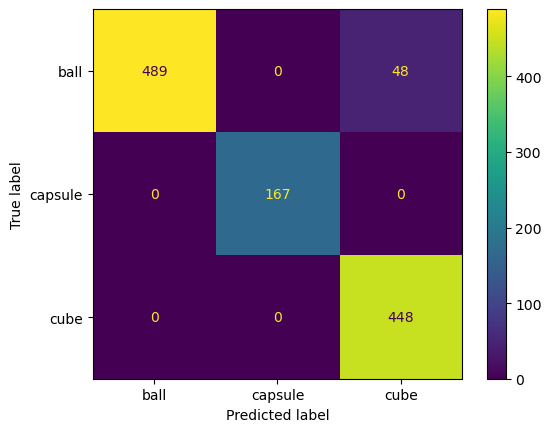

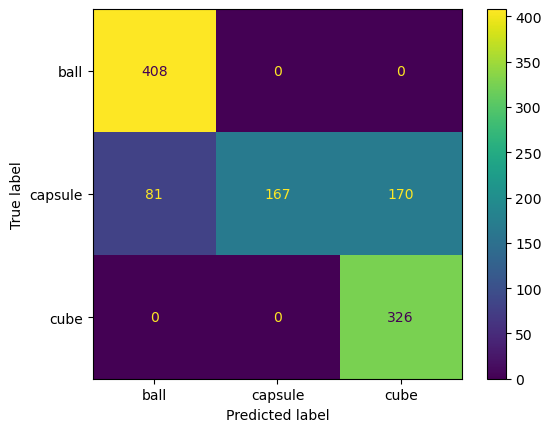

In [40]:
y_pred_reach_new=lr_reach_small_objects_new.predict(X_test_small_objects_new)
y_pred_greab_new=lr_grab_small_objects_new.predict(X_test_small_objects_new)


confusion_matrix_reach_small_objects = confusion_matrix(y_pred_reach_new, y_test_small_objects_new, labels=["cube", "capsule", "ball"])
confusion_matrix_grab_small_objects = confusion_matrix(y_pred_greab_new, y_test_small_objects_new, labels=["cube", "capsule", "ball"])

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_reach_small_objects,display_labels=lr_reach_small_objects_new.classes_)
disp2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_grab_small_objects,display_labels=lr_grab_small_objects_new.classes_)

disp.plot()
disp2.plot()
plt.show()

The confusion matrices after assimilating the number of datapoints considered for reaching and grabbing shows that the grabbing phase especially has issues wth the capsule instance, but not so much with ball and cube.

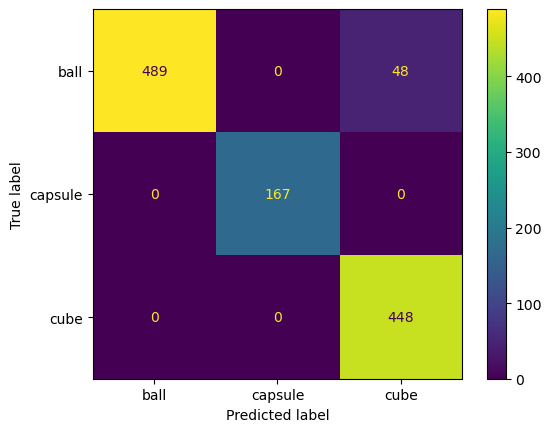

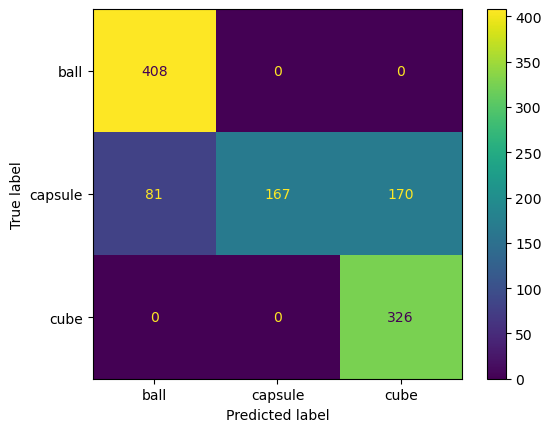

In [41]:
y_pred_reach_new=lr_reach_small_objects_new.predict(X_test_small_objects_new)
y_pred_greab_new=lr_grab_small_objects_new.predict(X_test_small_objects_new)


confusion_matrix_reach_small_objects = confusion_matrix(y_pred_reach_new, y_test_small_objects_new, labels=["cube", "capsule", "ball"])
confusion_matrix_grab_small_objects = confusion_matrix(y_pred_greab_new, y_test_small_objects_new, labels=["cube", "capsule", "ball"])

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_reach_small_objects,display_labels=lr_reach_small_objects_new.classes_)
disp2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_grab_small_objects,display_labels=lr_grab_small_objects_new.classes_)

disp.plot()
disp2.plot()
plt.show()

In [42]:
#Now I will look at deducing object size from the large objects
reaching_cube_train_large_red, grabbing_cube_train_large_red=get_indexed_hidden_states(hidden_states_cube_large_red[:3], reaching_grabbing_differences_cube_large_red[:3])
reaching_cube_test_large_red, grabbing_cube_test_large_red=get_indexed_hidden_states(hidden_states_cube_large_red[-1], [reaching_grabbing_differences_cube_large_red[-1]])
reaching_cube_train_large_green, grabbing_cube_train_large_green=get_indexed_hidden_states(hidden_states_cube_large_green[:3], reaching_grabbing_differences_cube_large_green[:3])
reaching_cube_test_large_green, grabbing_cube_test_large_green=get_indexed_hidden_states(hidden_states_cube_large_green[-1], [reaching_grabbing_differences_cube_large_green[-1]])
reaching_cube_train_large_blue, grabbing_cube_train_large_blue=get_indexed_hidden_states(hidden_states_cube_large_blue[:3], reaching_grabbing_differences_cube_large_blue[:3])
reaching_cube_test_large_blue, grabbing_cube_test_large_blue=get_indexed_hidden_states(hidden_states_cube_large_blue[-1], [reaching_grabbing_differences_cube_large_blue[-1]])

reaching_cube_train_large=reaching_cube_train_large_red+reaching_cube_train_large_green+reaching_cube_train_large_blue
reaching_cube_test_large=reaching_cube_test_large_red+ reaching_cube_test_large_green+reaching_cube_test_large_blue
grabbing_cube_train_large=grabbing_cube_train_large_red+grabbing_cube_train_large_green+grabbing_cube_train_large_blue
grabbing_cube_test_large=grabbing_cube_test_large_red+grabbing_cube_test_large_green+grabbing_cube_test_large_blue



reaching_capsule_train_large_red, grabbing_capsule_train_large_red=get_indexed_hidden_states(hidden_states_capsule_large_red[:3], reaching_grabbing_differences_capsule_large_red[:3])
reaching_capsule_test_large_red, grabbing_capsule_test_large_red=get_indexed_hidden_states(hidden_states_capsule_large_red[-1], [reaching_grabbing_differences_capsule_large_red[-1]])
reaching_capsule_train_large_green, grabbing_capsule_train_large_green=get_indexed_hidden_states(hidden_states_capsule_large_green[:3], reaching_grabbing_differences_capsule_large_green[:3])
reaching_capsule_test_large_green, grabbing_capsule_test_large_green=get_indexed_hidden_states(hidden_states_capsule_large_green[-1], [reaching_grabbing_differences_capsule_large_green[-1]])
reaching_capsule_train_large_blue, grabbing_capsule_train_large_blue=get_indexed_hidden_states(hidden_states_capsule_large_blue[:3], reaching_grabbing_differences_capsule_large_blue[:3])
reaching_capsule_test_large_blue, grabbing_capsule_test_large_blue=get_indexed_hidden_states(hidden_states_capsule_large_blue[-1], [reaching_grabbing_differences_capsule_large_blue[-1]])

reaching_capsule_train_large=reaching_capsule_train_large_red+reaching_capsule_train_large_green+reaching_capsule_train_large_blue
reaching_capsule_test_large=reaching_capsule_test_large_red+reaching_capsule_test_large_green+reaching_capsule_test_large_blue
grabbing_capsule_train_large=grabbing_capsule_train_large_red+grabbing_capsule_train_large_green+grabbing_capsule_train_large_blue
grabbing_capsule_test_large=grabbing_capsule_test_large_red+grabbing_capsule_test_large_green+grabbing_capsule_test_large_blue



reaching_ball_train_large_red, grabbing_ball_train_large_red=get_indexed_hidden_states(hidden_states_ball_large_red[:3], reaching_grabbing_differences_ball_large_red[:3])
reaching_ball_test_large_red, grabbing_ball_test_large_red=get_indexed_hidden_states(hidden_states_ball_large_red[-1], [reaching_grabbing_differences_ball_large_red[-1]])
reaching_ball_train_large_green, grabbing_ball_train_large_green=get_indexed_hidden_states(hidden_states_ball_large_green[:3], reaching_grabbing_differences_ball_large_green[:3])
reaching_ball_test_large_green, grabbing_ball_test_large_green=get_indexed_hidden_states(hidden_states_ball_large_green[-1], [reaching_grabbing_differences_ball_large_green[-1]])
reaching_ball_train_large_red, grabbing_ball_train_large_blue=get_indexed_hidden_states(hidden_states_ball_large_blue[:3], reaching_grabbing_differences_ball_large_blue[:3])
reaching_ball_test_large_red, grabbing_ball_test_large_blue=get_indexed_hidden_states(hidden_states_ball_large_blue[-1], [reaching_grabbing_differences_ball_large_blue[-1]])

reaching_ball_train_large=reaching_ball_train_large_red+reaching_ball_train_large_green+reaching_ball_train_large_red
reaching_ball_test_large=reaching_ball_test_large_red+reaching_ball_test_large_green+reaching_ball_test_large_red
grabbing_ball_train_large=grabbing_ball_train_large_red+grabbing_ball_train_large_green+grabbing_ball_train_large_blue
grabbing_ball_test_large=grabbing_ball_test_large_red+grabbing_ball_test_large_green+grabbing_ball_test_large_blue


lr_reach_large_objects, lr_grab_large_objects, X_test_large_objects, y_test_large_objects=train_lr_reach_vs_grab(reaching_cube_train_large,reaching_capsule_train_large,reaching_ball_train_large, 
                                                                                                               reaching_cube_test_large, reaching_capsule_test_large, reaching_ball_test_large,
                                                                                                               grabbing_cube_train_large,grabbing_capsule_train_large,grabbing_ball_train_large,
                                                                                                               grabbing_cube_test_large, grabbing_capsule_test_large, grabbing_ball_test_large, 
                                                                                                               "cube", "capsule", "ball")
new_reaching_cube_train_large, new_reaching_capsule_train_large, new_reaching_ball_train_large, =assimilate_reach_grab([reaching_cube_train_large, reaching_capsule_train_large, reaching_ball_train_large], [grabbing_cube_train_large, grabbing_capsule_train_large, grabbing_ball_train_large])

lr_reach_large_objects_new, lr_grab_large_objects_new, X_test_large_objects_new, y_test_large_objects_new=train_lr_reach_vs_grab(new_reaching_cube_train_large,new_reaching_capsule_train_large,new_reaching_ball_train_large, 
                                                                                                               reaching_cube_test_large, reaching_capsule_test_large, reaching_ball_test_large,
                                                                                                               grabbing_cube_train_large,grabbing_capsule_train_large,grabbing_ball_train_large,
                                                                                                               grabbing_cube_test_large, grabbing_capsule_test_large, grabbing_ball_test_large, 
                                                                                                               "cube", "capsule", "ball")

Test Accuracy:
  Trained on Reaching: 0.94
  Trained on Grabbing: 0.88
Getting new reachings
Getting new reachings
Getting new reachings
Test Accuracy:
  Trained on Reaching: 0.90
  Trained on Grabbing: 0.89


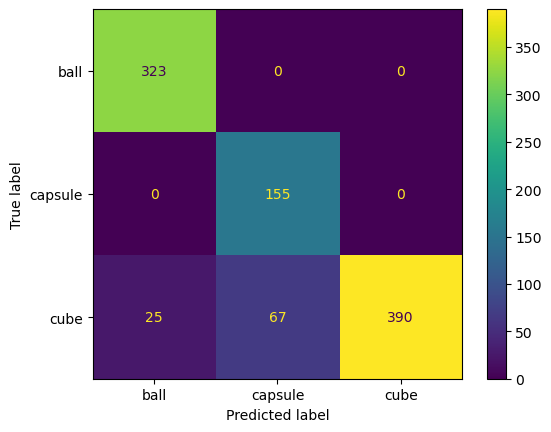

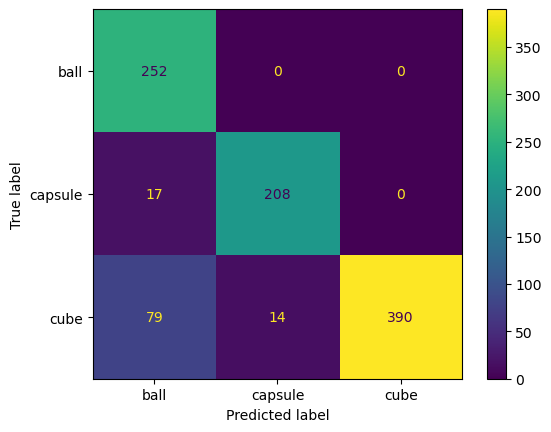

In [43]:
y_pred_reach_large_objects_new=lr_reach_large_objects_new.predict(X_test_large_objects_new)
y_pred_grab_large_objects_new=lr_grab_large_objects_new.predict(X_test_large_objects_new)


confusion_matrix_reach_large_objects = confusion_matrix(y_pred_reach_large_objects_new, y_test_large_objects_new, labels=["cube", "capsule", "ball"])
confusion_matrix_grab_large_objects = confusion_matrix(y_pred_grab_large_objects_new, y_test_large_objects_new, labels=["cube", "capsule", "ball"])

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_reach_large_objects,display_labels=lr_reach_large_objects_new.classes_)
disp2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_grab_large_objects,display_labels=lr_grab_large_objects_new.classes_)

disp.plot()
disp2.plot()
plt.show()

The above is an interesting result which shows that object shape is not easy to deduce!
I will next look at the color and size

# Color
For color I will do the same analysis as above but only with one object and three colorways. I start with the cube small, but of course I need to check for the other objects also

In [44]:
reaching_red_train, grabbing_red_train=get_indexed_hidden_states(hidden_states_cube_small_red[:3], reaching_grabbing_differences_cube_small_red[:3])
reaching_red_test, grabbing_red_test=get_indexed_hidden_states(hidden_states_cube_small_red[-1], [reaching_grabbing_differences_cube_small_red[-1]])


reaching_green_train, grabbing_green_train=get_indexed_hidden_states(hidden_states_cube_small_green[:3], reaching_grabbing_differences_cube_small_green[:3])
reaching_green_test, grabbing_green_test=get_indexed_hidden_states(hidden_states_cube_small_green[-1], [reaching_grabbing_differences_cube_small_green[-1]])


reaching_blue_train, grabbing_blue_train=get_indexed_hidden_states(hidden_states_cube_small_blue[:3], reaching_grabbing_differences_cube_small_blue[:3])
reaching_blue_test, grabbing_blue_test=get_indexed_hidden_states(hidden_states_cube_small_blue[-1], [reaching_grabbing_differences_cube_small_blue[-1]])

print("Length of red training data in reaching: ", len(reaching_red_train) ," and grabbing: ", len(grabbing_red_train))
print("Length of green training data in reaching: ", len(reaching_green_train) ," and grabbing: ", len(grabbing_green_train))
print("Length of blue training data in reaching: ", len(reaching_blue_train) ," and grabbing: ", len(grabbing_blue_train))

print("Total length of reaching: ", len(reaching_red_train) + len(reaching_green_train) + len(reaching_blue_train), 
      "\nTotal length of grabbing: ", len(grabbing_red_train) + len(grabbing_green_train) + len(grabbing_blue_train))


lr_reach_cube_small, lr_grab_cube_small, X_test_cube, y_test_cube=train_lr_reach_vs_grab(reaching_red_train,reaching_green_train,reaching_blue_train, 
                                                                                         reaching_red_test, reaching_green_test, reaching_blue_test,
                                                                                         grabbing_red_train,grabbing_green_train,grabbing_blue_train,
                                                                                         grabbing_red_test, grabbing_green_test, grabbing_blue_test, 
                                                                                         "red", "green", "blue", limit=10000)

Length of red training data in reaching:  288  and grabbing:  240
Length of green training data in reaching:  176  and grabbing:  272
Length of blue training data in reaching:  144  and grabbing:  224
Total length of reaching:  608 
Total length of grabbing:  736
Test Accuracy:
  Trained on Reaching: 0.37
  Trained on Grabbing: 0.22


The above results show that color is not well represented in any hidden states. Furthermore, we see that we have some more data for grabbing than we do for reaching. In the following experiment, I will see if throwing out some samples for grabbing in each instance would influence the performance heavily. Mostly, I am doing this, because color should have an equally small impact on reaching and on grabbing, but we see a difference of about 15%

In [45]:
total_len_reach=len(reaching_red_train) + len(reaching_green_train) + len(reaching_blue_train)
total_len_grab=len(grabbing_red_train) + len(grabbing_green_train) + len(grabbing_blue_train)

difference_per_movement=(total_len_grab-total_len_reach)//3

new_grabbing_red_train=grabbing_red_train[:-difference_per_movement]
new_grabbing_green_train=grabbing_green_train[:-difference_per_movement]
new_grabbing_blue_train=grabbing_blue_train[:-difference_per_movement]

print("Total new length: ", len(new_grabbing_red_train) + len(new_grabbing_green_train) + len(new_grabbing_blue_train))

lr_reach_cube_small_new, lr_grab_cube_small_new, X_test_cube_new, y_test_cube_new=train_lr_reach_vs_grab(reaching_red_train,reaching_green_train,reaching_blue_train, reaching_red_test, reaching_green_test, reaching_blue_test,
                       new_grabbing_red_train,new_grabbing_green_train,new_grabbing_blue_train,grabbing_red_test, grabbing_green_test, grabbing_blue_test, 
                       "red", "green", "blue", limit=10000)

Total new length:  610
Test Accuracy:
  Trained on Reaching: 0.37
  Trained on Grabbing: 0.25


While having a small impact on performance, balancing out the training sets did not impact fully the difference in accuracy. The gap of 10% is still pretty  and significant. 

Next we need to answer two questions:\
(1) Is this consitent across other objects (small or large, shape indifferent)?\
(2) Where exactly do the differences lie (is there a particular color that performs badly, if so, is this maybe tied to success rate)?\

These two questions are not fully disconnect from each other, but since the validity of the result depend on how these results look on different objects, I will investigate these first and then maybe collectively analyse the results to find more answers for the other objects. I start with small ball and small capsule, so we can investigate the connection between color and shape with disregard for size.

In [46]:
reaching_red_train_ball_small, grabbing_red_train_ball_small=get_indexed_hidden_states(hidden_states_ball_small_red[:3], reaching_grabbing_differences_ball_small_red[:3])
reaching_red_test_ball_small, grabbing_red_test_ball_small=get_indexed_hidden_states(hidden_states_ball_small_red[-1], [reaching_grabbing_differences_ball_small_red[-1]])


reaching_green_train_ball_small, grabbing_green_train_ball_small=get_indexed_hidden_states(hidden_states_ball_small_green[:3], reaching_grabbing_differences_ball_small_green[:3])
reaching_green_test_ball_small, grabbing_green_test_ball_small=get_indexed_hidden_states(hidden_states_ball_small_green[-1], [reaching_grabbing_differences_ball_small_green[-1]])


reaching_blue_train_ball_small, grabbing_blue_train_ball_small=get_indexed_hidden_states(hidden_states_ball_small_blue[:3], reaching_grabbing_differences_ball_small_blue[:3])
reaching_blue_test_ball_small, grabbing_blue_test_ball_small=get_indexed_hidden_states(hidden_states_ball_small_blue[-1], [reaching_grabbing_differences_ball_small_blue[-1]])

print("Total length of training reaching: ", len(reaching_red_train_ball_small)+len(reaching_green_train_ball_small)+len(reaching_blue_train_ball_small))
print("Total length of training grabbing: ", len(grabbing_red_train_ball_small)+len(grabbing_green_train_ball_small)+len(grabbing_blue_train_ball_small))

lr_reach_ball_small, lr_grab_ball_small, X_test_ball, y_test_ball=train_lr_reach_vs_grab(reaching_red_train_ball_small,reaching_green_train_ball_small,reaching_blue_train_ball_small, reaching_red_test_ball_small, reaching_green_test_ball_small, reaching_blue_test_ball_small,
                       grabbing_red_train_ball_small,grabbing_green_train_ball_small,grabbing_blue_train_ball_small,grabbing_red_test_ball_small, grabbing_green_test_ball_small, grabbing_blue_test_ball_small, 
                       "red", "green", "blue", limit=10000)

Total length of training reaching:  912
Total length of training grabbing:  768
Test Accuracy:
  Trained on Reaching: 0.34
  Trained on Grabbing: 0.31


In [47]:
total_len_reach_ball_small=len(reaching_red_train_ball_small) + len(reaching_green_train_ball_small) + len(reaching_blue_train_ball_small)
total_len_grab_ball_small=len(grabbing_red_train_ball_small) + len(grabbing_green_train_ball_small) + len(grabbing_blue_train_ball_small)

difference_per_movement_ball_small=(total_len_reach_ball_small-total_len_grab_ball_small)//3

new_reaching_red_train_ball_small=reaching_red_train_ball_small[:-difference_per_movement_ball_small]
new_reaching_green_train_ball_small=reaching_green_train_ball_small[:-difference_per_movement_ball_small]
new_reaching_blue_train_ball_small=reaching_blue_train_ball_small[:-difference_per_movement_ball_small]

print("Total new length: ", len(new_reaching_red_train_ball_small) + len(new_reaching_green_train_ball_small) + len(new_reaching_blue_train_ball_small))

lr_reach_ball_small_new, lr_grab_ball_small_new, X_test_ball_new, y_test_ball_new=train_lr_reach_vs_grab(new_reaching_red_train_ball_small,new_reaching_green_train_ball_small,new_reaching_blue_train_ball_small, reaching_red_test_ball_small, reaching_green_test_ball_small, reaching_blue_test_ball_small,
                       grabbing_red_train_ball_small,grabbing_green_train_ball_small,grabbing_blue_train_ball_small,grabbing_red_test_ball_small, grabbing_green_test_ball_small, grabbing_blue_test_ball_small, 
                       "red", "green", "blue", limit=10000)

Total new length:  768
Test Accuracy:
  Trained on Reaching: 0.32
  Trained on Grabbing: 0.30


The results for ball underline the results that we found in cube. We do not know anything about the correlation to the success rate yet, because im using the old ball small results and they are pretty similar to small cube. Unfortunately, I deleted the model, and the retrained ball model performs worse. Possibly because eithe weight decay or learning rate were 1e-7 and not 1e-4, (bzw 1e-5 weight decay) as before...

In [48]:
reaching_red_train_capsule_small, grabbing_red_train_capsule_small=get_indexed_hidden_states(hidden_states_capsule_small_red[:3], reaching_grabbing_differences_capsule_small_red[:3])
reaching_red_test_capsule_small, grabbing_red_test_capsule_small=get_indexed_hidden_states(hidden_states_capsule_small_red[-1], [reaching_grabbing_differences_capsule_small_red[-1]])


#I am taking the first two instances for training in the case of the 3 example capsule pickup
reaching_green_train_capsule_small, grabbing_green_train_capsule_small=get_indexed_hidden_states(hidden_states_capsule_small_green[:2], reaching_grabbing_differences_capsule_small_green[:2])
reaching_green_test_capsule_small, grabbing_green_test_capsule_small=get_indexed_hidden_states(hidden_states_capsule_small_green[-1], [reaching_grabbing_differences_capsule_small_green[-1]])


reaching_blue_train_capsule_small, grabbing_blue_train_capsule_small=get_indexed_hidden_states(hidden_states_capsule_small_blue[:3], reaching_grabbing_differences_capsule_small_blue[:3])
reaching_blue_test_capsule_small, grabbing_blue_test_capsule_small=get_indexed_hidden_states(hidden_states_capsule_small_blue[-1], [reaching_grabbing_differences_capsule_small_blue[-1]])

print("Total length of training reaching: ", len(reaching_red_train_capsule_small)+len(reaching_green_train_capsule_small)+len(reaching_blue_train_capsule_small))
print("Total length of training grabbing: ", len(grabbing_red_train_capsule_small)+len(grabbing_green_train_capsule_small)+len(grabbing_blue_train_capsule_small))

lr_reach_capsule_small, lr_grab_capsule_small, X_test_capsule, y_test_capsule=train_lr_reach_vs_grab(reaching_red_train_capsule_small,reaching_green_train_capsule_small,reaching_blue_train_capsule_small, reaching_red_test_capsule_small, reaching_green_test_capsule_small, reaching_blue_test_capsule_small,
                       grabbing_red_train_capsule_small,grabbing_green_train_capsule_small,grabbing_blue_train_capsule_small,grabbing_red_test_capsule_small, grabbing_green_test_capsule_small, grabbing_blue_test_capsule_small, 
                       "red", "green", "blue", limit=10000)

Total length of training reaching:  416
Total length of training grabbing:  352
Test Accuracy:
  Trained on Reaching: 0.21
  Trained on Grabbing: 0.28


In [49]:
total_len_reach_capsule_small=len(reaching_red_train_capsule_small) + len(reaching_green_train_capsule_small) + len(reaching_blue_train_capsule_small)
total_len_grab_capsule_small=len(grabbing_red_train_capsule_small) + len(grabbing_green_train_capsule_small) + len(grabbing_blue_train_capsule_small)

difference_per_movement_capsule_small=(total_len_reach_capsule_small-total_len_grab_capsule_small)//3

new_reaching_red_train_capsule_small=reaching_red_train_capsule_small[:-difference_per_movement_capsule_small]
new_reaching_green_train_capsule_small=reaching_green_train_capsule_small[:-difference_per_movement_capsule_small]
new_reaching_blue_train_capsule_small=reaching_blue_train_capsule_small[:-difference_per_movement_capsule_small]

print("Total new length: ", len(new_reaching_red_train_capsule_small) + len(new_reaching_green_train_capsule_small) + len(new_reaching_blue_train_capsule_small))

lr_reach_capsule_small_new, lr_grab_capsule_small_new, X_test_capsule_new, y_test_capsule_new=train_lr_reach_vs_grab(new_reaching_red_train_capsule_small,new_reaching_green_train_capsule_small,new_reaching_blue_train_capsule_small, reaching_red_test_capsule_small, reaching_green_test_capsule_small, reaching_blue_test_capsule_small,
                       grabbing_red_train_capsule_small,grabbing_green_train_capsule_small,grabbing_blue_train_capsule_small,grabbing_red_test_capsule_small, grabbing_green_test_capsule_small, grabbing_blue_test_capsule_small, 
                       "red", "green", "blue", limit=10000)

Total new length:  353
Test Accuracy:
  Trained on Reaching: 0.21
  Trained on Grabbing: 0.27


Another interesting fact to note here is the difference of the weight of reaching and grabbing. Ball examples have a longer reaching phase on average than reahcing and grabbing for the capsule. This might affect performance. In the following I will analyse the outputs a bit more in detail.

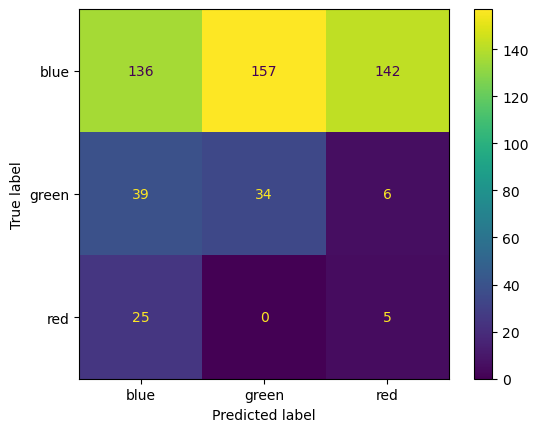

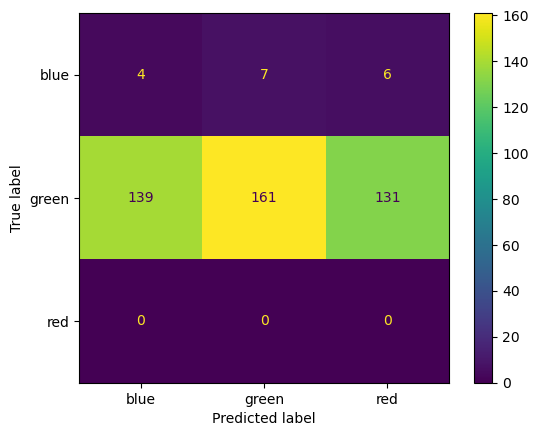

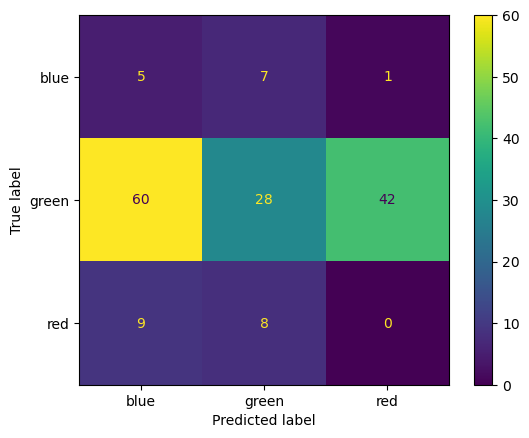

In [50]:
#Firstly, I will analyse the confusion matrixes first

y_pred_cube_new=lr_reach_cube_small_new.predict(X_test_cube_new)
y_pred_ball_new=lr_reach_ball_small_new.predict(X_test_ball_new)
y_pred_capsule_new=lr_reach_capsule_small_new.predict(X_test_capsule_new)    


confusion_matrix_ball = confusion_matrix(y_pred_cube_new, y_test_cube_new, labels=["red", "green", "blue"])
confusion_matrix_cube = confusion_matrix(y_pred_ball_new, y_test_ball_new, labels=["red", "green", "blue"])
confusion_matrix_capsule = confusion_matrix(y_pred_capsule_new, y_test_capsule_new, labels=["red", "green", "blue"])

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_cube,display_labels=lr_reach_cube_small_new.classes_)
disp2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_ball,display_labels=lr_reach_cube_small_new.classes_)
disp3 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_capsule,display_labels=lr_reach_cube_small_new.classes_)

disp.plot()
disp2.plot()
disp3.plot()
plt.show()

The confusion matrixes show and underline that there is no consistent good prediction

In [51]:
# For full comparison, I need to repeat the color experiment with the large objects aswell



# Size

For the size analysis I will proceed similarly to color and shape, and I will investigate how the size affects the grabbing process on attention level (which tokens are changing if we change the size). For this I will also consider all colors per object size/shape combo.



In [52]:
#For the size analysis I recycle the object gatherings from above
reaching_all_objects_small_train=reaching_cube_train_small+reaching_capsule_train_small+reaching_ball_train_small
reaching_all_objects_small_test=reaching_cube_test_small+reaching_capsule_test_small+reaching_ball_test_small
reaching_all_objects_large_train=reaching_cube_train_large+reaching_capsule_train_large+reaching_ball_train_large
reaching_all_objects_large_test=reaching_cube_test_large+reaching_capsule_test_large+reaching_ball_test_large

grabbing_all_objects_small_train=grabbing_cube_train_small+grabbing_capsule_train_small+grabbing_ball_train_small
grabbing_all_objects_small_test=grabbing_cube_test_small+grabbing_capsule_test_small+grabbing_ball_test_small
grabbing_all_objects_large_train=grabbing_cube_train_large+grabbing_capsule_train_large+grabbing_ball_train_large
grabbing_all_objects_large_test=grabbing_cube_test_large+grabbing_capsule_test_large+grabbing_ball_test_large


lr_reach_all_large_objects, lr_grab_all_large_objects, X_test_all_large_objects, y_test_all_large_objects=train_lr_reach_vs_grab(reaching_all_objects_small_train,reaching_all_objects_large_train, None,
                                                                                                                   reaching_all_objects_small_test, reaching_all_objects_large_test, None,
                                                                                                                   grabbing_all_objects_small_train,grabbing_all_objects_large_train, None,
                                                                                                                   grabbing_all_objects_small_test,grabbing_all_objects_large_test, None,
                                                                                                                   "small", "large")
new_reaching_train_all_small, new_reaching_train_all_large =assimilate_reach_grab([reaching_all_objects_small_train, reaching_all_objects_large_train], [grabbing_all_objects_small_train, grabbing_all_objects_large_train])

lr_reach_all_large_objects_new, lr_grab_all_large_objects_new, X_test_all_large_objects_new, y_test_all_large_objects_new=train_lr_reach_vs_grab(new_reaching_train_all_small,new_reaching_train_all_large, None,
                                                                                                                   reaching_all_objects_small_test, reaching_all_objects_large_test, None,
                                                                                                                   grabbing_all_objects_small_train,grabbing_all_objects_large_train, None,
                                                                                                                   grabbing_all_objects_small_test,grabbing_all_objects_large_test, None,
                                                                                                                   "small", "large")
y_pred_size_reach=lr_reach_all_large_objects_new.predict(X_test_all_large_objects_new)
y_pred_size_grab=lr_grab_all_large_objects_new.predict(X_test_all_large_objects_new)

confusion_matrix_size_reach = confusion_matrix(y_pred_size_reach, y_test_all_large_objects_new, labels=["small", "large"])
confusion_matrix_size_grab = confusion_matrix(y_pred_size_grab, y_test_all_large_objects_new, labels=["small", "large"])

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_size_reach,display_labels=lr_reach_all_large_objects_new.classes_)
disp2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_size_grab,display_labels=lr_reach_all_large_objects_new.classes_)

disp.plot()
disp2.plot()
plt.show()

Test Accuracy:
  Trained on Reaching: 0.95
  Trained on Grabbing: 0.79
Getting new reachings
Getting new reachings


IndexError: list index out of range

## --------------------------------------Think Break!--------------------------------------
We have to keep in mind the brain in this analysis, since we want to compare it to the brain. We argue in the proposal that in the brain there are two streams, the objct recognition part in the tokens from the VLM and the ventral stream that comes in when doing cross attention. 

I need to break this down and think about how I can actually show this. 

We want to show that certain tokens encode "where" (ventral) the object is, which is related to the reaching part and certain tokens encode "What" (dorsal) the object is, which is sensitive to the shape or size or color. Now the question is, how can we actually tickle out this information from the attention patterns?

(1) We can firstly identify which tokens more strongly correlate to reaching and which correlate to grabbing.\
(2)
